# Towards a GIS system

In [ ]:
#| default_exp chunked

In [ ]:
#| export
import numpy as np
import sys
import os
import math
from math import radians, cos, sin, sqrt, atan2
import random

#data
from collections import namedtuple
from dataclasses import dataclass,  field, asdict
import json
from typing import List , Optional
from enum import Enum



In [ ]:
#| export
from dataclasses import dataclass
from typing import Optional

from datetime import datetime


In [ ]:
#| export
from fastcore.utils import *
from fasthtml.common import *
from fasthtml.jupyter import *
from fastlite import *
import fasthtml.components as fc
import httpx


In [ ]:
#| export
from importlib import resources
from pathlib import Path
import tempfile
import shutil
import sqlite3
from dataclasses import dataclass
from typing import Iterator
import numpy as np

In [ ]:
from HexMagic.geology import Plate

In [ ]:
#| export
from HexMagic.climate import TerrainPatterns, DrainageBasins, Geology, TerraDemo, Terrain, GeoBounds, ClimatePreset, TerrainFactory
from HexMagic.primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from HexMagic.styles import StyleCSS, SVGBuilder, SVGDef

In [ ]:
#| export
from HexMagic.geology import River, Watershed
from HexMagic.water.river import find_local_minima
# Set up a proper ChunkedTerrainGenerator test
from HexMagic.database import GeoStorageDebugger, ChunkRef
from HexMagic.primitives import HexPosition,  HexChunk, render_chunk



In [ ]:
#| export
from HexMagic.database import LoadResult, SaveResult, HexWeather, WatershedMeta, TerrainWorld, User, GeoStorage, HexData

In [ ]:
#| export
from HexMagic.database import world_to_chunk

In [ ]:
#| export
from HexMagic.voronoi import TerrainGenerator

## Testing to see if we are good

In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    #dbg.test_multiple_worlds()
    #dbg.test_multiscale_watersheds()
    #dbg.test_smallWs()
    dbg.test_save_load_terrain()
    dbg.test_query_radius()
    dbg.test_extract_region()
    dbg.test_region_mappers()
    dbg.test_save_load_weather()
    #dbg.test_chunked_terrain_generator()
    dbg.test_save_load_watersheds()
    dbg.test_chunk_spiral_mapping()
    dbg.test_chunk_halo_overlap()

✓ Saved world 1: 4900 hexes


✓ Loaded world: 4900 hexes
✓ Elevations match (4900 hexes)


✓ Found 54 hexes within radius 5 of origin


✓ Extracted region: 181/181 hexes mapped
  Grid size: 529 hexes
  Center index: 264


✓ Coord mapper: center maps to (5, -3, -2)
✓ Index mapper: 143/169 indices map to original


...

✓ Saved weather: 5170 weather records for season=annual


✓ Loaded world without weather fields
✓ Loaded weather: 5170 weather records for season=annual
✓ Weather data matches original


✓ Saved summer weather
✓ Summer temperatures correctly loaded (warmer than annual)


✓ Saved world 6
✓ Saved watersheds: 1 watersheds, 54 hexes assigned


✓ Loaded watersheds: 1 watersheds
✓ Watershed count matches: 1
✓ Query watershed hexes: 54 hexes in watershed 0
✓ Spiral sizes: core=37, total=91
✓ Index 0 is origin
✓ All 91 indices round-trip through position
✓ Core/halo boundary at ring 3
✓ Position-based data preserved through save/load
✓ 8 halo hexes copied from adjacent chunk
✓ Test database cleaned up


In [ ]:
GeoStorageDebugger.test_chunk_spiral_mapping??


```python
@patch
def test_chunk_spiral_mapping(self: GeoStorageDebugger):
    """Test HexChunk spiral indexing and core/halo boundaries."""
    core_rings = 3
    halo_rings = 2
    position = HexPosition(0, 0, 0)

    chunk = HexChunk.with_halo(position, core_rings, halo_rings)

    # Test 1: Verify spiral size formula
    expected_core_size = HexChunk.spiral_size(core_rings)
    expected_total = HexChunk.spiral_size(core_rings + halo_rings)
    assert chunk.core_size == expected_core_size, f"Core size: {chunk.core_size} vs {expected_core_size}"
    assert len(chunk) == expected_total, f"Total size: {len(chunk)} vs {expected_total}"
    print(f"✓ Spiral sizes: core={chunk.core_size}, total={len(chunk)}")

    # Test 2: Index 0 is always origin
    center_pos = chunk.index_to_hexposition(0)
    assert center_pos == HexPosition(0, 0, 0), f"Index 0 should be origin, got {center_pos}"
    print(f"✓ Index 0 is origin")

    # Test 3: Bidirectional mapping is consistent
    for idx in range(len(chunk)):
        pos = chunk.index_to_hexposition(idx)
        back_idx = chunk.hexposition_to_index(pos)
        assert back_idx == idx, f"Round-trip failed: {idx} -> {pos} -> {back_idx}"
    print(f"✓ All {len(chunk)} indices round-trip through position")

    # Test 4: Core/halo boundary
    last_core_idx = chunk.core_size - 1
    first_halo_idx = chunk.core_size

    assert chunk.is_core(last_core_idx), f"Index {last_core_idx} should be core"
    assert chunk.is_halo(first_halo_idx), f"Index {first_halo_idx} should be halo"

    last_core_pos = chunk.index_to_hexposition(last_core_idx)
    first_halo_pos = chunk.index_to_hexposition(first_halo_idx)

    # Core boundary should be at distance == core_rings from center
    assert last_core_pos.distance(HexPosition(0,0,0)) == core_rings, \
        f"Last core hex should be at distance {core_rings}"
    assert first_halo_pos.distance(HexPosition(0,0,0)) == core_rings + 1, \
        f"First halo hex should be at distance {core_rings + 1}"
    print(f"✓ Core/halo boundary at ring {core_rings}")

    # Test 5: Save/load preserves position-based data
    # Set unique values at specific positions
    test_positions = [
        HexPosition(0, 0, 0),      # center
        HexPosition(1, -1, 0),     # ring 1
        HexPosition(core_rings, -core_rings, 0),  # core edge
    ]

    for i, pos in enumerate(test_positions):
        idx = chunk.hexposition_to_index(pos)
        chunk.elevations[idx] = (i + 1) * 100.0

    # Save
    result = self.server.save_chunk(chunk)
    assert result.status == 'saved', f"Save failed: {result.context}"

    # Load into fresh chunk
    chunk_ref = ChunkRef(position, core_rings + halo_rings)
    loaded_result = self.server.load_chunk(chunk_ref)
    assert loaded_result.status == 'loaded'
    loaded = loaded_result.data

    # Verify by position, not index
    for i, pos in enumerate(test_positions):
        loaded_idx = loaded.hexposition_to_index(pos)
        expected = (i + 1) * 100.0
        actual = loaded.elevations[loaded_idx]
        assert np.isclose(actual, expected), \
            f"Position {pos}: expected {expected}, got {actual}"
    print(f"✓ Position-based data preserved through save/load")
```

**File:** `~/HexMagic/HexMagic/database.py`

In [ ]:
GeoStorageDebugger.test_chunk_halo_overlap??


```python
@patch
def test_chunk_halo_overlap(self: GeoStorageDebugger):
    """Test that adjacent chunks' halos overlap correctly."""
    core_rings = 3
    halo_rings = 2

    # Two adjacent chunks
    chunk_a = HexChunk.with_halo(HexPosition(0, 0, 0), core_rings, halo_rings)
    chunk_b = HexChunk.with_halo(HexPosition(1, -1, 0), core_rings, halo_rings)

    # Set elevations in chunk_a
    for idx in chunk_a.iter_core():
        chunk_a.elevations[idx] = idx * 10.0

    # Copy overlapping data to chunk_b's halo
    chunk_b.copy_from(chunk_a)

    # Find hexes that should overlap (chunk_b's halo ∩ chunk_a's core)
    overlap_count = 0
    for idx in chunk_b.iter_halo():
        world_pos = chunk_b.index_to_world(idx)
        a_idx = chunk_a.world_to_index(world_pos)
        if a_idx >= 0 and chunk_a.is_core(a_idx):
            assert chunk_b.elevations[idx] == chunk_a.elevations[a_idx]
            overlap_count += 1

    print(f"✓ {overlap_count} halo hexes copied from adjacent chunk")
```

**File:** `~/HexMagic/HexMagic/database.py`

In [ ]:
GeoStorage.load_chunk??


```python
@patch  
def load_chunk(self: GeoStorage, chunk_ref: ChunkRef) -> LoadResult:
    """Load HexChunk from database."""


    p = chunk_ref.position
    name = f"chunk_{p.q}_{p.r}_{p.s}"

    # Find the most recent chunk by name - use id DESC since created has second precision
    cursor = self.db.execute(
        "SELECT * FROM terrain_world WHERE name = ? ORDER BY id DESC LIMIT 1",
        [name]
    )

    row = cursor.fetchone()
    if not row:
        return LoadResult(None, 'not_found', f'Chunk {name} not found')

    cols = [d[0] for d in cursor.description]
    world = dict(zip(cols, row))

    world_id = world['id']
    rings = world['nrows']
    core_size = world['ncols']

    # Create HexChunk
    chunk = HexChunk(chunk_ref.position, rings)
    chunk.core_size = core_size

    # Load hex data
    hex_rows = self.query_hexes_latest(world_id)

    for row in hex_rows:
        pos = HexPosition(row['q'], row['r'], row['s'])
        idx = chunk.hexposition_to_index(pos)
        if idx >= 0:
            chunk.elevations[idx] = row['elevation']
            if row.get('plate_id', -1) >= 0:
                if 'plate_id' not in chunk.fields:
                    chunk.add_field('plate_id', default=-1)
                chunk.fields['plate_id'][idx] = row['plate_id']

    return LoadResult(chunk, 'loaded', f'{len(hex_rows)} hexes')
```

**File:** `~/HexMagic/HexMagic/database.py`

In [ ]:
GeoStorage.save_chunk??


```python
@patch
def save_chunk(self: GeoStorage, chunk: HexChunk, coarse_world_id: int = None) -> SaveResult:
    """Save HexChunk to database.

    Args:
        chunk: The HexChunk to save
        coarse_world_id: Optional parent world reference (for linking chunks to coarse map)
    """
    now = int(datetime.now().timestamp())
    p = chunk.position
    name = f"chunk_{p.q}_{p.r}_{p.s}"

    # Store in TerrainWorld (reusing schema)
    extras = {'coarse_world_id': coarse_world_id, 'is_chunk': True}

    with self.db.conn:
        world_result = self.worlds.insert({
            'name': name,
            'hex_radius': 0,  # Not used for chunks
            'nrows': chunk.rings,  # Store rings here
            'ncols': chunk.core_size,  # Store core_size here
            'extras': json.dumps(extras),
            'created': now,
            'modified': now
        })

        world_id = world_result['id'] if isinstance(world_result, dict) else world_result

        # Save hex data (core only, or all?)
        for idx in chunk.iter_core():  # Save core only
            local_pos = chunk.index_to_hexposition(idx)

            record = {
                'world_id': world_id,
                'q': local_pos.q,
                'r': local_pos.r, 
                's': local_pos.s,
                'grid_index': idx,
                'elevation': float(chunk.elevations[idx]),
                'plate_id': int(chunk.fields.get('plate_id', [-1])[idx]) if 'plate_id' in chunk.fields else -1,
                'modified': now
            }
            self.hexes.insert(record)

        return SaveResult(world_id, 'saved', f'{chunk.core_size} hexes')
```

**File:** `~/HexMagic/HexMagic/database.py`

## The refactored mathod

In [ ]:
class ChunkedTerrainGenerator:
    """Generate and manage large terrains via chunking with plate tracking."""
    
    def __init__(self, storage: 'GeoStorage', 
                 coarse_rings: int = 20,
                 coarse_radius: float = 50,
                 fine_radius: float = 10,
                 chunk_rings: int = 10,
                 halo_rings: int = 3):
        """
        Args:
            storage: GeoStorage for persistence
            coarse_rings: Rings in coarse overview map
            coarse_radius: Hex radius for coarse hexes
            fine_radius: Hex radius for detailed chunks
            chunk_rings: Rings of hexes per chunk (core)
            halo_rings: Extra rings for edge computation
        """
        self.storage = storage
        self.coarse_rings = coarse_rings
        self.coarse_radius = coarse_radius
        self.fine_radius = fine_radius
        self.chunk_rings = chunk_rings
        self.halo_rings = halo_rings
        
        self.coarse_world_id = None
        self._plates = None
        self._coarse_terrain = None
    
    @property
    def scale(self) -> float:
        """Resolution scale factor between coarse and fine."""
        return self.coarse_radius / self.fine_radius


# === COARSE MAP GENERATION ===

@patch
def generate_coarse(self: ChunkedTerrainGenerator, 
                    num_plates: int = 15,
                    ocean_fraction: float = 0.4,
                    oceanic_sides: list = None,
                    name: str = "world_coarse",
                    **kwargs) -> Terrain:
    """Generate coarse map using TerrainGenerator."""
    gen = TerrainGenerator(
        hexDim=self.coarse_rings,
        radius=self.coarse_radius,
        num_plates=num_plates,
        ocean_fraction=ocean_fraction,
        oceanic_sides=oceanic_sides or [],
        subdivisions=2,
        **kwargs
    )
    
    terrain, plates = gen.generate()
    self._plates = plates
    self._coarse_terrain = terrain
    
    result = self.storage.save_world(terrain, name=name)
    self.coarse_world_id = result.id
    
    return terrain


# === CHUNK GENERATION ===

@patch
def generate_chunk(self: ChunkedTerrainGenerator, chunk_ref: ChunkRef) -> HexChunk:
    """Generate chunk by sampling from coarse with plate inheritance."""
    chunk_plates = self._query_chunk_plates(chunk_ref)
    
    chunk = HexChunk.with_halo(
        position=chunk_ref.position,
        core_rings=self.chunk_rings,
        halo_rings=self.halo_rings
    )
    chunk.add_field('plate_id', default=-1)
    
    coarse_lookup = self._build_coarse_lookup(chunk_plates)
    self._populate_from_coarse(chunk, coarse_lookup)
    self._interpolate_fields_to_chunk(chunk, coarse_lookup)
    self._add_detail_to_chunk(chunk)
    
    return chunk


@patch
def _query_chunk_plates(self: ChunkedTerrainGenerator, chunk: ChunkRef) -> dict:
    """Query DB for plate membership in chunk region."""
    center = chunk.center_hex
    radius = int((self.chunk_rings + self.halo_rings) / self.scale) + 2
    
    coarse_q = int(center.q / self.scale)
    coarse_r = int(center.r / self.scale)
    coarse_s = -coarse_q - coarse_r
    
    rows = self.storage.query_hexes_in_radius(
        self.coarse_world_id,
        coarse_q, coarse_r, coarse_s,
        radius
    )
    
    plates = {}
    for row in rows:
        pid = row.get('plate_id', 0)
        if pid not in plates:
            plates[pid] = []
        plates[pid].append(row)
    
    return plates


@patch
def _build_coarse_lookup(self: ChunkedTerrainGenerator, chunk_plates: dict) -> dict:
    """Convert chunk_plates query result to lookup dict."""
    coarse_lookup = {}
    for pid, rows in chunk_plates.items():
        for row in rows:
            key = (row['q'], row['r'], row['s'])
            coarse_lookup[key] = {
                'elevation': row['elevation'],
                'plate_id': pid,
            }
    return coarse_lookup


@patch
def _populate_from_coarse(self: ChunkedTerrainGenerator, 
                          chunk: HexChunk, 
                          coarse_lookup: dict):
    """Fill chunk elevations and plate_id by interpolating from coarse data."""
    for idx, local_pos, world_pos in chunk.iter_with_world():
        elevation, plate_id = self._interpolate_elevation(world_pos, coarse_lookup)
        chunk.elevations[idx] = elevation
        chunk.fields['plate_id'][idx] = int(plate_id)


@patch
def _interpolate_elevation(self: ChunkedTerrainGenerator, 
                           world_pos: HexPosition, 
                           coarse_lookup: dict) -> tuple[float, int]:
    """Interpolate elevation using distance-weighted average of nearby coarse hexes."""
    scale = self.scale
    
    # Fractional coarse coordinates
    frac_q = world_pos.q / scale
    frac_r = world_pos.r / scale
    frac_s = -frac_q - frac_r
    
    # Nearest coarse hex center
    near_q = int(round(frac_q))
    near_r = int(round(frac_r))
    near_s = -near_q - near_r
    center = HexPosition(near_q, near_r, near_s)
    
    # Sample center + ring-1 neighbors (7 hexes)
    candidates = [center] + list(center.ring(1))
    
    weights = []
    elevations = []
    plate_weights = {}
    
    for cpos in candidates:
        key = (cpos.q, cpos.r, cpos.s)
        if key not in coarse_lookup:
            continue
        
        dq = cpos.q - frac_q
        dr = cpos.r - frac_r
        ds = cpos.s - frac_s
        dist = (abs(dq) + abs(dr) + abs(ds)) / 2
        
        w = 1.0 / (dist + 0.1)
        weights.append(w)
        elevations.append(coarse_lookup[key]['elevation'])
        
        pid = coarse_lookup[key]['plate_id']
        plate_weights[pid] = plate_weights.get(pid, 0) + w
    
    if not weights:
        return 0.0, -1
    
    total_weight = sum(weights)
    interp_elev = sum(w * e for w, e in zip(weights, elevations)) / total_weight
    best_plate = max(plate_weights, key=plate_weights.get)
    
    return interp_elev, best_plate


@patch
def _interpolate_fields_to_chunk(self: ChunkedTerrainGenerator, 
                                  chunk: HexChunk,
                                  coarse_lookup: dict):
    """Copy/interpolate additional fields from coarse terrain to chunk."""
    coarse = self._coarse_terrain
    coarse_grid = coarse.hexGrid
    
    fields_to_copy = ['distance_to_ocean', 'latitude', 'longitude']
    
    for field_name in fields_to_copy:
        if field_name not in coarse.fields:
            continue
        
        chunk.add_field(field_name, default=0.0)
        
        for idx, local_pos, world_pos in chunk.iter_with_world():
            coarse_q = int(round(world_pos.q / self.scale))
            coarse_r = int(round(world_pos.r / self.scale))
            coarse_s = -coarse_q - coarse_r
            
            coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
            coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
            
            if 0 <= coarse_idx < len(coarse.fields[field_name]):
                chunk.fields[field_name][idx] = coarse.fields[field_name][coarse_idx]


@patch
def _add_detail_to_chunk(self: ChunkedTerrainGenerator, chunk: HexChunk):
    """Add deterministic noise seeded by world position."""
    coarse = self._coarse_terrain
    noise_scale = coarse.elevationDelta * 0.1
    
    for idx, local_pos, world_pos in chunk.iter_with_world():
        if chunk.elevations[idx] <= 0:
            chunk.elevations[idx] = min(chunk.elevations[idx], -50)
            continue
        
        seed = hash((world_pos.q, world_pos.r, world_pos.s)) % (2**31)
        np.random.seed(seed)
        chunk.elevations[idx] += np.random.uniform(-noise_scale, noise_scale)


# === CHUNK COORDINATE UTILITIES ===

@patch
def chunk_refs(self: ChunkedTerrainGenerator, max_ring: int) -> Iterator[ChunkRef]:
    """Yield ChunkRefs in spiral order from center outward."""
    for ring in range(max_ring + 1):
        for pos in HexPosition.origin().ring(ring) if ring > 0 else [HexPosition.origin()]:
            yield ChunkRef(pos, self.chunk_rings)


@patch
def world_to_chunk_ref(self: ChunkedTerrainGenerator, world_pos: HexPosition) -> ChunkRef:
    """Convert world position to its containing ChunkRef."""
    chunk_pos, local_pos = world_to_chunk(world_pos, self.chunk_rings)
    return ChunkRef(chunk_pos, self.chunk_rings)


@patch
def _chunks_intersecting_rect(self: ChunkedTerrainGenerator, 
                               min_q: int, max_q: int, 
                               min_r: int, max_r: int) -> list[ChunkRef]:
    """Find all chunks that might contain hexes in the given rect bounds."""
    spacing = 2 * self.chunk_rings
    
    chunk_min_q = (min_q // spacing) - 1
    chunk_max_q = (max_q // spacing) + 1
    chunk_min_r = (min_r // spacing) - 1
    chunk_max_r = (max_r // spacing) + 1
    
    chunks = []
    for cq in range(chunk_min_q, chunk_max_q + 1):
        for cr in range(chunk_min_r, chunk_max_r + 1):
            cs = -cq - cr
            chunk_pos = HexPosition(cq, cr, cs)
            chunks.append(ChunkRef(chunk_pos, self.chunk_rings))
    
    return chunks


# === OUTPUT: CHUNKS TO TERRAIN ===

@patch
def rect_region_from_chunks(self: ChunkedTerrainGenerator,
                            min_q: int, max_q: int,
                            min_r: int, max_r: int,
                            radius: float = None,
                            fill_from_coarse: bool = True) -> Terrain:
    """Extract rectangular region from chunks."""
    radius = radius or self.fine_radius
    coarse = self._coarse_terrain
    
    chunk_refs = self._chunks_intersecting_rect(min_q, max_q, min_r, max_r)
    chunks = [self.generate_chunk(ref) for ref in chunk_refs]
    
    # Build world position -> data lookup from all chunks
    world_data = {}
    for chunk in chunks:
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            plate_id = chunk.fields.get('plate_id', np.array([-1]))[idx]
            world_data[world_pos] = (chunk.elevations[idx], plate_id)
    
    # Create rectangular grid
    nrows = max_r - min_r + 1
    ncols = max_q - min_q + 1
    grid = HexGrid(nRows=nrows, nCols=ncols, radius=radius, style=coarse.seaLevel)
    
    # Build terrain
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = grid
    terrain.elevations = np.zeros(len(grid.hexes))
    terrain.fields = {'plate_id': np.full(len(grid.hexes), -1, dtype=np.int32)}
    terrain.seaLevel = coarse.seaLevel
    terrain.elevationDelta = coarse.elevationDelta
    terrain.colorLevels = coarse.colorLevels
    terrain.climate = coarse.climate
    terrain.geo = coarse.geo
    terrain.path = ""
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    for grid_idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(grid_idx, origin_index=0)
        world_pos = origin_world + local_pos
        
        if world_pos in world_data:
            elev, plate_id = world_data[world_pos]
            terrain.elevations[grid_idx] = elev
            terrain.fields['plate_id'][grid_idx] = plate_id
            
        elif fill_from_coarse:
            coarse_q = int(round(world_pos.q / self.scale))
            coarse_r = int(round(world_pos.r / self.scale))
            coarse_s = -coarse_q - coarse_r
            coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
            coarse_idx = coarse.hexGrid.hexposition_to_index(
                coarse_pos, origin_index=coarse.hexGrid.midpoint
            )
            
            if 0 <= coarse_idx < len(coarse.elevations):
                terrain.elevations[grid_idx] = coarse.elevations[coarse_idx]
                if 'plate_id' in coarse.fields:
                    terrain.fields['plate_id'][grid_idx] = coarse.fields['plate_id'][coarse_idx]
    
    # Apply coloring
    for style in terrain.colorLevels:
        grid.builder.add_style(style)
    grid.builder.add_style(terrain.seaLevel)
    terrain.colorMap()
    
    return terrain


@patch
def chunks_to_terrain(self: ChunkedTerrainGenerator, 
                      chunks: list[HexChunk],
                      radius: float = None) -> Terrain:
    """Merge multiple HexChunks into a single Terrain for rendering."""
    if not chunks:
        return None
    
    radius = radius or self.fine_radius
    coarse = self._coarse_terrain
    
    # Find world bounds across all chunks (core only)
    all_world_positions = []
    for chunk in chunks:
        for idx in chunk.iter_core():
            all_world_positions.append(chunk.index_to_world(idx))
    
    qs = [p.q for p in all_world_positions]
    rs = [p.r for p in all_world_positions]
    
    q_range = max(qs) - min(qs)
    r_range = max(rs) - min(rs)
    rings = max(q_range, r_range) // 2 + 2
    
    center_q = (max(qs) + min(qs)) // 2
    center_r = (max(rs) + min(rs)) // 2
    center_s = -center_q - center_r
    center_world = HexPosition(center_q, center_r, center_s)
    
    grid = HexGrid.centered(rings=rings, radius=radius, style=coarse.seaLevel)
    
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = grid
    terrain.elevations = np.zeros(len(grid.hexes))
    terrain.fields = {'plate_id': np.full(len(grid.hexes), -1, dtype=np.int32)}
    terrain.seaLevel = coarse.seaLevel
    terrain.elevationDelta = coarse.elevationDelta
    terrain.colorLevels = coarse.colorLevels
    terrain.climate = coarse.climate
    terrain.geo = coarse.geo
    terrain.path = ""
    
    for chunk in chunks:
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            local_pos = world_pos - center_world
            
            grid_idx = grid.hexposition_to_index(local_pos, origin_index=grid.midpoint)
            if 0 <= grid_idx < len(terrain.elevations):
                terrain.elevations[grid_idx] = chunk.elevations[idx]
                if 'plate_id' in chunk.fields:
                    terrain.fields['plate_id'][grid_idx] = chunk.fields['plate_id'][idx]
    
    for style in terrain.colorLevels:
        grid.builder.add_style(style)
    grid.builder.add_style(terrain.seaLevel)
    terrain.colorMap()
    
    return terrain


## older version

## The big refactor

def visualize_chunks_on_coarse(gen: ChunkedTerrainGenerator, coarse: Terrain, max_chunks: int = 7) -> str:
    """Draw chunk boundaries on coarse map."""
    svg = ""
    chunk_style = StyleCSS("chunk_outline", fill="none", stroke="#ff0000", stroke_width=2, stroke_dasharray="4,2")
    
    for i, chunk_ref in enumerate(gen.chunk_refs(max_ring=2)):
        if i >= max_chunks:
            break
        
        # Get chunk center in coarse coordinates
        center_world = chunk_ref.center_hex
        coarse_q = int(round(center_world.q / gen.scale))
        coarse_r = int(round(center_world.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            # Draw a marker at chunk center
            svg += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="8" fill="red" stroke="white" stroke-width="2"/>\n'
            svg += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="10">{i}</text>\n'
    
    return svg


thoughts?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

All 877 hexes map successfully! The problem is the **grid shape mismatch**:

- Chunks form a **hex-shaped** region (center + ring 1 = hexagonal pattern)
- `HexGrid.centered` creates a **rectangular** grid
- The triangular "oceans" are the **corners of the rectangle** that no chunk covers

```
     Rectangular grid (1681)     Hex chunks fill (877)
     +-----------------+         
     |  △           △  |              ⬡ ⬡ ⬡
     |    ⬡ ⬡ ⬡ ⬡     |           ⬡ ⬡ ⬡ ⬡ ⬡
     |  ⬡ ⬡ ⬡ ⬡ ⬡ ⬡   |          ⬡ ⬡ ⬡ ⬡ ⬡ ⬡
     |    ⬡ ⬡ ⬡ ⬡     |           ⬡ ⬡ ⬡ ⬡ ⬡
     |  △           △  |              ⬡ ⬡ ⬡
     +-----------------+
        △ = unfilled corners (show as ocean)
```

**Solutions:**

1. **Use hex-shaped output** - Render directly from HexChunks without converting to rectangular Terrain
2. **Fill corners from coarse** - Query coarse map for unfilled hexes
3. **Generate more chunks** - Add ring 2 chunks to fill corners

Quick fix - fill gaps from coarse:

```python
@patch
def chunks_to_terrain(self: ChunkedTerrainGenerator, 
                      chunks: list[HexChunk],
                      radius: float = None,
                      fill_from_coarse: bool = True) -> Terrain:
    """Merge multiple HexChunks into a single Terrain for rendering."""
    # ... existing code up to terrain creation ...
    
    # Track which hexes get filled
    filled = set()
    
    # Copy data from chunks (core only)
    for chunk in chunks:
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            local_pos = world_pos - center_world
            
            grid_idx = grid.hexposition_to_index(local_pos, origin_index=grid.midpoint)
            if 0 <= grid_idx < len(terrain.elevations):
                terrain.elevations[grid_idx] = chunk.elevations[idx]
                if 'plate_id' in chunk.fields:
                    terrain.fields['plate_id'][grid_idx] = chunk.fields['plate_id'][idx]
                filled.add(grid_idx)
    
    # Fill unfilled hexes from coarse
    if fill_from_coarse and self._coarse_terrain:
        coarse = self._coarse_terrain
        coarse_grid = coarse.hexGrid
        
        for grid_idx in range(len(grid.hexes)):
            if grid_idx in filled:
                continue
            
            local_pos = grid.index_to_hexposition(grid_idx, origin_index=grid.midpoint)
            world_pos = local_pos + center_world
            
            # Map to coarse
            coarse_q = int(round(world_pos.q / self.scale))
            coarse_r = int(round(world_pos.r / self.scale))
            coarse_s = -coarse_q - coarse_r
            coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
            coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
            
            if 0 <= coarse_idx < len(coarse.elevations):
                terrain.elevations[grid_idx] = coarse.elevations[coarse_idx]
    
    # ... rest of method ...
```

Want me to implement the full fix?

So my thoughts on hex tilting
right now with hexpostions we have the notion of rings and centers. a hextile of
 size 1 has 1 outer
 size of 2 has 6 (the six directions)
 size of 3 has 12 (the six directions and the six directions of the second ring) 
 we can think of these shapes as having corners which are the ring * a pure direction and then an interpolation between corners. 

In [ ]:
from HexMagic.primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge, PrimitiveDemo

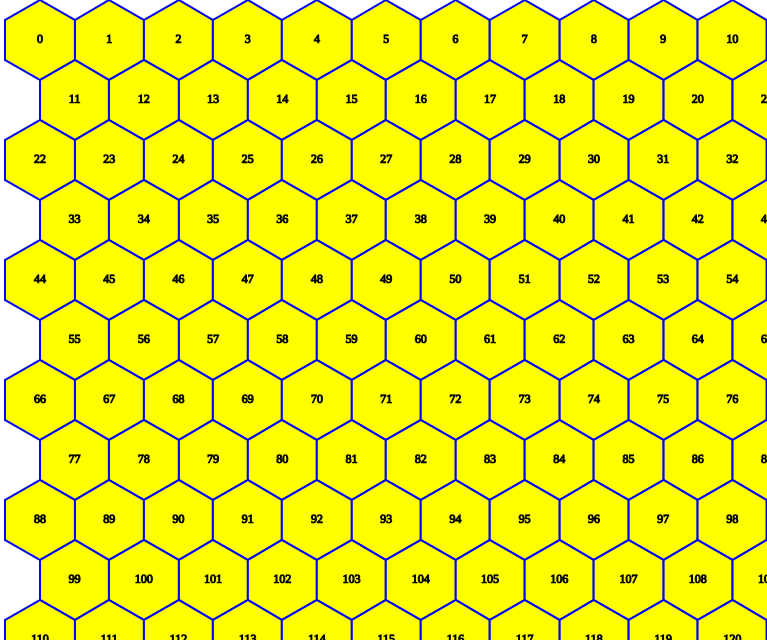

In [ ]:


sampleGrid = PrimitiveDemo().sampleGrid(fill="yellow",hexDim = 5,makeLabels = True)
sampleGrid.update()
sampleGrid.builder.show()



Another pass:
the question becomes how do we convert these into a rect. if we already know the rect by these indexes then we just need to intersect those that fit. if the rect is always at least one radius of our pattern away from the edge then we just need to find the hexchunks that have any member and then just crop them back. The find more than we need and then throw out the hexes is the right way to build these terrains


Does my math make any sense?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, your math and approach make sense!

**Ring sizes:**
- Ring 0: 1 hex (center)
- Ring 1: 6 hexes
- Ring 2: 12 hexes
- Ring N: 6×N hexes (for N > 0)
- Total for N rings: 1 + 3×N×(N+1)

**Corners and edges:** Exactly right - corners are at `N × pure_direction` (e.g., `6 × HexPosition.E` for ring 6 east corner), and edges interpolate between adjacent corners.

**The "over-fetch and filter" approach:**

```
1. Define target rectangle (in world hex coords)
2. Find which chunks intersect that rect
3. Generate/load those chunks (will include extras)
4. Create output grid sized to rect
5. For each hex in output grid:
   - Find which chunk contains it
   - Copy elevation from chunk
   - Skip if no chunk covers it (or fill from coarse)
```

This is cleaner than trying to perfectly tile hex-shaped chunks into a rect. You accept the geometric mismatch and just filter at the end.

```python
def rect_region_from_chunks(self, bounds: tuple[int,int,int,int], ...) -> Terrain:
    """Extract rectangular region from chunks.
    
    bounds: (min_q, max_q, min_r, max_r) in world coords
    """
    # Find intersecting chunks
    needed_chunks = self._chunks_intersecting_rect(bounds)
    
    # Load/generate them
    chunks = [self.generate_chunk(ref) for ref in needed_chunks]
    
    # Build rect grid, copy only what fits
    ...
```

Want me to sketch out the implementation?

### Mind the gap

Found 7 coastal chunks out of 19 total

=== GLOBAL MAP ===


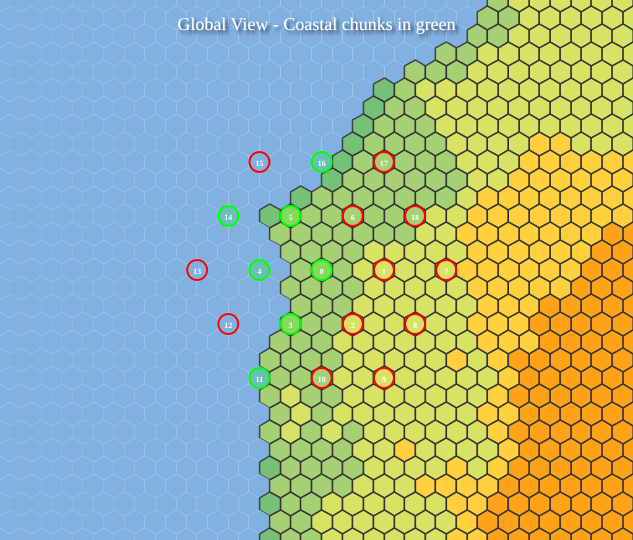

None


=== DETAIL VIEW (chunks [0, 3, 4]) ===


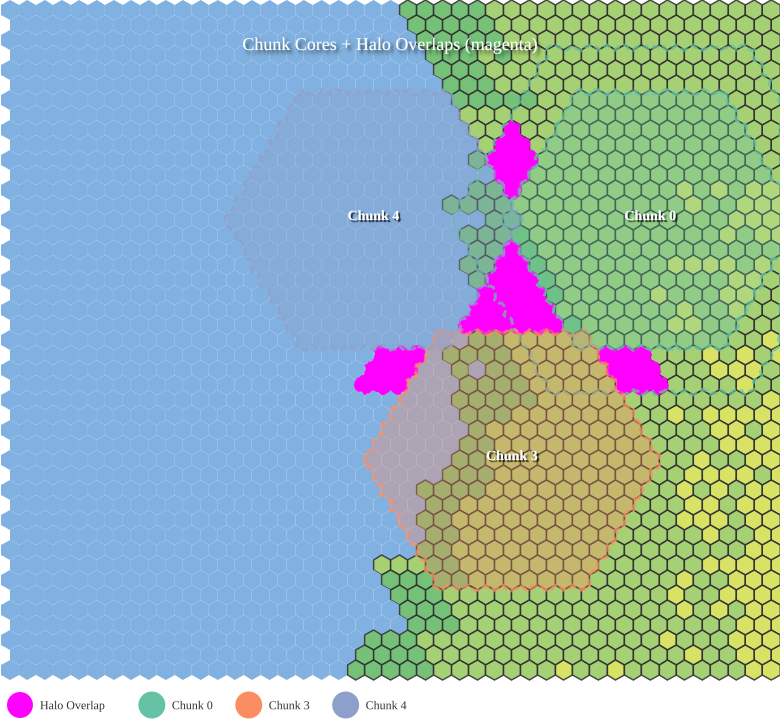

None

✓ Test database cleaned up


In [ ]:
def find_coastal_chunks(gen, coarse, max_ring=2):
    """Find chunks that contain both land and ocean."""
    all_chunks = list(gen.chunk_refs(max_ring=max_ring))
    coastal = []
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0: has_land = True
                    else: has_ocean = True
        
        if has_land and has_ocean:
            coastal.append((i, chunk_ref))
    
    return all_chunks, coastal


def render_global_map(gen, coarse, all_chunks, coastal_chunks):
    """Render coarse map with chunk locations marked."""
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    
    chunk_overlay = ""
    coastal_indices = {ci for ci, _ in coastal_chunks}
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            is_coastal = i in coastal_indices
            color = "#00ff00" if is_coastal else "#ff0000"
            fill = "rgba(0,255,0,0.2)" if is_coastal else "none"
            chunk_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="10" fill="{fill}" stroke="{color}" stroke-width="2"/>\n'
            chunk_overlay += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="8" font-weight="bold">{i}</text>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    coarse.hexGrid.builder.add_centered_text("Global View - Coastal chunks in green", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    return coarse.hexGrid.builder


def render_detail_with_overlaps(gen, coarse, selected_chunks):
    """Render detailed view showing cores and halo overlaps."""
    
    # Generate chunks and collect positions
    chunks_data = []
    all_core_positions = []
    all_halo_positions = []
    
    for global_idx, chunk_ref in selected_chunks:
        chunk = gen.generate_chunk(chunk_ref)
        core_positions = [chunk.index_to_world(idx) for idx in chunk.iter_core()]
        halo_positions = [chunk.index_to_world(idx) for idx in chunk.iter_halo()]
        chunks_data.append((global_idx, chunk_ref, chunk, core_positions, halo_positions))
        all_core_positions.extend(core_positions)
        all_halo_positions.extend(halo_positions)
    
    # Calculate bounds including halo
    all_pos = all_core_positions + all_halo_positions
    qs = [p.q for p in all_pos]
    rs = [p.r for p in all_pos]
    
    pad = 3
    min_q, max_q = min(qs) - pad, max(qs) + pad
    min_r, max_r = min(rs) - pad, max(rs) + pad
    
    # Generate detailed terrain
    detail = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
    detail.hexGrid.update()
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    # Build index sets for each chunk's core and halo
    chunk_cores = {}    # global_idx -> set of grid indices
    chunk_halos = {}    # global_idx -> set of grid indices
    
    for global_idx, chunk_ref, chunk, core_positions, halo_positions in chunks_data:
        core_indices = set()
        for world_pos in core_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                core_indices.add(grid_idx)
        chunk_cores[global_idx] = core_indices
        
        halo_indices = set()
        for world_pos in halo_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                halo_indices.add(grid_idx)
        chunk_halos[global_idx] = halo_indices
    
    # Calculate overlaps
    all_halo_indices = set()
    for indices in chunk_halos.values():
        all_halo_indices |= indices
    
    all_core_indices = set()
    for indices in chunk_cores.values():
        all_core_indices |= indices
    
    # Halo-only (not in any core)
    halo_only = all_halo_indices - all_core_indices
    
    # Find overlapping halo regions (in 2+ halos)
    from collections import Counter
    halo_counts = Counter()
    for indices in chunk_halos.values():
        for idx in indices:
            halo_counts[idx] += 1
    
    # Indices in multiple halos (overlap zone)
    overlap_indices = {idx for idx, count in halo_counts.items() if count >= 2}
    overlap_in_halo_only = overlap_indices & halo_only
    
    # Styles
    chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    detail.hexGrid.builder.add_style(textStyle)
    
    region_overlay = ""
    legend_styles = []
    
    # 1. Draw overlap region first (underneath everything)
    if overlap_in_halo_only:
        overlap_region = HexRegion(hexes=overlap_in_halo_only, hexGrid=detail.hexGrid)
        overlap_style = StyleCSS(
            "Halo_Overlap",
            fill="#ff00ff",  # Magenta for visibility
            stroke="#ff00ff",
            stroke_width=2,
            opacity=0.25
        )
        detail.hexGrid.builder.add_style(overlap_style)
        region_overlay += overlap_region.draw(style=overlap_style, f=unique_windy_edge(), inset=0.9)
        legend_styles.append(overlap_style.copy("Halo_Overlap"))
    
    # 2. Draw individual halo boundaries (dashed, no fill)
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        halo_indices = chunk_halos[global_idx]
        
        if halo_indices:
            halo_region = HexRegion(hexes=halo_indices, hexGrid=detail.hexGrid)
            halo_style = StyleCSS(
                f"Halo_{global_idx}",
                fill="none",
                stroke=base_color,
                stroke_width=3,
                stroke_dasharray="8,4",
                opacity=0.7
            )
            detail.hexGrid.builder.add_style(halo_style)
            region_overlay += halo_region.draw(style=halo_style, f=unique_windy_edge(), inset=0.98)
    
    # 3. Draw cores on top
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        core_indices = chunk_cores[global_idx]
        
        if core_indices:
            core_region = HexRegion(hexes=core_indices, hexGrid=detail.hexGrid)
            core_style = StyleCSS(
                f"Core_{global_idx}",
                fill=base_color,
                stroke=base_color,
                stroke_width=3,
                opacity=0.35
            )
            detail.hexGrid.builder.add_style(core_style)
            region_overlay += core_region.draw(style=core_style, f=unique_windy_edge(), inset=0.95)
            legend_styles.append(core_style.copy(f"Chunk_{global_idx}"))
            
            # Label at centroid
            centroid_idx = core_region.centroid_hex()
            if centroid_idx and 0 <= centroid_idx < len(detail.hexGrid.hexes):
                cx = detail.hexGrid.hexes[centroid_idx].center.x
                cy = detail.hexGrid.hexes[centroid_idx].center.y
                region_overlay += f'<text x="{cx}" y="{cy}" text-anchor="middle" fill="white" font-size="14" font-weight="bold" style="filter: drop-shadow(2px 2px 1px rgba(0,0,0,.8))">Chunk {global_idx}</text>\n'
    
    detail.hexGrid.builder.adjust("chunk_regions", region_overlay)
    
    # Add legend
    keyLabelStyle = StyleCSS("keyLabel", fill="#333", font_size="12px")
    detail.hexGrid.builder.add_style(keyLabelStyle)
    
    for style in legend_styles:
        style.properties['opacity'] = '1.0'
        detail.hexGrid.builder.add_style(style)
    
    legend_svg = detail.hexGrid.builder.legendBelow(legend_styles, gap=15, bg_fill="rgba(255,255,255,0.9)")
    detail.hexGrid.builder.adjust("legend", legend_svg)
    
    detail.hexGrid.builder.add_style(textStyle)
    detail.hexGrid.builder.add_centered_text("Chunk Cores + Halo Overlaps (magenta)", 
        y_offset=-detail.hexGrid.builder.height/2 + 50, class_name=textStyle.name)
    
    return detail.hexGrid.builder, chunks_data


# === MAIN DEMO ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # Find chunks
    all_chunks, coastal_chunks = find_coastal_chunks(gen, coarse)
    print(f"Found {len(coastal_chunks)} coastal chunks out of {len(all_chunks)} total")
    
    # 1. Global map
    print("\n=== GLOBAL MAP ===")
    global_builder = render_global_map(gen, coarse, all_chunks, coastal_chunks)
    display(global_builder.show())
    
    # 2. Detail view with first 3 coastal chunks
    selected = coastal_chunks[:3]
    print(f"\n=== DETAIL VIEW (chunks {[i for i, _ in selected]}) ===")
    detail_builder, chunks_data = render_detail_with_overlaps(gen, coarse, selected)
    display(detail_builder.show())


In [ ]:
def visualize_overlap_interpolation(gen, coarse, selected_chunks, zoom_padding=2):
    """Zoom into overlap zone and show chunk influence with gradients."""
    
    # Generate chunks
    chunks_data = []
    for global_idx, chunk_ref in selected_chunks:
        chunk = gen.generate_chunk(chunk_ref)
        chunks_data.append((global_idx, chunk_ref, chunk))
    
    # Find overlap positions (in 2+ chunk halos)
    position_chunks = {}  # world_pos -> list of (global_idx, chunk, local_idx)
    
    for global_idx, chunk_ref, chunk in chunks_data:
        for idx in chunk.iter_all():
            world_pos = chunk.index_to_world(idx)
            if world_pos not in position_chunks:
                position_chunks[world_pos] = []
            position_chunks[world_pos].append((global_idx, chunk, idx))
    
    overlap_positions = {pos for pos, chunks in position_chunks.items() if len(chunks) >= 2}
    
    if not overlap_positions:
        print("No overlap found!")
        return None
    
    # Bounds around overlap
    qs = [p.q for p in overlap_positions]
    rs = [p.r for p in overlap_positions]
    min_q, max_q = min(qs) - zoom_padding, max(qs) + zoom_padding
    min_r, max_r = min(rs) - zoom_padding, max(rs) + zoom_padding
    
    nrows = max_r - min_r + 1
    ncols = max_q - min_q + 1
    grid = HexGrid(nRows=nrows, nCols=ncols, radius=gen.fine_radius * 2, style=coarse.seaLevel)
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    # Chunk colors
    chunk_colors = {}
    chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
    for i, (global_idx, _, _) in enumerate(chunks_data):
        chunk_colors[global_idx] = chunk_styles[i].properties['fill']
    
    builder = SVGBuilder()
    builder.width = grid.builder.width
    builder.height = grid.builder.height
    
    for style in StyleCSS.elevations():
        builder.add_style(style)
    builder.add_style(coarse.seaLevel)
    
    # First pass: base terrain
    terrain_svg = ""
    for grid_idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(grid_idx, origin_index=0)
        world_pos = origin_world + local_pos
        hex_obj = grid.hexes[grid_idx]
        
        elev = 0
        if world_pos in position_chunks:
            _, chunk, chunk_idx = position_chunks[world_pos][0]
            elev = chunk.elevations[chunk_idx]
        
        level = int(elev / coarse.elevationDelta)
        level = max(0, min(level, len(StyleCSS.elevations()) - 1))
        style = coarse.seaLevel if elev <= 0 else StyleCSS.elevations()[level]
        hex_obj.style = style
        terrain_svg += "\t" + hex_obj.svg() + "\n"
    
    builder.adjust("terrain", terrain_svg)
    
    # Second pass: overlay with gradients
    overlay_svg = ""
    
    for grid_idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(grid_idx, origin_index=0)
        world_pos = origin_world + local_pos
        hex_obj = grid.hexes[grid_idx]
        
        if world_pos not in position_chunks:
            continue
        
        covering_chunks = position_chunks[world_pos]
        
        if len(covering_chunks) == 1:
            global_idx, chunk, _ = covering_chunks[0]
            color = chunk_colors[global_idx]
            overlay_svg += f'<polygon points="{" ".join(f"{v.x},{v.y}" for v in hex_obj.v)}" fill="{color}" opacity="0.3"/>\n'
            
        elif len(covering_chunks) >= 2:
            distances = []
            for global_idx, chunk, _ in covering_chunks:
                chunk_center = chunk.center_world
                dist = world_pos.distance(chunk_center)
                distances.append((global_idx, dist, chunk_colors[global_idx]))
            
            distances.sort(key=lambda x: x[1])
            
            grad_id = f"grad_{grid_idx}"
            color1 = distances[0][2]
            color2 = distances[1][2] if len(distances) > 1 else color1
            
            # Fixed: Use SVGDef correctly
            stops_content = f'''
                <stop offset="0%" stop-color="{color1}" stop-opacity="0.6"/>
                <stop offset="100%" stop-color="{color2}" stop-opacity="0.6"/>
            '''
            
            builder.add_definition(SVGDef(
                "radialGradient", 
                grad_id, 
                stops_content,
                cx="50%", cy="50%", r="70%"
            ))
            
            overlay_svg += f'<polygon points="{" ".join(f"{v.x},{v.y}" for v in hex_obj.v)}" fill="url(#{grad_id})"/>\n'
            
            # Indicator dots
            cx, cy = hex_obj.center.x, hex_obj.center.y
            for i, (global_idx, dist, color) in enumerate(distances[:3]):
                offset_x = (i - 1) * 8
                overlay_svg += f'<circle cx="{cx + offset_x}" cy="{cy - 5}" r="3" fill="{color}" stroke="white" stroke-width="1"/>'
    
    builder.adjust("overlap", overlay_svg)
    
    # Chunk center markers
    markers_svg = ""
    for global_idx, chunk_ref, chunk in chunks_data:
        chunk_center = chunk.center_world
        local_center = chunk_center - origin_world
        center_idx = grid.hexposition_to_index(local_center, origin_index=0)
        
        if 0 <= center_idx < len(grid.hexes):
            hex_obj = grid.hexes[center_idx]
            color = chunk_colors[global_idx]
            markers_svg += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="15" fill="{color}" stroke="white" stroke-width="3"/>\n'
            markers_svg += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 5}" text-anchor="middle" fill="white" font-size="12" font-weight="bold">{global_idx}</text>\n'
    
    builder.adjust("markers", markers_svg)
    
    textStyle = StyleCSS("textStyle", fill="#333", font_size="14px")
    builder.add_style(textStyle)
    builder.add_centered_text(
        "Overlap Zone - Gradient shows chunk influence (dots = covering chunks)",
        y_offset=-builder.height/2 + 25,
        class_name=textStyle.name
    )
    
    return builder


=== OVERLAP INTERPOLATION VISUALIZATION ===


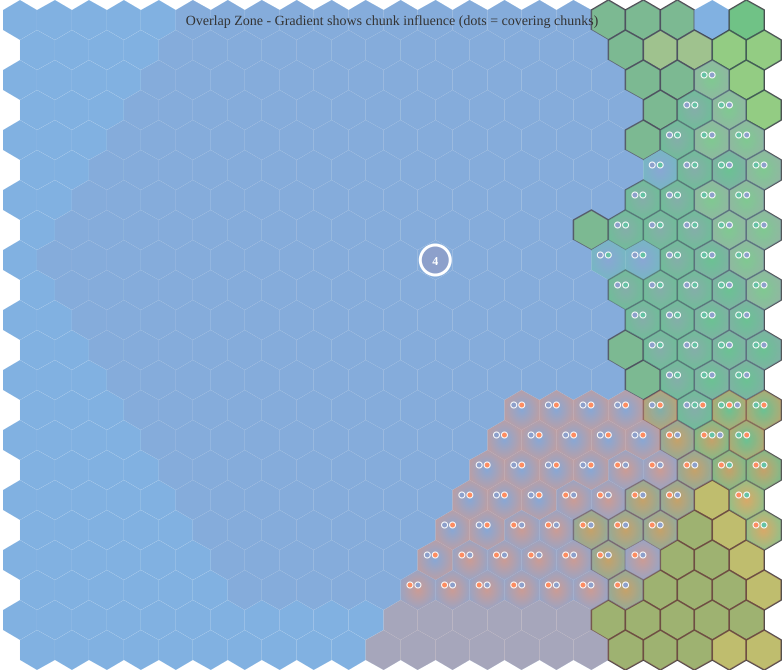

✓ Test database cleaned up


In [ ]:


# Test it
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.35, oceanic_sides=['W'], seed=42)
    
    all_chunks, coastal_chunks = find_coastal_chunks(gen, coarse)
    selected = coastal_chunks[:3]
    
    print("=== OVERLAP INTERPOLATION VISUALIZATION ===")
    overlap_builder = visualize_overlap_interpolation(gen, coarse, selected)
    if overlap_builder:
        overlap_builder.show()


Found 7 coastal chunks
=== GLOBAL MAP ===


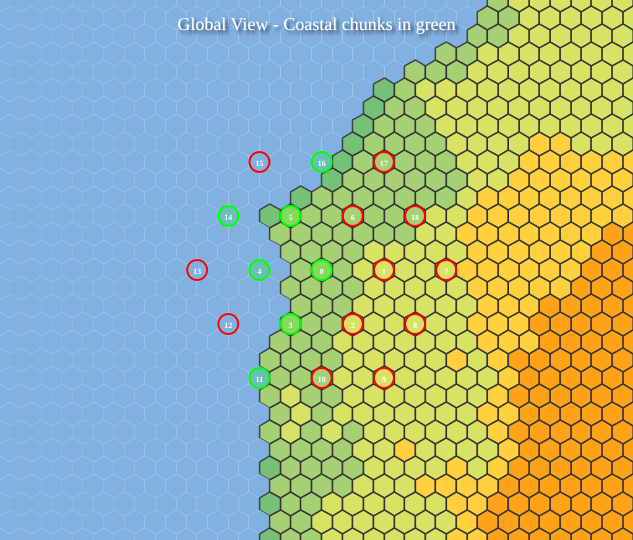

None


=== ZOOMED COASTAL DETAIL ===
Selected 3 coastal chunks
Detail grid: 43x43 = 1849 hexes


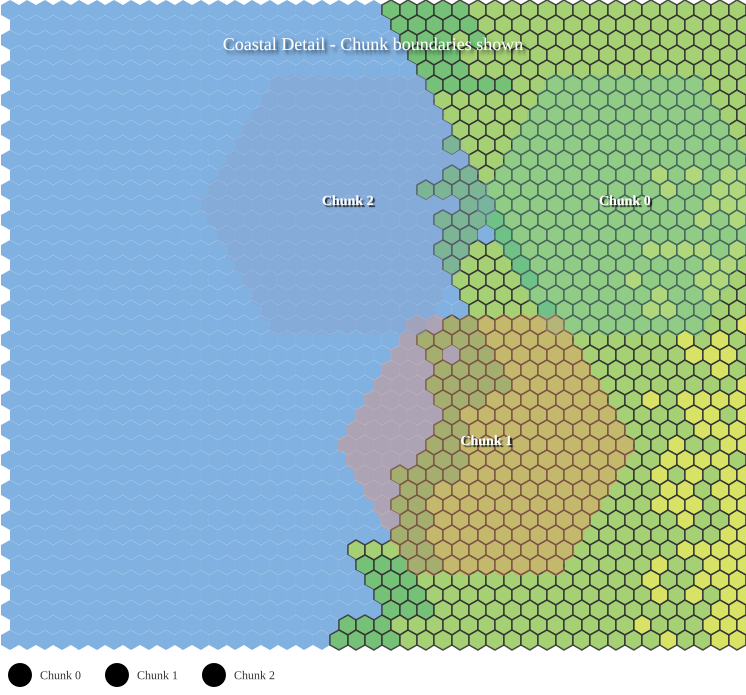

None

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # === PART 1: Global view with all chunks marked ===
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    
    # Find coastal chunks
    coastal_chunks = []
    for chunk_ref in gen.chunk_refs(max_ring=2):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = False
        has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0:
                        has_land = True
                    else:
                        has_ocean = True
        
        if has_land and has_ocean:
            coastal_chunks.append(chunk_ref)
    
    print(f"Found {len(coastal_chunks)} coastal chunks")
    
    # Mark chunks on global view
    chunk_overlay = ""
    for i, chunk_ref in enumerate(gen.chunk_refs(max_ring=2)):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            is_coastal = chunk_ref in coastal_chunks
            color = "#00ff00" if is_coastal else "#ff0000"
            fill = "rgba(0,255,0,0.2)" if is_coastal else "none"
            chunk_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="10" fill="{fill}" stroke="{color}" stroke-width="2"/>\n'
            chunk_overlay += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="8" font-weight="bold">{i}</text>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    coarse.hexGrid.builder.add_centered_text("Global View - Coastal chunks in green", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    print("=== GLOBAL MAP ===")
    display(coarse.hexGrid.builder.show())
    
    # === PART 2: Zoom into coastal region with chunk overlay ===
    if coastal_chunks:
        selected = coastal_chunks[:min(3, len(coastal_chunks))]
        
        # Generate chunks and collect positions
        chunks_data = []
        all_positions = []
        for chunk_ref in selected:
            chunk = gen.generate_chunk(chunk_ref)
            positions = [chunk.index_to_world(idx) for idx in chunk.iter_core()]
            chunks_data.append((chunk_ref, chunk, positions))
            all_positions.extend(positions)
        
        qs = [p.q for p in all_positions]
        rs = [p.r for p in all_positions]
        
        pad = 5
        min_q, max_q = min(qs) - pad, max(qs) + pad
        min_r, max_r = min(rs) - pad, max(rs) + pad
        
        # Generate detailed terrain
        detail = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
        detail.hexGrid.update()
        
        # Use seaborn palette for chunk colors
        chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
        
        # Make them semi-transparent for overlay
        for style in chunk_styles:
            style.properties['opacity'] = '0.4'
            style.properties['stroke_width'] = '3'
        
        # Add styles to builder
        for style in chunk_styles:
            detail.hexGrid.builder.add_style(style)
        
        # Create chunk region overlays
        origin_world = HexPosition(min_q, min_r, -min_q - min_r)
        
        region_overlay = ""
        legend_styles = []
        
        for i, (chunk_ref, chunk, world_positions) in enumerate(chunks_data):
            # Map chunk world positions to detail grid indices
            grid_indices = set()
            for world_pos in world_positions:
                local_pos = world_pos - origin_world
                grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
                if 0 <= grid_idx < len(detail.hexGrid.hexes):
                    grid_indices.add(grid_idx)
            
            if grid_indices:
                region = HexRegion(hexes=grid_indices, hexGrid=detail.hexGrid)
                
                # Create style for this chunk region
                base_style = chunk_styles[i]
                region_style = StyleCSS(
                    f"Chunk_{i}",
                    fill=base_style.properties['fill'],
                    stroke=base_style.properties['fill'],
                    stroke_width=3,
                    opacity=0.35
                )
                detail.hexGrid.builder.add_style(region_style)
                legend_styles.append(region_style.copy(f"Chunk {i}"))
                
                region_overlay += region.draw(style=region_style, f=unique_windy_edge(), inset=0.95)
                
                # Add chunk label at centroid
                centroid_idx = region.centroid_hex()
                if centroid_idx and 0 <= centroid_idx < len(detail.hexGrid.hexes):
                    cx = detail.hexGrid.hexes[centroid_idx].center.x
                    cy = detail.hexGrid.hexes[centroid_idx].center.y
                    region_overlay += f'<text x="{cx}" y="{cy}" text-anchor="middle" fill="white" font-size="14" font-weight="bold" style="filter: drop-shadow(2px 2px 1px rgba(0,0,0,.8))">Chunk {i}</text>\n'
        
        detail.hexGrid.builder.adjust("chunk_regions", region_overlay)
        
        # Add legend using legendBelow
        keyLabelStyle = StyleCSS("keyLabel", fill="#333", font_size="12px")
        detail.hexGrid.builder.add_style(keyLabelStyle)
        
        # Fix legend styles opacity for display
        for style in legend_styles:
            style.properties['opacity'] = '1.0'
            detail.hexGrid.builder.add_style(style)
        
        legend_svg = detail.hexGrid.builder.legendBelow(legend_styles, gap=15, bg_fill="rgba(255,255,255,0.9)")
        detail.hexGrid.builder.adjust("legend", legend_svg)
        
        # Add title
        detail.hexGrid.builder.add_style(textStyle)
        detail.hexGrid.builder.add_centered_text("Coastal Detail - Chunk boundaries shown", 
            y_offset=-detail.hexGrid.builder.height/2 + 50, class_name=textStyle.name)
        
        print(f"\n=== ZOOMED COASTAL DETAIL ===")
        print(f"Selected {len(selected)} coastal chunks")
        print(f"Detail grid: {detail.hexGrid.nRows}x{detail.hexGrid.nCols} = {len(detail.hexGrid.hexes)} hexes")
        display(detail.hexGrid.builder.show())


Found 7 coastal chunks
=== GLOBAL MAP ===


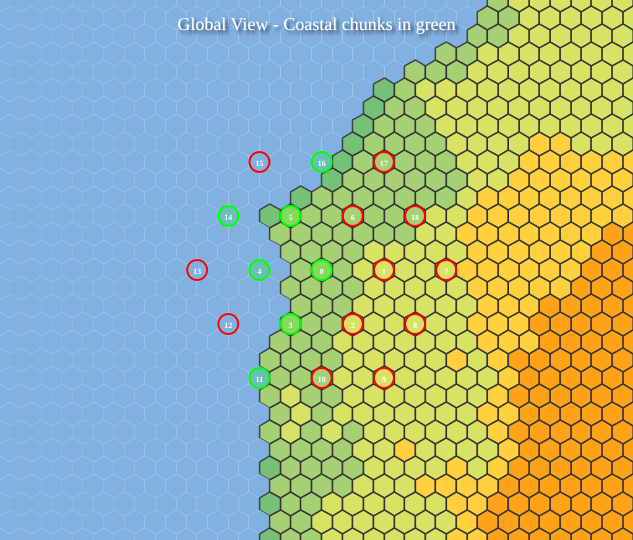

None


=== ZOOMED COASTAL DETAIL ===
Selected chunks: [0, 3, 4]
Detail grid: 43x43 = 1849 hexes


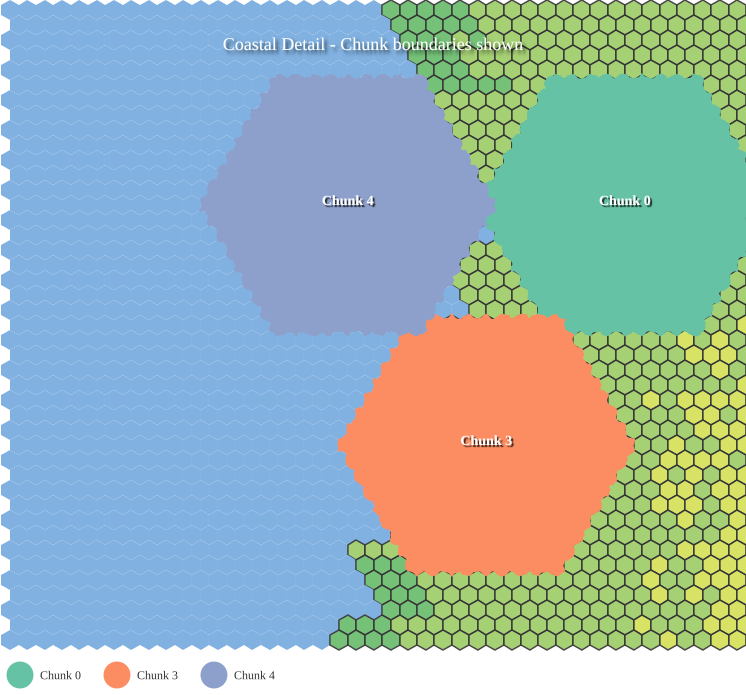

None

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # === PART 1: Global view with all chunks marked ===
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    
    # Build chunk list with indices
    all_chunks = list(gen.chunk_refs(max_ring=2))
    
    # Find coastal chunks (have both land and ocean) - store (index, chunk_ref)
    coastal_chunks = []
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = False
        has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0:
                        has_land = True
                    else:
                        has_ocean = True
        
        if has_land and has_ocean:
            coastal_chunks.append((i, chunk_ref))  # Store index with chunk_ref
    
    print(f"Found {len(coastal_chunks)} coastal chunks")
    
    # Mark chunks on global view
    chunk_overlay = ""
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            is_coastal = any(ci == i for ci, _ in coastal_chunks)
            color = "#00ff00" if is_coastal else "#ff0000"
            fill = "rgba(0,255,0,0.2)" if is_coastal else "none"
            chunk_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="10" fill="{fill}" stroke="{color}" stroke-width="2"/>\n'
            chunk_overlay += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="8" font-weight="bold">{i}</text>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    coarse.hexGrid.builder.add_centered_text("Global View - Coastal chunks in green", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    print("=== GLOBAL MAP ===")
    display(coarse.hexGrid.builder.show())
    
    # === PART 2: Zoom into coastal region ===
    if coastal_chunks:
        # Pick first 3 coastal chunks - keep their global indices
        selected = coastal_chunks[:min(3, len(coastal_chunks))]
        
        # Generate chunks and collect positions
        chunks_data = []
        all_positions = []
        for global_idx, chunk_ref in selected:
            chunk = gen.generate_chunk(chunk_ref)
            positions = [chunk.index_to_world(idx) for idx in chunk.iter_core()]
            chunks_data.append((global_idx, chunk_ref, chunk, positions))
            all_positions.extend(positions)
        
        qs = [p.q for p in all_positions]
        rs = [p.r for p in all_positions]
        
        pad = 5
        min_q, max_q = min(qs) - pad, max(qs) + pad
        min_r, max_r = min(rs) - pad, max(rs) + pad
        
        # Generate detailed terrain
        detail = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
        detail.hexGrid.update()
        
        # Use seaborn palette for chunk colors
        chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))

        for style in chunk_styles:
            style.properties['opacity'] = '0.4'
            style.properties['stroke_width'] = '3'
        
        for style in chunk_styles:
            detail.hexGrid.builder.add_style(style)
        
        # Create chunk region overlays
        origin_world = HexPosition(min_q, min_r, -min_q - min_r)
        
        region_overlay = ""
        legend_styles = []
        
        for i, (global_idx, chunk_ref, chunk, world_positions) in enumerate(chunks_data):
            # Map chunk world positions to detail grid indices
            grid_indices = set()
            for world_pos in world_positions:
                local_pos = world_pos - origin_world
                grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
                if 0 <= grid_idx < len(detail.hexGrid.hexes):
                    grid_indices.add(grid_idx)
            
            if grid_indices:
                region = HexRegion(hexes=grid_indices, hexGrid=detail.hexGrid)
                
                base_style = chunk_styles[i]
                # Use underscore in style name
                region_style = StyleCSS(
                    f"Chunk_{global_idx}",
                    fill=base_style.properties['fill'],
                    stroke=base_style.properties['fill'],
                    stroke_width=3,
                    opacity=0.35
                )
                detail.hexGrid.builder.add_style(region_style)
                # Legend style with underscore (will display with space via name parsing)
                legend_styles.append(region_style.copy(f"Chunk_{global_idx}"))
                
                region_overlay += region.draw(style=region_style, f=unique_windy_edge(), inset=0.95)
                
                # Add chunk label at centroid - use global index
                centroid_idx = region.centroid_hex()
                if centroid_idx and 0 <= centroid_idx < len(detail.hexGrid.hexes):
                    cx = detail.hexGrid.hexes[centroid_idx].center.x
                    cy = detail.hexGrid.hexes[centroid_idx].center.y
                    region_overlay += f'<text x="{cx}" y="{cy}" text-anchor="middle" fill="white" font-size="14" font-weight="bold" style="filter: drop-shadow(2px 2px 1px rgba(0,0,0,.8))">Chunk {global_idx}</text>\n'
        
        detail.hexGrid.builder.adjust("chunk_regions", region_overlay)
        
        # Add legend
        keyLabelStyle = StyleCSS("keyLabel", fill="#333", font_size="12px")
        detail.hexGrid.builder.add_style(keyLabelStyle)
        
        for style in legend_styles:
            style.properties['opacity'] = '1.0'
            detail.hexGrid.builder.add_style(style)
        
        legend_svg = detail.hexGrid.builder.legendBelow(legend_styles, gap=15, bg_fill="rgba(255,255,255,0.9)")
        detail.hexGrid.builder.adjust("legend", legend_svg)
        
        detail.hexGrid.builder.add_style(textStyle)
        detail.hexGrid.builder.add_centered_text("Coastal Detail - Chunk boundaries shown", 
            y_offset=-detail.hexGrid.builder.height/2 + 50, class_name=textStyle.name)
        
        print(f"\n=== ZOOMED COASTAL DETAIL ===")
        print(f"Selected chunks: {[gi for gi, _, _, _ in chunks_data]}")
        print(f"Detail grid: {detail.hexGrid.nRows}x{detail.hexGrid.nCols} = {len(detail.hexGrid.hexes)} hexes")
        display(detail.hexGrid.builder.show())


Chunk rings: 8, Halo rings: 3
Core size per chunk: 217
Halo size per chunk: 180


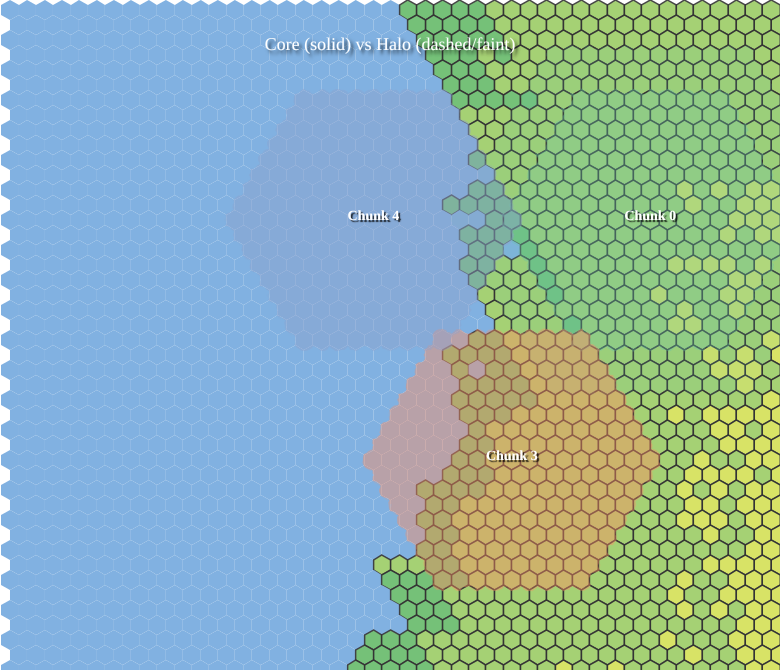

None

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # Get coastal chunks
    all_chunks = list(gen.chunk_refs(max_ring=2))
    coastal_chunks = []
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0: has_land = True
                    else: has_ocean = True
        if has_land and has_ocean:
            coastal_chunks.append((i, chunk_ref))
    
    # Select first 3 coastal chunks
    selected = coastal_chunks[:3]
    
    # Generate chunks
    chunks_data = []
    all_positions = []
    all_halo_positions = []
    
    for global_idx, chunk_ref in selected:
        chunk = gen.generate_chunk(chunk_ref)
        core_positions = [chunk.index_to_world(idx) for idx in chunk.iter_core()]
        halo_positions = [chunk.index_to_world(idx) for idx in chunk.iter_halo()]
        chunks_data.append((global_idx, chunk_ref, chunk, core_positions, halo_positions))
        all_positions.extend(core_positions)
        all_halo_positions.extend(halo_positions)
    
    # Calculate bounds including halo
    all_pos = all_positions + all_halo_positions
    qs = [p.q for p in all_pos]
    rs = [p.r for p in all_pos]
    
    pad = 3
    min_q, max_q = min(qs) - pad, max(qs) + pad
    min_r, max_r = min(rs) - pad, max(rs) + pad
    
    # Generate detailed terrain
    detail = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
    detail.hexGrid.update()
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    # Styles
    chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    detail.hexGrid.builder.add_style(textStyle)
    
    region_overlay = ""
    
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        
        # Map HALO positions to grid (draw first, so core overlays)
        halo_indices = set()
        for world_pos in halo_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                halo_indices.add(grid_idx)
        
        if halo_indices:
            halo_region = HexRegion(hexes=halo_indices, hexGrid=detail.hexGrid)
            halo_style = StyleCSS(
                f"Halo_{global_idx}",
                fill=base_color,
                stroke=base_color,
                stroke_width=1,
                stroke_dasharray="4,2",
                opacity=0.15
            )
            detail.hexGrid.builder.add_style(halo_style)
            region_overlay += halo_region.draw(style=halo_style, f=unique_windy_edge(), inset=0.95)
        
        # Map CORE positions to grid
        core_indices = set()
        for world_pos in core_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                core_indices.add(grid_idx)
        
        if core_indices:
            core_region = HexRegion(hexes=core_indices, hexGrid=detail.hexGrid)
            core_style = StyleCSS(
                f"Core_{global_idx}",
                fill=base_color,
                stroke=base_color,
                stroke_width=3,
                opacity=0.35
            )
            detail.hexGrid.builder.add_style(core_style)
            region_overlay += core_region.draw(style=core_style, f=unique_windy_edge(), inset=0.95)
            
            # Label
            centroid_idx = core_region.centroid_hex()
            if centroid_idx and 0 <= centroid_idx < len(detail.hexGrid.hexes):
                cx = detail.hexGrid.hexes[centroid_idx].center.x
                cy = detail.hexGrid.hexes[centroid_idx].center.y
                region_overlay += f'<text x="{cx}" y="{cy}" text-anchor="middle" fill="white" font-size="14" font-weight="bold" style="filter: drop-shadow(2px 2px 1px rgba(0,0,0,.8))">Chunk {global_idx}</text>\n'
    
    detail.hexGrid.builder.adjust("chunk_regions", region_overlay)
    detail.hexGrid.builder.add_centered_text("Core (solid) vs Halo (dashed/faint)", 
        y_offset=-detail.hexGrid.builder.height/2 + 50, class_name=textStyle.name)
    
    print(f"Chunk rings: {gen.chunk_rings}, Halo rings: {gen.halo_rings}")
    print(f"Core size per chunk: {chunks_data[0][2].core_size}")
    print(f"Halo size per chunk: {len(list(chunks_data[0][2].iter_halo()))}")
    display(detail.hexGrid.builder.show())


Chunk rings: 8, Halo rings: 3
Core size per chunk: 217
Halo size per chunk: 180


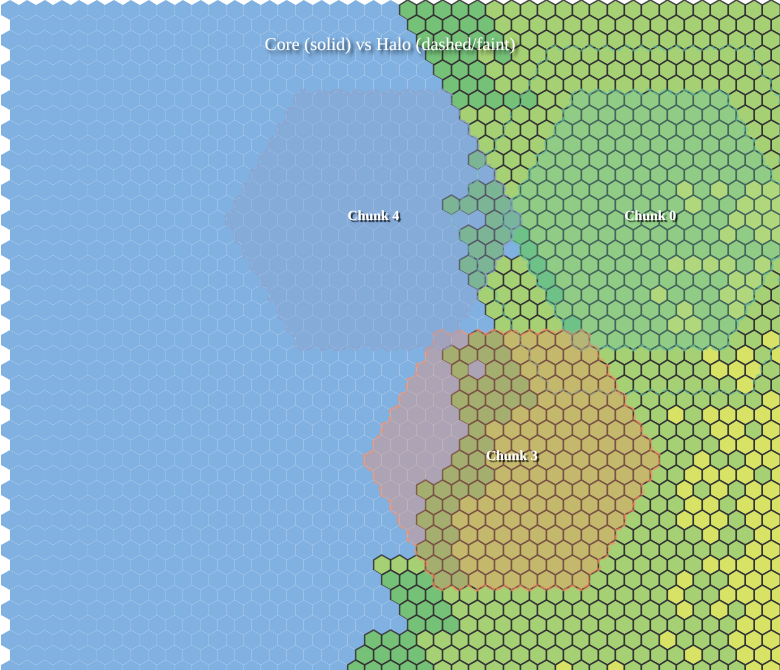

None

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # Get coastal chunks
    all_chunks = list(gen.chunk_refs(max_ring=2))
    coastal_chunks = []
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0: has_land = True
                    else: has_ocean = True
        if has_land and has_ocean:
            coastal_chunks.append((i, chunk_ref))
    
    # Select first 3 coastal chunks
    selected = coastal_chunks[:3]
    
    # Generate chunks
    chunks_data = []
    all_positions = []
    all_halo_positions = []
    
    for global_idx, chunk_ref in selected:
        chunk = gen.generate_chunk(chunk_ref)
        core_positions = [chunk.index_to_world(idx) for idx in chunk.iter_core()]
        halo_positions = [chunk.index_to_world(idx) for idx in chunk.iter_halo()]
        chunks_data.append((global_idx, chunk_ref, chunk, core_positions, halo_positions))
        all_positions.extend(core_positions)
        all_halo_positions.extend(halo_positions)
    
    # Calculate bounds including halo
    all_pos = all_positions + all_halo_positions
    qs = [p.q for p in all_pos]
    rs = [p.r for p in all_pos]
    
    pad = 3
    min_q, max_q = min(qs) - pad, max(qs) + pad
    min_r, max_r = min(rs) - pad, max(rs) + pad
    
    # Generate detailed terrain
    detail = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
    detail.hexGrid.update()
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    # Styles
    chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    detail.hexGrid.builder.add_style(textStyle)
    
    ## added
    # ... (same setup code) ...

    region_overlay = ""
    
    # FIRST PASS: Draw all halos
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        
        halo_indices = set()
        for world_pos in halo_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                halo_indices.add(grid_idx)
        
        if halo_indices:
            halo_region = HexRegion(hexes=halo_indices, hexGrid=detail.hexGrid)
            halo_style = StyleCSS(
                f"Halo_{global_idx}",
                fill="none",  # No fill, just boundary
                stroke=base_color,
                stroke_width=2,
                stroke_dasharray="6,3",
                opacity=0.6
            )
            detail.hexGrid.builder.add_style(halo_style)
            region_overlay += halo_region.draw(style=halo_style, f=unique_windy_edge(), inset=0.95)
    
    # SECOND PASS: Draw all cores (on top of halos)
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        
        core_indices = set()
        for world_pos in core_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                core_indices.add(grid_idx)
        
        if core_indices:
            core_region = HexRegion(hexes=core_indices, hexGrid=detail.hexGrid)
            core_style = StyleCSS(
                f"Core_{global_idx}",
                fill=base_color,
                stroke=base_color,
                stroke_width=3,
                opacity=0.35
            )
            detail.hexGrid.builder.add_style(core_style)
            region_overlay += core_region.draw(style=core_style, f=unique_windy_edge(), inset=0.95)
            
            # Label
            centroid_idx = core_region.centroid_hex()
            if centroid_idx and 0 <= centroid_idx < len(detail.hexGrid.hexes):
                cx = detail.hexGrid.hexes[centroid_idx].center.x
                cy = detail.hexGrid.hexes[centroid_idx].center.y
                region_overlay += f'<text x="{cx}" y="{cy}" text-anchor="middle" fill="white" font-size="14" font-weight="bold" style="filter: drop-shadow(2px 2px 1px rgba(0,0,0,.8))">Chunk {global_idx}</text>\n'
    
    detail.hexGrid.builder.adjust("chunk_regions", region_overlay)

    ## end add
    detail.hexGrid.builder.add_centered_text("Core (solid) vs Halo (dashed/faint)", 
        y_offset=-detail.hexGrid.builder.height/2 + 50, class_name=textStyle.name)
    
    print(f"Chunk rings: {gen.chunk_rings}, Halo rings: {gen.halo_rings}")
    print(f"Core size per chunk: {chunks_data[0][2].core_size}")
    print(f"Halo size per chunk: {len(list(chunks_data[0][2].iter_halo()))}")
    display(detail.hexGrid.builder.show())


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # Get coastal chunks (same as before)
    all_chunks = list(gen.chunk_refs(max_ring=2))
    coastal_chunks = []
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0: has_land = True
                    else: has_ocean = True
        if has_land and has_ocean:
            coastal_chunks.append((i, chunk_ref))
    
    selected = coastal_chunks[:3]
    
    # DEBUG: Check what's happening
    for global_idx, chunk_ref in selected:
        chunk = gen.generate_chunk(chunk_ref)
        print(f"Chunk {global_idx}: center_world={chunk.center_world}")
        print(f"  Core hexes: {chunk.core_size}, Halo hexes: {len(chunk) - chunk.core_size}")
        
        # Check halo world positions
        halo_positions = [chunk.index_to_world(idx) for idx in chunk.iter_halo()]
        if halo_positions:
            print(f"  Halo sample positions: {halo_positions[:3]}")
    
    # Check triangle: what's in the middle between chunk centers?
    chunk_centers = [gen.generate_chunk(cr).center_world for _, cr in selected]
    print(f"\nChunk centers: {chunk_centers}")
    
    # Find the centroid of the 3 chunk centers
    avg_q = sum(c.q for c in chunk_centers) // 3
    avg_r = sum(c.r for c in chunk_centers) // 3
    avg_s = -avg_q - avg_r
    centroid = HexPosition(avg_q, avg_r, avg_s)
    print(f"Triangle centroid: {centroid}")
    
    # Check if centroid is covered by any chunk's core or halo
    for global_idx, chunk_ref in selected:
        chunk = gen.generate_chunk(chunk_ref)
        local_idx = chunk.world_to_index(centroid)
        if local_idx >= 0:
            in_core = chunk.is_core(local_idx)
            in_halo = chunk.is_halo(local_idx)
            print(f"  Centroid in chunk {global_idx}: core={in_core}, halo={in_halo}")
        else:
            dist = centroid.distance(chunk.center_world)
            print(f"  Centroid NOT in chunk {global_idx} (distance={dist}, max halo dist={gen.chunk_rings + gen.halo_rings})")


Chunk 0: center_world=HexPosition(0, 0, 0)
  Core hexes: 217, Halo hexes: 180
  Halo sample positions: [HexPosition(9, -8, -1), HexPosition(9, -7, -2), HexPosition(9, -6, -3)]
Chunk 3: center_world=HexPosition(-16, 16, 0)
  Core hexes: 217, Halo hexes: 180
  Halo sample positions: [HexPosition(-7, 8, -1), HexPosition(-7, 9, -2), HexPosition(-7, 10, -3)]
Chunk 4: center_world=HexPosition(-16, 0, 16)
  Core hexes: 217, Halo hexes: 180
  Halo sample positions: [HexPosition(-7, -8, 15), HexPosition(-7, -7, 14), HexPosition(-7, -6, 13)]

Chunk centers: [HexPosition(0, 0, 0), HexPosition(-16, 16, 0), HexPosition(-16, 0, 16)]
Triangle centroid: HexPosition(-11, 5, 6)
  Centroid in chunk 0: core=False, halo=True
  Centroid in chunk 3: core=False, halo=True
  Centroid in chunk 4: core=False, halo=True
✓ Test database cleaned up


Found 7 coastal chunks out of 19 total

=== GLOBAL MAP ===


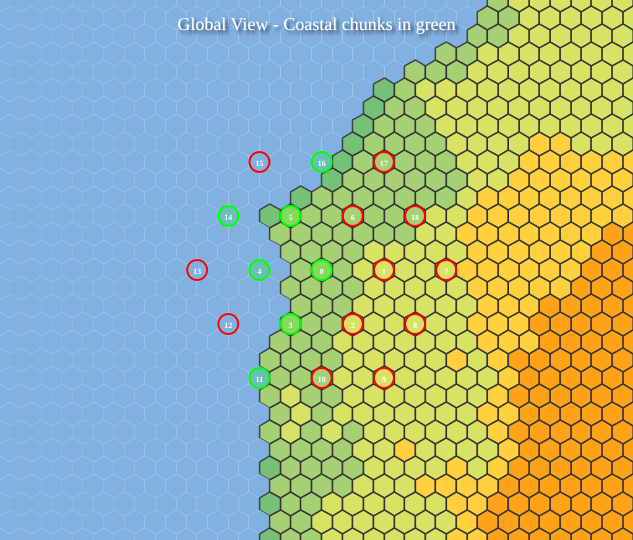

None


=== DETAIL VIEW (chunks [0, 3, 4]) ===


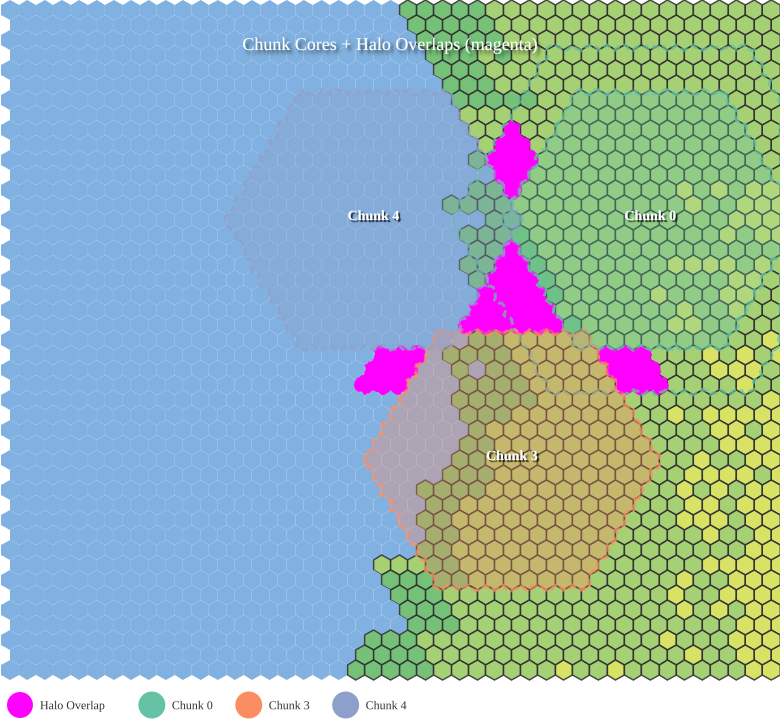

None

✓ Test database cleaned up


In [ ]:
def find_coastal_chunks(gen, coarse, max_ring=2):
    """Find chunks that contain both land and ocean."""
    all_chunks = list(gen.chunk_refs(max_ring=max_ring))
    coastal = []
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        
        has_land = has_ocean = False
        for ring in range(3):
            positions = [HexPosition(coarse_q, coarse_r, coarse_s)] if ring == 0 else \
                        HexPosition(coarse_q, coarse_r, coarse_s).ring(ring)
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if 0 <= idx < len(coarse.elevations):
                    if coarse.elevations[idx] > 0: has_land = True
                    else: has_ocean = True
        
        if has_land and has_ocean:
            coastal.append((i, chunk_ref))
    
    return all_chunks, coastal


def render_global_map(gen, coarse, all_chunks, coastal_chunks):
    """Render coarse map with chunk locations marked."""
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    
    chunk_overlay = ""
    coastal_indices = {ci for ci, _ in coastal_chunks}
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            is_coastal = i in coastal_indices
            color = "#00ff00" if is_coastal else "#ff0000"
            fill = "rgba(0,255,0,0.2)" if is_coastal else "none"
            chunk_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="10" fill="{fill}" stroke="{color}" stroke-width="2"/>\n'
            chunk_overlay += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="8" font-weight="bold">{i}</text>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    coarse.hexGrid.builder.add_centered_text("Global View - Coastal chunks in green", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    return coarse.hexGrid.builder


def render_detail_with_overlaps(gen, coarse, selected_chunks):
    """Render detailed view showing cores and halo overlaps."""
    
    # Generate chunks and collect positions
    chunks_data = []
    all_core_positions = []
    all_halo_positions = []
    
    for global_idx, chunk_ref in selected_chunks:
        chunk = gen.generate_chunk(chunk_ref)
        core_positions = [chunk.index_to_world(idx) for idx in chunk.iter_core()]
        halo_positions = [chunk.index_to_world(idx) for idx in chunk.iter_halo()]
        chunks_data.append((global_idx, chunk_ref, chunk, core_positions, halo_positions))
        all_core_positions.extend(core_positions)
        all_halo_positions.extend(halo_positions)
    
    # Calculate bounds including halo
    all_pos = all_core_positions + all_halo_positions
    qs = [p.q for p in all_pos]
    rs = [p.r for p in all_pos]
    
    pad = 3
    min_q, max_q = min(qs) - pad, max(qs) + pad
    min_r, max_r = min(rs) - pad, max(rs) + pad
    
    # Generate detailed terrain
    detail = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
    detail.hexGrid.update()
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    # Build index sets for each chunk's core and halo
    chunk_cores = {}    # global_idx -> set of grid indices
    chunk_halos = {}    # global_idx -> set of grid indices
    
    for global_idx, chunk_ref, chunk, core_positions, halo_positions in chunks_data:
        core_indices = set()
        for world_pos in core_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                core_indices.add(grid_idx)
        chunk_cores[global_idx] = core_indices
        
        halo_indices = set()
        for world_pos in halo_positions:
            local_pos = world_pos - origin_world
            grid_idx = detail.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(detail.hexGrid.hexes):
                halo_indices.add(grid_idx)
        chunk_halos[global_idx] = halo_indices
    
    # Calculate overlaps
    all_halo_indices = set()
    for indices in chunk_halos.values():
        all_halo_indices |= indices
    
    all_core_indices = set()
    for indices in chunk_cores.values():
        all_core_indices |= indices
    
    # Halo-only (not in any core)
    halo_only = all_halo_indices - all_core_indices
    
    # Find overlapping halo regions (in 2+ halos)
    from collections import Counter
    halo_counts = Counter()
    for indices in chunk_halos.values():
        for idx in indices:
            halo_counts[idx] += 1
    
    # Indices in multiple halos (overlap zone)
    overlap_indices = {idx for idx, count in halo_counts.items() if count >= 2}
    overlap_in_halo_only = overlap_indices & halo_only
    
    # Styles
    chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    detail.hexGrid.builder.add_style(textStyle)
    
    region_overlay = ""
    legend_styles = []
    
    # 1. Draw overlap region first (underneath everything)
    if overlap_in_halo_only:
        overlap_region = HexRegion(hexes=overlap_in_halo_only, hexGrid=detail.hexGrid)
        overlap_style = StyleCSS(
            "Halo_Overlap",
            fill="#ff00ff",  # Magenta for visibility
            stroke="#ff00ff",
            stroke_width=2,
            opacity=0.25
        )
        detail.hexGrid.builder.add_style(overlap_style)
        region_overlay += overlap_region.draw(style=overlap_style, f=unique_windy_edge(), inset=0.9)
        legend_styles.append(overlap_style.copy("Halo_Overlap"))
    
    # 2. Draw individual halo boundaries (dashed, no fill)
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        halo_indices = chunk_halos[global_idx]
        
        if halo_indices:
            halo_region = HexRegion(hexes=halo_indices, hexGrid=detail.hexGrid)
            halo_style = StyleCSS(
                f"Halo_{global_idx}",
                fill="none",
                stroke=base_color,
                stroke_width=3,
                stroke_dasharray="8,4",
                opacity=0.7
            )
            detail.hexGrid.builder.add_style(halo_style)
            region_overlay += halo_region.draw(style=halo_style, f=unique_windy_edge(), inset=0.98)
    
    # 3. Draw cores on top
    for i, (global_idx, chunk_ref, chunk, core_positions, halo_positions) in enumerate(chunks_data):
        base_color = chunk_styles[i].properties['fill']
        core_indices = chunk_cores[global_idx]
        
        if core_indices:
            core_region = HexRegion(hexes=core_indices, hexGrid=detail.hexGrid)
            core_style = StyleCSS(
                f"Core_{global_idx}",
                fill=base_color,
                stroke=base_color,
                stroke_width=3,
                opacity=0.35
            )
            detail.hexGrid.builder.add_style(core_style)
            region_overlay += core_region.draw(style=core_style, f=unique_windy_edge(), inset=0.95)
            legend_styles.append(core_style.copy(f"Chunk_{global_idx}"))
            
            # Label at centroid
            centroid_idx = core_region.centroid_hex()
            if centroid_idx and 0 <= centroid_idx < len(detail.hexGrid.hexes):
                cx = detail.hexGrid.hexes[centroid_idx].center.x
                cy = detail.hexGrid.hexes[centroid_idx].center.y
                region_overlay += f'<text x="{cx}" y="{cy}" text-anchor="middle" fill="white" font-size="14" font-weight="bold" style="filter: drop-shadow(2px 2px 1px rgba(0,0,0,.8))">Chunk {global_idx}</text>\n'
    
    detail.hexGrid.builder.adjust("chunk_regions", region_overlay)
    
    # Add legend
    keyLabelStyle = StyleCSS("keyLabel", fill="#333", font_size="12px")
    detail.hexGrid.builder.add_style(keyLabelStyle)
    
    for style in legend_styles:
        style.properties['opacity'] = '1.0'
        detail.hexGrid.builder.add_style(style)
    
    legend_svg = detail.hexGrid.builder.legendBelow(legend_styles, gap=15, bg_fill="rgba(255,255,255,0.9)")
    detail.hexGrid.builder.adjust("legend", legend_svg)
    
    detail.hexGrid.builder.add_style(textStyle)
    detail.hexGrid.builder.add_centered_text("Chunk Cores + Halo Overlaps (magenta)", 
        y_offset=-detail.hexGrid.builder.height/2 + 50, class_name=textStyle.name)
    
    return detail.hexGrid.builder, chunks_data


# === MAIN DEMO ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    # Find chunks
    all_chunks, coastal_chunks = find_coastal_chunks(gen, coarse)
    print(f"Found {len(coastal_chunks)} coastal chunks out of {len(all_chunks)} total")
    
    # 1. Global map
    print("\n=== GLOBAL MAP ===")
    global_builder = render_global_map(gen, coarse, all_chunks, coastal_chunks)
    display(global_builder.show())
    
    # 2. Detail view with first 3 coastal chunks
    selected = coastal_chunks[:3]
    print(f"\n=== DETAIL VIEW (chunks {[i for i, _ in selected]}) ===")
    detail_builder, chunks_data = render_detail_with_overlaps(gen, coarse, selected)
    display(detail_builder.show())


In [ ]:
def visualize_overlap_interpolation(gen, coarse, selected_chunks, zoom_padding=2):
    """Zoom into overlap zone and show chunk influence with gradient patterns."""
    
    # Generate chunks
    chunks_data = []
    for global_idx, chunk_ref in selected_chunks:
        chunk = gen.generate_chunk(chunk_ref)
        chunks_data.append((global_idx, chunk_ref, chunk))
    
    # Find overlap positions (in 2+ chunk halos)
    position_chunks = {}  # world_pos -> list of (global_idx, chunk, local_idx)
    
    for global_idx, chunk_ref, chunk in chunks_data:
        for idx in chunk.iter_all():
            world_pos = chunk.index_to_world(idx)
            if world_pos not in position_chunks:
                position_chunks[world_pos] = []
            position_chunks[world_pos].append((global_idx, chunk, idx))
    
    overlap_positions = {pos for pos, chunks in position_chunks.items() if len(chunks) >= 2}
    
    if not overlap_positions:
        print("No overlap found!")
        return None
    
    # Bounds around overlap
    qs = [p.q for p in overlap_positions]
    rs = [p.r for p in overlap_positions]
    min_q, max_q = min(qs) - zoom_padding, max(qs) + zoom_padding
    min_r, max_r = min(rs) - zoom_padding, max(rs) + zoom_padding
    
    nrows = max_r - min_r + 1
    ncols = max_q - min_q + 1
    grid = HexGrid(nRows=nrows, nCols=ncols, radius=gen.fine_radius * 2, style=coarse.seaLevel)
    
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    # Chunk colors
    chunk_colors = {}
    chunk_styles = StyleCSS.seaborn("Set2", len(chunks_data))
    for i, (global_idx, _, _) in enumerate(chunks_data):
        chunk_colors[global_idx] = chunk_styles[i].properties['fill']
    
    # Create patterns for each chunk at different densities
    patternGen = TerrainPatterns(coarse)
    density_levels = 6
    chunk_patterns = {}  # (global_idx, level) -> pattern
    
    for i, (global_idx, _, _) in enumerate(chunks_data):
        color = chunk_colors[global_idx]
        patterns = patternGen.ballDensity(
            levels=density_levels,
            fills=[color],
            prefix=f"chunk_{global_idx}"
        )
        for level, pattern in enumerate(patterns):
            chunk_patterns[(global_idx, level)] = pattern
    
    # Build SVG
    builder = SVGBuilder()
    builder.width = grid.builder.width
    builder.height = grid.builder.height
    
    # Add terrain styles
    for style in StyleCSS.elevations():
        builder.add_style(style)
    builder.add_style(coarse.seaLevel)
    
    # Add all patterns to builder
    for pattern in chunk_patterns.values():
        builder.add_definition(pattern)
    
    # First pass: base terrain
    terrain_svg = ""
    for grid_idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(grid_idx, origin_index=0)
        world_pos = origin_world + local_pos
        hex_obj = grid.hexes[grid_idx]
        
        elev = 0
        if world_pos in position_chunks:
            _, chunk, chunk_idx = position_chunks[world_pos][0]
            elev = chunk.elevations[chunk_idx]
        
        level = int(elev / coarse.elevationDelta)
        level = max(0, min(level, len(StyleCSS.elevations()) - 1))
        style = coarse.seaLevel if elev <= 0 else StyleCSS.elevations()[level]
        hex_obj.style = style
        terrain_svg += "\t" + hex_obj.svg() + "\n"
    
    builder.adjust("terrain", terrain_svg)
    
    # Second pass: overlay with influence patterns - NO OPACITY
    overlay_svg = ""
    
    for grid_idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(grid_idx, origin_index=0)
        world_pos = origin_world + local_pos
        hex_obj = grid.hexes[grid_idx]
        
        if world_pos not in position_chunks:
            continue
        
        covering_chunks = position_chunks[world_pos]
        
        # Calculate influence (inverse distance) for each chunk
        influences = []
        for global_idx, chunk, _ in covering_chunks:
            chunk_center = chunk.center_world
            dist = world_pos.distance(chunk_center)
            max_dist = gen.chunk_rings + gen.halo_rings
            # Influence: 1.0 at center, 0.0 at edge of halo
            influence = max(0, 1.0 - dist / max_dist)
            influences.append((global_idx, influence))
        
        # Draw ALL patterns (they layer/blend visually via dots)
        for global_idx, influence in influences:
            if influence > 0.05:  # Only draw if any influence
                # Map influence to density level (higher influence = denser pattern)
                level = int(influence * (density_levels - 1))
                level = min(level, density_levels - 1)
                
                pattern_key = (global_idx, level)
                if pattern_key in chunk_patterns:
                    pat_id = chunk_patterns[pattern_key].attributes['id']
                    
                    points = " ".join(f"{v.x},{v.y}" for v in hex_obj.v)
                    # NO OPACITY - dots are solid, blending happens via overlap
                    overlay_svg += f'<polygon points="{points}" fill="url(#{pat_id})"/>\n'
    
    builder.adjust("influence", overlay_svg)
    
    # Add chunk center markers
    markers_svg = ""
    for global_idx, chunk_ref, chunk in chunks_data:
        chunk_center = chunk.center_world
        local_center = chunk_center - origin_world
        center_idx = grid.hexposition_to_index(local_center, origin_index=0)
        
        if 0 <= center_idx < len(grid.hexes):
            hex_obj = grid.hexes[center_idx]
            color = chunk_colors[global_idx]
            markers_svg += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="15" fill="{color}" stroke="white" stroke-width="3"/>\n'
            markers_svg += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 5}" text-anchor="middle" fill="white" font-size="12" font-weight="bold">{global_idx}</text>\n'
    
    builder.adjust("markers", markers_svg)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="#333", font_size="14px")
    builder.add_style(textStyle)
    builder.add_centered_text(
        "Overlap Zone - Dot density shows chunk influence (denser = stronger)",
        y_offset=-builder.height/2 + 25,
        class_name=textStyle.name
    )
    
    # Legend
    legend_styles = []
    for i, (global_idx, _, _) in enumerate(chunks_data):
        legend_styles.append(StyleCSS(
            f"Chunk_{global_idx}",
            fill=chunk_colors[global_idx],
            stroke=chunk_colors[global_idx],
            stroke_width=2
        ))
    
    for style in legend_styles:
        builder.add_style(style)
    
    legend_svg = builder.legendBelow(legend_styles, gap=15, bg_fill="rgba(255,255,255,0.9)")
    builder.adjust("legend", legend_svg)
    
    return builder


Visualizing overlap interpolation for chunks [0, 3, 4]


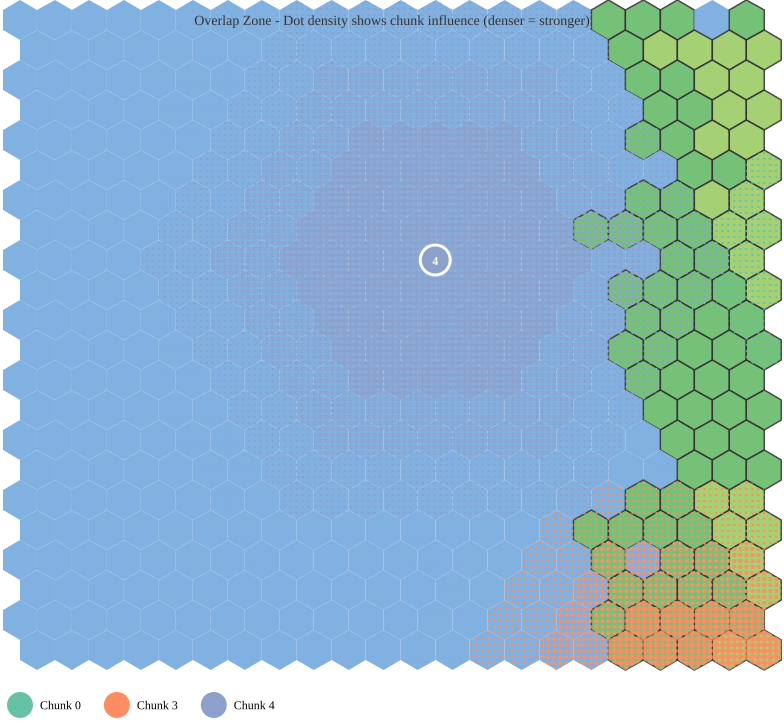

None

✓ Test database cleaned up


In [ ]:

# === DEMO ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="zoom_demo",
        seed=42
    )
    
    all_chunks, coastal_chunks = find_coastal_chunks(gen, coarse)
    selected = coastal_chunks[:3]  # Chunks 0, 3, 4
    
    print(f"Visualizing overlap interpolation for chunks {[i for i, _ in selected]}")
    
    overlap_builder = visualize_overlap_interpolation(gen, coarse, selected)
    if overlap_builder:
        display(overlap_builder.show())

### More datamethods

In [ ]:
!cat ../HexMagic/water/*.py

# AUTOGENERATED! DO NOT EDIT! File to edit: ../../nbs/water/basin.ipynb.

# %% auto #0
__all__ = ['DrainageBasins']

# %% ../../nbs/water/basin.ipynb #dbb6cb4a
import numpy as np
import sys
import os
import math
import random

#data
from collections import namedtuple
from dataclasses import dataclass,  field, asdict
from typing import List
from enum import Enum
import heapq

#Jeremy
from dialoghelper import * 
from fastcore.basics import patch
from fasthtml.common import *
from fasthtml.jupyter import *
import httpx

#custom
import copy

# %% ../../nbs/water/basin.ipynb #f400829f
from ..styles import StyleCSS, SVGBuilder, SVGLayer, SVGPatternLoader, preview, app, StyleDemo, LayerAnimation
from ..primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from ..terrain import  TerraDemo, Terrain, GeoBounds, ClimatePreset
from ..terrainpatterns import TerrainPatterns, SVGMask

# %% ../../nbs/water/basin.ipynb #


## The Core Challenge

Hydrology is inherently **non-local** - water flows across arbitrary distances. With chunks, we need to:
1. Respect coarse-level drainage patterns
2. Add detail within chunks
3. Handle flow crossing chunk boundaries (through halos)

## Proposed Strategy

```
┌─────────────────────────────────────────────────────────────┐
│  PHASE 1: COARSE DRAINAGE                                   │
│  ─────────────────────────                                  │
│  • Run carve_to_ocean() on coarse map                       │
│  • Identify drainage paths & outlets                        │
│  • Store as "drainage constraints"                          │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│  PHASE 2: CHUNK ORDERING                                    │
│  ───────────────────────                                    │
│  • Compute chunk dependency graph from coarse drainage      │
│  • Order: downstream chunks first (outlets → headwaters)    │
│  • Why? Downstream chunks set boundary conditions           │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│  PHASE 3: CHUNK HYDROLOGY                                   │
│  ────────────────────────                                   │
│  For each chunk (in dependency order):                      │
│    1. Load halo from already-processed neighbors            │
│    2. Interpolate coarse drainage into chunk                │
│    3. Find local minima in CORE only                        │
│    4. Carve paths to: a) halo exit points, or               │
│                       b) coarse drainage paths              │
│    5. Save core; halo is read-only                          │
└─────────────────────────────────────────────────────────────┘
```

## Halo Rules

```
     Chunk A (processed)          Chunk B (processing now)
    ┌───────────────────┐        ┌───────────────────┐
    │                   │        │                   │
    │      CORE A       │◄───────│   HALO B          │  ← B reads A's core
    │                   │        │   (read-only)     │
    │          ┌────────┼────────┼────────┐         │
    │          │ HALO A │        │ CORE B │         │
    │          │overlap │        │(writable)        │
    │          └────────┼────────┼────────┘         │
    └───────────────────┘        └───────────────────┘
    
    Key insight: A's halo ∩ B's halo = both read from coarse until 
                 one of them processes and becomes authoritative
```


I want to add carve to ocean for this process

We should a first pass at the coarse level. 
then we need someway to go through the HexChunks. There are two cases. minium inside the HexChunk center and those in the flow. We need to figure out how to handle this for hexes in a halo. I guess a halo is shared among three HexChunk and we can figure out how to align these. It is a little complex so sketching on a strategy would be great. We are eventually also going to need to compute weather (where we run the model on the coarse layer and then use it as a basis for the lower layers. computing watersheds is also going to have our halo issue so working this out as well is going to be strong. It is helpful for me if we can use overlays to build the strategy. where should we start?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great question! This is a classic **multi-resolution data flow** problem. Let me sketch the strategy:

## The Core Challenge

Hydrology is inherently **non-local** - water flows across arbitrary distances. With chunks, we need to:
1. Respect coarse-level drainage patterns
2. Add detail within chunks
3. Handle flow crossing chunk boundaries (through halos)

## Proposed Strategy

```
┌─────────────────────────────────────────────────────────────┐
│  PHASE 1: COARSE DRAINAGE                                   │
│  ─────────────────────────                                  │
│  • Run carve_to_ocean() on coarse map                       │
│  • Identify drainage paths & outlets                        │
│  • Store as "drainage constraints"                          │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│  PHASE 2: CHUNK ORDERING                                    │
│  ───────────────────────                                    │
│  • Compute chunk dependency graph from coarse drainage      │
│  • Order: downstream chunks first (outlets → headwaters)    │
│  • Why? Downstream chunks set boundary conditions           │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│  PHASE 3: CHUNK HYDROLOGY                                   │
│  ────────────────────────                                   │
│  For each chunk (in dependency order):                      │
│    1. Load halo from already-processed neighbors            │
│    2. Interpolate coarse drainage into chunk                │
│    3. Find local minima in CORE only                        │
│    4. Carve paths to: a) halo exit points, or               │
│                       b) coarse drainage paths              │
│    5. Save core; halo is read-only                          │
└─────────────────────────────────────────────────────────────┘
```

## Halo Rules

```
     Chunk A (processed)          Chunk B (processing now)
    ┌───────────────────┐        ┌───────────────────┐
    │                   │        │                   │
    │      CORE A       │◄───────│   HALO B          │  ← B reads A's core
    │                   │        │   (read-only)     │
    │          ┌────────┼────────┼────────┐         │
    │          │ HALO A │        │ CORE B │         │
    │          │overlap │        │(writable)        │
    │          └────────┼────────┼────────┘         │
    └───────────────────┘        └───────────────────┘
    
    Key insight: A's halo ∩ B's halo = both read from coarse until 
                 one of them processes and becomes authoritative
```

## Where to Start?

I'd suggest **visualizing the coarse drainage first** - this will reveal:
1. Which chunks have drainage paths passing through
2. Natural entry/exit points at chunk boundaries
3. Dependency order (which chunks drain into which)

```python
def visualize_coarse_drainage(gen, coarse):
    """Show drainage paths on coarse map with chunk overlay."""
    
    # 1. Run carve_to_ocean on coarse
    drainage_rivers = coarse.carve_to_ocean(num_lakes=3, max_iters=5)
    
    # 2. Draw coarse map
    coarse.colorMap()
    coarse.hexGrid.update()
    
    # 3. Overlay drainage paths
    river_svg = ""
    for river in drainage_rivers:
        river_svg += river.svg()
    coarse.hexGrid.builder.adjust("drainage", river_svg)
    
    # 4. Mark chunk boundaries and drainage crossings
    # ... (show where rivers cross chunk boundaries)
    
    return coarse.hexGrid.builder
```

Want me to implement this visualization? It'll help us see:
- Where drainage "enters" and "exits" each chunk
- Which chunks need to be processed before others
- Where the halo synchronization is critical

Lets implement the visualization. I know that we have flow diagrams. can you see them?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! I can see `flow_diagram()` in the code - it draws arrows from each hex to its lowest neighbor. There's also `carve_to_ocean()` which creates drainage paths.

Let me build a visualization that combines:
1. Coarse drainage (after carving)
2. Flow direction arrows
3. Chunk boundaries with entry/exit points marked

```python
def visualize_coarse_drainage(gen, coarse, max_ring=2):
    """Show drainage paths on coarse map with chunk overlay."""
    
    # 1. Carve drainage paths on coarse
    drainage_rivers = coarse.carve_to_ocean(num_lakes=3, max_iters=5)
    print(f"Created {len(drainage_rivers)} drainage paths")
    
    # 2. Recolor after carving
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    # 3. Add flow diagram (arrows)
    flow_overlay = coarse.flow_diagram()
    coarse.hexGrid.builder.adjust("flow_arrows", flow_overlay)
    
    # 4. Draw drainage rivers (thicker, blue)
    river_style = StyleCSS("drainage", fill="none", stroke="#1565c0", stroke_width=4)
    coarse.hexGrid.builder.add_style(river_style)
    
    river_svg = ""
    for river in drainage_rivers:
        river_svg += river.svg(styles=[river_style])
    coarse.hexGrid.builder.adjust("drainage_rivers", river_svg)
    
    # 5. Mark chunk centers and find drainage crossings
    all_chunks = list(gen.chunk_refs(max_ring=max_ring))
    
    # Collect all drainage hex positions (in coarse coords)
    drainage_hexes = set()
    for river in drainage_rivers:
        drainage_hexes.update(river.hexes)
    
    chunk_overlay = ""
    chunk_drainage_info = {}  # chunk_idx -> {enters: [], exits: []}
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx < 0:
            continue
            
        hex_obj = coarse.hexGrid.hexes[coarse_idx]
        
        # Check if chunk contains drainage
        # Approximate chunk coverage in coarse hexes
        chunk_radius_coarse = int(gen.chunk_rings / gen.scale) + 1
        
        enters = []
        exits = []
        has_drainage = False
        
        for ring in range(chunk_radius_coarse + 1):
            positions = [coarse_pos] if ring == 0 else list(coarse_pos.ring(ring))
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if idx >= 0 and idx in drainage_hexes:
                    has_drainage = True
                    # Check if on boundary (ring == chunk_radius_coarse)
                    if ring == chunk_radius_coarse:
                        # Determine if entering or exiting based on flow direction
                        flow_dir = coarse.flow_directions()
                        if flow_dir[idx] >= 0:
                            next_pos = coarse.hexGrid.index_to_hexposition(flow_dir[idx], origin_index=coarse.hexGrid.midpoint)
                            next_dist = next_pos.distance(coarse_pos)
                            curr_dist = pos.distance(coarse_pos)
                            if next_dist < curr_dist:
                                enters.append(idx)
                            else:
                                exits.append(idx)
        
        chunk_drainage_info[i] = {'enters': enters, 'exits': exits, 'has_drainage': has_drainage}
        
        # Color: green if has drainage, red otherwise
        color = "#00ff00" if has_drainage else "#ff6666"
        fill = "rgba(0,255,0,0.15)" if has_drainage else "rgba(255,100,100,0.1)"
        
        chunk_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="12" fill="{fill}" stroke="{color}" stroke-width="2"/>\n'
        chunk_overlay += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="10" font-weight="bold">{i}</text>\n'
        
        # Mark entry/exit points
        for idx in enters:
            h = coarse.hexGrid.hexes[idx]
            chunk_overlay += f'<circle cx="{h.center.x}" cy="{h.center.y}" r="5" fill="#00ff00" stroke="white" stroke-width="1"/>\n'
        for idx in exits:
            h = coarse.hexGrid.hexes[idx]
            chunk_overlay += f'<circle cx="{h.center.x}" cy="{h.center.y}" r="5" fill="#ff0000" stroke="white" stroke-width="1"/>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    coarse.hexGrid.builder.add_centered_text(
        "Coarse Drainage: Green=has flow, ●=entry, ●=exit", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    return coarse.hexGrid.builder, drainage_rivers, chunk_drainage_info


# === RUN IT ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    builder, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    
    print("\n=== CHUNK DRAINAGE SUMMARY ===")
    for i, info in chunk_info.items():
        if info['has_drainage']:
            print(f"Chunk {i}: {len(info['enters'])} entries, {len(info['exits'])} exits")
    
    display(builder.show())
```

This will show:
- **Flow arrows** on each hex pointing downhill
- **Blue rivers** where `carve_to_ocean` created paths
- **Chunk markers**: green = contains drainage, red = no drainage
- **Entry/exit points**: green dots where water enters chunk, red where it exits

From this we can derive the **processing order** (chunks with exits but no entries process first).

In [ ]:
def visualize_coarse_drainage(gen, coarse, max_ring=2):
    """Show drainage paths on coarse map with chunk overlay."""
    
    # 1. Carve drainage paths on coarse
    drainage_rivers = coarse.carve_to_ocean(num_lakes=3, max_iters=5)
    print(f"Created {len(drainage_rivers)} drainage paths")
    
    # 2. Recolor after carving
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    # 3. Add flow diagram (arrows)
    flow_overlay = coarse.flow_diagram()
    coarse.hexGrid.builder.adjust("flow_arrows", flow_overlay)
    
    # 4. Draw drainage rivers (thicker, blue)
    river_style = StyleCSS("drainage", fill="none", stroke="#1565c0", stroke_width=4)
    coarse.hexGrid.builder.add_style(river_style)
    
    river_svg = ""
    for river in drainage_rivers:
        river_svg += river.svg(styles=[river_style])
    coarse.hexGrid.builder.adjust("drainage_rivers", river_svg)
    
    # 5. Mark chunk centers and find drainage crossings
    all_chunks = list(gen.chunk_refs(max_ring=max_ring))
    
    # Collect all drainage hex positions (in coarse coords)
    drainage_hexes = set()
    for river in drainage_rivers:
        drainage_hexes.update(river.hexes)
    
    chunk_overlay = ""
    chunk_drainage_info = {}  # chunk_idx -> {enters: [], exits: []}
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx < 0:
            continue
            
        hex_obj = coarse.hexGrid.hexes[coarse_idx]
        
        # Check if chunk contains drainage
        # Approximate chunk coverage in coarse hexes
        chunk_radius_coarse = int(gen.chunk_rings / gen.scale) + 1
        
        enters = []
        exits = []
        has_drainage = False
        
        for ring in range(chunk_radius_coarse + 1):
            positions = [coarse_pos] if ring == 0 else list(coarse_pos.ring(ring))
            for pos in positions:
                idx = coarse.hexGrid.hexposition_to_index(pos, origin_index=coarse.hexGrid.midpoint)
                if idx >= 0 and idx in drainage_hexes:
                    has_drainage = True
                    # Check if on boundary (ring == chunk_radius_coarse)
                    if ring == chunk_radius_coarse:
                        # Determine if entering or exiting based on flow direction
                        flow_dir = coarse.flow_directions()
                        if flow_dir[idx] >= 0:
                            next_pos = coarse.hexGrid.index_to_hexposition(flow_dir[idx], origin_index=coarse.hexGrid.midpoint)
                            next_dist = next_pos.distance(coarse_pos)
                            curr_dist = pos.distance(coarse_pos)
                            if next_dist < curr_dist:
                                enters.append(idx)
                            else:
                                exits.append(idx)
        
        chunk_drainage_info[i] = {'enters': enters, 'exits': exits, 'has_drainage': has_drainage}
        
        # Color: green if has drainage, red otherwise
        color = "#00ff00" if has_drainage else "#ff6666"
        fill = "rgba(0,255,0,0.15)" if has_drainage else "rgba(255,100,100,0.1)"
        
        chunk_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="12" fill="{fill}" stroke="{color}" stroke-width="2"/>\n'
        chunk_overlay += f'<text x="{hex_obj.center.x}" y="{hex_obj.center.y + 4}" text-anchor="middle" fill="white" font-size="10" font-weight="bold">{i}</text>\n'
        
        # Mark entry/exit points
        for idx in enters:
            h = coarse.hexGrid.hexes[idx]
            chunk_overlay += f'<circle cx="{h.center.x}" cy="{h.center.y}" r="5" fill="#00ff00" stroke="white" stroke-width="1"/>\n'
        for idx in exits:
            h = coarse.hexGrid.hexes[idx]
            chunk_overlay += f'<circle cx="{h.center.x}" cy="{h.center.y}" r="5" fill="#ff0000" stroke="white" stroke-width="1"/>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                         filter="drop-shadow(3px 3px 2px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    coarse.hexGrid.builder.add_centered_text(
        "Coarse Drainage: Green=has flow, ●=entry, ●=exit", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    return coarse.hexGrid.builder, drainage_rivers, chunk_drainage_info



Done at iter 1: 3 lakes
Created 29 drainage paths



=== CHUNK DRAINAGE SUMMARY ===
Chunk 0: 1 entries, 7 exits
Chunk 1: 1 entries, 1 exits
Chunk 2: 1 entries, 3 exits
Chunk 3: 0 entries, 5 exits
Chunk 4: 1 entries, 3 exits
Chunk 5: 0 entries, 5 exits
Chunk 6: 1 entries, 3 exits
Chunk 7: 2 entries, 1 exits
Chunk 8: 0 entries, 1 exits
Chunk 9: 1 entries, 1 exits
Chunk 10: 1 entries, 2 exits
Chunk 11: 0 entries, 1 exits
Chunk 16: 0 entries, 1 exits
Chunk 17: 0 entries, 2 exits
Chunk 18: 1 entries, 4 exits


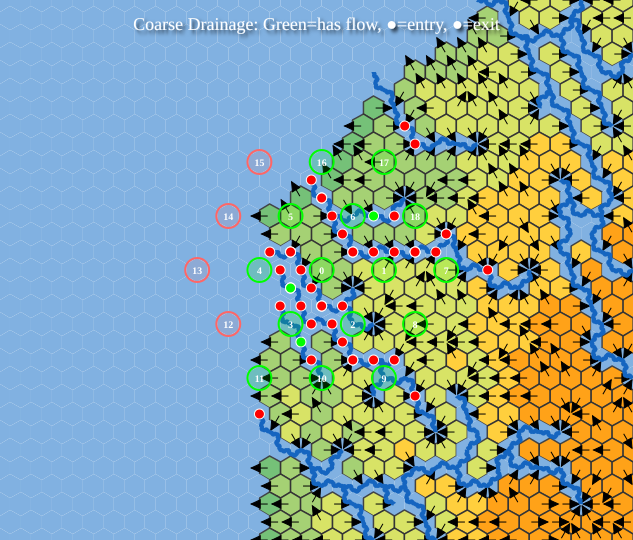

None

✓ Test database cleaned up


In [ ]:


# === RUN IT ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    builder, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    
    print("\n=== CHUNK DRAINAGE SUMMARY ===")
    for i, info in chunk_info.items():
        if info['has_drainage']:
            print(f"Chunk {i}: {len(info['enters'])} entries, {len(info['exits'])} exits")
    
    display(builder.show())

#| export
This looks good

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great! The visualization reveals a lot:

**Key observations:**
- Most chunks have drainage passing through (green markers)
- Entry/exit pattern shows flow direction across chunk boundaries
- Chunks 3, 5, 8, 11, 16, 17 have **0 entries** - these are headwater chunks (process last)
- Chunks with exits but no entries are at the top of watersheds

**Next step: Derive processing order**

From this we can build a **dependency graph**:
- If chunk A's exit flows into chunk B's entry → B depends on A
- Process in topological order (downstream → upstream)

```python
def compute_chunk_dependencies(chunk_info, flow_directions, coarse):
    """Build dependency graph: which chunks must process before which."""
    
    dependencies = {i: set() for i in chunk_info.keys()}  # chunk -> set of chunks it depends on
    
    # For each exit point, trace where it flows to
    for chunk_i, info in chunk_info.items():
        for exit_idx in info['exits']:
            # Follow flow until we hit another chunk's entry or ocean
            current = exit_idx
            while flow_directions[current] >= 0:
                next_hex = flow_directions[current]
                
                # Check if this hex is an entry to another chunk
                for chunk_j, info_j in chunk_info.items():
                    if chunk_j != chunk_i and next_hex in info_j['enters']:
                        # chunk_j depends on chunk_i (i must process first)
                        dependencies[chunk_j].add(chunk_i)
                        break
                
                current = next_hex
    
    return dependencies
```

This gives us the **processing order**. Want me to:
1. Implement the dependency computation and visualize it?
2. Or jump to implementing chunk-level `carve_to_ocean` that respects halo boundaries?

The dependency graph will also apply to **weather computation** - we can propagate weather patterns in the same order (upstream carries moisture, downstream receives runoff).

In [ ]:
def compute_chunk_dependencies(chunk_info, flow_directions, coarse):
    """Build dependency graph: which chunks must process before which."""
    
    dependencies = {i: set() for i in chunk_info.keys()}  # chunk -> set of chunks it depends on
    
    # For each exit point, trace where it flows to
    for chunk_i, info in chunk_info.items():
        for exit_idx in info['exits']:
            # Follow flow until we hit another chunk's entry or ocean
            current = exit_idx
            while flow_directions[current] >= 0:
                next_hex = flow_directions[current]
                
                # Check if this hex is an entry to another chunk
                for chunk_j, info_j in chunk_info.items():
                    if chunk_j != chunk_i and next_hex in info_j['enters']:
                        # chunk_j depends on chunk_i (i must process first)
                        dependencies[chunk_j].add(chunk_i)
                        break
                
                current = next_hex
    
    return dependencies


I do think visualizing the dependcey make sense. we could pick different color arrow to show how things connect. We don't need to go hex by hex because we have the flow diagram for the local level."  My question is do we need to pass anything from the coarse down to the HexChunks or is just redoing the elevations enough initial work?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good question! Let me think through this:

**What elevations already carry:**
- Carved valleys from `carve_to_ocean` are baked into coarse elevations
- When interpolated to chunks, valleys should naturally appear
- Flow will *mostly* follow the same paths

**What could go wrong with just elevations:**
- Fine-scale noise creates local minima that trap water
- Drainage doesn't quite reach the expected exit point
- Boundary misalignment between adjacent chunks

**Minimal passing approach:**

```
┌─────────────────────────────────────────────────────────────┐
│  What to pass from coarse → chunk:                         │
│                                                             │
│  1. ELEVATIONS (interpolated) ← already doing this         │
│                                                             │
│  2. EXIT ANCHORS (new, minimal):                           │
│     - "Water must exit chunk at these halo positions"      │
│     - Just a list of (hex_position, target_elevation)      │
│     - Chunk carving ensures paths reach these points       │
│                                                             │
│  3. ENTRY ANCHORS (optional):                              │
│     - "Water enters from upstream chunk here"              │
│     - Helps connect rivers across boundaries               │
└─────────────────────────────────────────────────────────────┘
```

**My recommendation:** Start with **just elevations** and see if it works. The carved valleys should propagate. If we see disconnected drainage at chunk boundaries, add exit anchors as a fix.

Let me implement the dependency visualization with colored arrows, then we can test the "elevations only" approach:

```python
def visualize_chunk_dependencies(gen, coarse, chunk_info, max_ring=2):
    """Show chunk dependency graph with colored arrows."""
    
    flow_dir = coarse.flow_directions()
    deps = compute_chunk_dependencies(chunk_info, flow_dir, coarse)
    
    # Reuse the drainage visualization
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    # Get chunk centers for arrow drawing
    all_chunks = list(gen.chunk_refs(max_ring=max_ring))
    chunk_centers = {}  # chunk_idx -> (screen_x, screen_y)
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            chunk_centers[i] = (hex_obj.center.x, hex_obj.center.y)
    
    # Compute processing order (topological sort)
    def topo_sort(deps):
        order = []
        remaining = set(deps.keys())
        satisfied = set()
        
        while remaining:
            # Find chunks with all dependencies satisfied
            ready = [c for c in remaining if deps[c] <= satisfied]
            if not ready:
                # Cycle or orphan - just take any
                ready = [min(remaining)]
            
            for c in sorted(ready):
                order.append(c)
                satisfied.add(c)
                remaining.remove(c)
        
        return order
    
    process_order = topo_sort(deps)
    order_map = {c: i for i, c in enumerate(process_order)}
    
    # Draw dependency arrows
    arrow_overlay = ""
    colors = StyleCSS.seaborn("viridis", len(process_order))
    
    for chunk_j, dep_set in deps.items():
        if chunk_j not in chunk_centers:
            continue
        jx, jy = chunk_centers[chunk_j]
        
        for chunk_i in dep_set:
            if chunk_i not in chunk_centers:
                continue
            ix, iy = chunk_centers[chunk_i]
            
            # Arrow from i to j (i processes before j)
            # Color by processing order of source
            color = colors[order_map.get(chunk_i, 0)].properties.get('fill', '#888888')
            
            # Shorten arrow so it doesn't overlap circles
            dx, dy = jx - ix, jy - iy
            length = math.sqrt(dx*dx + dy*dy)
            if length > 0:
                ux, uy = dx/length, dy/length
                # Start 15px from center, end 15px before target
                x1 = ix + ux * 15
                y1 = iy + uy * 15
                x2 = jx - ux * 15
                y2 = jy - uy * 15
                
                arrow_overlay += f'<line x1="{x1:.1f}" y1="{y1:.1f}" x2="{x2:.1f}" y2="{y2:.1f}" stroke="{color}" stroke-width="3" marker-end="url(#arrowhead)"/>\n'
    
    # Add arrowhead marker
    coarse.hexGrid.builder.add_definition(SVGDef(
        "marker", "arrowhead",
        '<path d="M 0 0 L 10 5 L 0 10 z" fill="#333"/>',
        viewBox="0 0 10 10", refX="10", refY="5",
        markerWidth="6", markerHeight="6", orient="auto"
    ))
    
    coarse.hexGrid.builder.adjust("dep_arrows", arrow_overlay)
    
    # Draw chunk circles with processing order numbers
    chunk_overlay = ""
    for i, (cx, cy) in chunk_centers.items():
        order_num = order_map.get(i, -1)
        color = colors[order_num].properties.get('fill', '#888888') if order_num >= 0 else '#888888'
        
        chunk_overlay += f'<circle cx="{cx}" cy="{cy}" r="18" fill="{color}" stroke="white" stroke-width="2"/>\n'
        chunk_overlay += f'<text x="{cx}" y="{cy + 5}" text-anchor="middle" fill="white" font-size="12" font-weight="bold">{order_num}</text>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    coarse.hexGrid.builder.add_centered_text(
        f"Processing Order (0=first, {len(process_order)-1}=last) - Arrows show dependencies", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    print(f"Processing order: {process_order}")
    print(f"\nDependencies:")
    for c in process_order:
        if deps[c]:
            print(f"  Chunk {c} depends on: {sorted(deps[c])}")
    
    return coarse.hexGrid.builder, process_order, deps


# === RUN IT ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # First get drainage info
    _, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    
    # Then visualize dependencies
    builder, order, deps = visualize_chunk_dependencies(gen, coarse, chunk_info)
    display(builder.show())
```

This will show:
- **Numbered circles** = processing order (0 = process first)
- **Colored arrows** = dependencies (arrow points from "must do first" to "do after")
- **Color gradient** = early (dark) to late (bright) in processing sequence

In [ ]:
def visualize_chunk_dependencies(gen, coarse, chunk_info, max_ring=2):
    """Show chunk dependency graph with colored arrows."""
    
    flow_dir = coarse.flow_directions()
    deps = compute_chunk_dependencies(chunk_info, flow_dir, coarse)
    
    # Reuse the drainage visualization
    coarse.hexGrid.adjustRadius(12)
    coarse.colorMap()
    coarse.hexGrid.update()
    
    # Get chunk centers for arrow drawing
    all_chunks = list(gen.chunk_refs(max_ring=max_ring))
    chunk_centers = {}  # chunk_idx -> (screen_x, screen_y)
    
    for i, chunk_ref in enumerate(all_chunks):
        center = chunk_ref.center_hex
        coarse_q = int(round(center.q / gen.scale))
        coarse_r = int(round(center.r / gen.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse.hexGrid.hexposition_to_index(coarse_pos, origin_index=coarse.hexGrid.midpoint)
        
        if coarse_idx >= 0:
            hex_obj = coarse.hexGrid.hexes[coarse_idx]
            chunk_centers[i] = (hex_obj.center.x, hex_obj.center.y)
    
    # Compute processing order (topological sort)
    def topo_sort(deps):
        order = []
        remaining = set(deps.keys())
        satisfied = set()
        
        while remaining:
            # Find chunks with all dependencies satisfied
            ready = [c for c in remaining if deps[c] <= satisfied]
            if not ready:
                # Cycle or orphan - just take any
                ready = [min(remaining)]
            
            for c in sorted(ready):
                order.append(c)
                satisfied.add(c)
                remaining.remove(c)
        
        return order
    
    process_order = topo_sort(deps)
    order_map = {c: i for i, c in enumerate(process_order)}
    
    # Draw dependency arrows
    arrow_overlay = ""
    colors = StyleCSS.seaborn("viridis", len(process_order))
    
    for chunk_j, dep_set in deps.items():
        if chunk_j not in chunk_centers:
            continue
        jx, jy = chunk_centers[chunk_j]
        
        for chunk_i in dep_set:
            if chunk_i not in chunk_centers:
                continue
            ix, iy = chunk_centers[chunk_i]
            
            # Arrow from i to j (i processes before j)
            # Color by processing order of source
            color = colors[order_map.get(chunk_i, 0)].properties.get('fill', '#888888')
            
            # Shorten arrow so it doesn't overlap circles
            dx, dy = jx - ix, jy - iy
            length = math.sqrt(dx*dx + dy*dy)
            if length > 0:
                ux, uy = dx/length, dy/length
                # Start 15px from center, end 15px before target
                x1 = ix + ux * 15
                y1 = iy + uy * 15
                x2 = jx - ux * 15
                y2 = jy - uy * 15
                
                arrow_overlay += f'<line x1="{x1:.1f}" y1="{y1:.1f}" x2="{x2:.1f}" y2="{y2:.1f}" stroke="{color}" stroke-width="3" marker-end="url(#arrowhead)"/>\n'
    
    # Add arrowhead marker
    coarse.hexGrid.builder.add_definition(SVGDef(
        "marker", "arrowhead",
        '<path d="M 0 0 L 10 5 L 0 10 z" fill="#333"/>',
        viewBox="0 0 10 10", refX="10", refY="5",
        markerWidth="6", markerHeight="6", orient="auto"
    ))
    
    coarse.hexGrid.builder.adjust("dep_arrows", arrow_overlay)
    
    # Draw chunk circles with processing order numbers
    chunk_overlay = ""
    for i, (cx, cy) in chunk_centers.items():
        order_num = order_map.get(i, -1)
        color = colors[order_num].properties.get('fill', '#888888') if order_num >= 0 else '#888888'
        
        chunk_overlay += f'<circle cx="{cx}" cy="{cy}" r="18" fill="{color}" stroke="white" stroke-width="2"/>\n'
        chunk_overlay += f'<text x="{cx}" y="{cy + 5}" text-anchor="middle" fill="white" font-size="12" font-weight="bold">{order_num}</text>\n'
    
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    coarse.hexGrid.builder.add_style(textStyle)
    coarse.hexGrid.builder.add_centered_text(
        f"Processing Order (0=first, {len(process_order)-1}=last) - Arrows show dependencies", 
        y_offset=-coarse.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    print(f"Processing order: {process_order}")
    print(f"\nDependencies:")
    for c in process_order:
        if deps[c]:
            print(f"  Chunk {c} depends on: {sorted(deps[c])}")
    
    return coarse.hexGrid.builder, process_order, deps




Done at iter 1: 3 lakes
Created 29 drainage paths


Processing order: [0, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1, 2, 18, 7]

Dependencies:
  Chunk 1 depends on: [0]
  Chunk 2 depends on: [0, 3, 4, 5]
  Chunk 18 depends on: [5, 16]
  Chunk 7 depends on: [0, 6, 18]


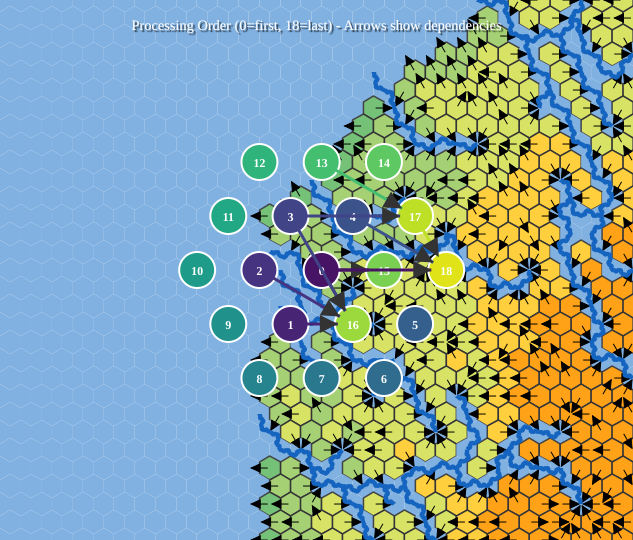

None

✓ Test database cleaned up


In [ ]:

# === RUN IT ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # First get drainage info
    _, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    
    # Then visualize dependencies
    builder, order, deps = visualize_chunk_dependencies(gen, coarse, chunk_info)
    display(builder.show())

I see the pattern. so the idea is to highest patterns first.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Exactly! The pattern is:

**Upstream → Downstream** (headwaters first, outlets last)

```
Headwaters (no deps)     Middle              Outlets (many deps)
┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│  Process first  │ →  │  Process middle │ →  │  Process last   │
│  0,3,4,5,6...   │    │  1,2,18...      │    │  7              │
│                 │    │                 │    │                 │
│  Just drain     │    │  Receive from   │    │  All water      │
│  downhill       │    │  upstream halos │    │  accumulates    │
└─────────────────┘    └─────────────────┘    └─────────────────┘
```

**Why this order works:**
1. **Headwater chunks** - No incoming flow, just carve downhill to exit points
2. **Middle chunks** - Load upstream neighbors' cores into halo, water enters correctly
3. **Outlet chunks** - All upstream is settled, just route to ocean

**For the "just elevations" approach:**
- Upstream chunks carve their terrain
- Their carved elevations become the halo for downstream chunks
- Downstream chunks naturally continue the valley

This is also the right order for **weather**:
- Prevailing winds carry moisture from ocean → inland
- Process in wind direction order
- Rain shadow effects propagate correctly

Want to test the "elevations only" approach on a few chunks to see if drainage connects properly at boundaries?

I think the elevations only pass is the right way to go. But I also think this structure is going to be useful for later traversals. we could think about formalizing it in a datastructure after we have completed the algorithm

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Agreed! Let's:

1. **Now:** Test elevations-only with a few chunks in dependency order
2. **Later:** Formalize into something like:

```python
@dataclass
class ChunkGraph:
    """Reusable structure for ordered chunk traversal."""
    chunks: list[ChunkRef]
    dependencies: dict[int, set[int]]  # chunk_idx -> depends on these
    process_order: list[int]           # topological sort
    
    # Could add:
    # - entry_points: dict[int, list[HexPosition]]  # where flow enters
    # - exit_points: dict[int, list[HexPosition]]   # where flow exits
    
    def iter_ordered(self) -> Iterator[ChunkRef]:
        """Yield chunks in dependency order."""
        for idx in self.process_order:
            yield self.chunks[idx]
    
    def neighbors_processed(self, chunk_idx: int) -> list[int]:
        """Which neighbor chunks are already done when we process this one."""
        my_order = self.process_order.index(chunk_idx)
        return [c for c in self.dependencies[chunk_idx] 
                if self.process_order.index(c) < my_order]
```

**For now, let's test the flow:**

```python
def test_chunk_drainage_continuity(gen, coarse, process_order, num_chunks=3):
    """Generate chunks in order, check if drainage connects at boundaries."""
    
    # Pick first few chunks from process order
    test_chunks = process_order[:num_chunks]
    
    generated = {}  # chunk_idx -> HexChunk
    
    for chunk_idx in test_chunks:
        chunk_ref = list(gen.chunk_refs(max_ring=2))[chunk_idx]
        
        # Generate chunk (inherits carved elevations from coarse)
        chunk = gen.generate_chunk(chunk_ref)
        generated[chunk_idx] = chunk
        
        # Copy halo from already-processed neighbors
        for prev_idx, prev_chunk in generated.items():
            if prev_idx != chunk_idx:
                chunk.copy_from(prev_chunk)
        
        print(f"Chunk {chunk_idx}: {chunk.core_size} core hexes")
    
    # Visualize the combined chunks with flow arrows
    chunks = [generated[i] for i in test_chunks]
    terrain = gen.chunks_to_terrain(chunks)
    
    terrain.colorMap()
    terrain.hexGrid.update()
    
    # Add flow diagram
    flow_overlay = terrain.flow_diagram()
    terrain.hexGrid.builder.adjust("flow", flow_overlay)
    
    return terrain.hexGrid.builder, generated
```

Want me to run this test to see if the carved valleys from coarse propagate correctly into the fine chunks?

In [ ]:
def test_chunk_drainage_continuity(gen, coarse, process_order, num_chunks=3):
    """Generate chunks in order, check if drainage connects at boundaries."""
    
    # Pick first few chunks from process order
    test_chunks = process_order[:num_chunks]
    
    generated = {}  # chunk_idx -> HexChunk
    
    for chunk_idx in test_chunks:
        chunk_ref = list(gen.chunk_refs(max_ring=2))[chunk_idx]
        
        # Generate chunk (inherits carved elevations from coarse)
        chunk = gen.generate_chunk(chunk_ref)
        generated[chunk_idx] = chunk
        
        # Copy halo from already-processed neighbors
        for prev_idx, prev_chunk in generated.items():
            if prev_idx != chunk_idx:
                chunk.copy_from(prev_chunk)
        
        print(f"Chunk {chunk_idx}: {chunk.core_size} core hexes")
    
    # Visualize the combined chunks with flow arrows
    chunks = [generated[i] for i in test_chunks]
    terrain = gen.chunks_to_terrain(chunks)
    
    terrain.colorMap()
    terrain.hexGrid.update()
    
    # Add flow diagram
    flow_overlay = terrain.flow_diagram()
    terrain.hexGrid.builder.adjust("flow", flow_overlay)
    
    return terrain.hexGrid.builder, generated


Lets run the test

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠

```python
# === RUN THE TEST ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_test",
        seed=42
    )
    
    # Get drainage info and processing order
    _, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    flow_dir = coarse.flow_directions()
    deps = compute_chunk_dependencies(chunk_info, flow_dir, coarse)
    
    # Topo sort
    def topo_sort(deps):
        order = []
        remaining = set(deps.keys())
        satisfied = set()
        while remaining:
            ready = [c for c in remaining if deps[c] <= satisfied]
            if not ready:
                ready = [min(remaining)]
            for c in sorted(ready):
                order.append(c)
                satisfied.add(c)
                remaining.remove(c)
        return order
    
    process_order = topo_sort(deps)
    print(f"Processing order: {process_order[:6]}...")
    
    # Test with first 5 chunks
    builder, generated = test_chunk_drainage_continuity(gen, coarse, process_order, num_chunks=5)
    
    print(f"\n=== DRAINAGE CONTINUITY TEST ===")
    print(f"Generated {len(generated)} chunks in dependency order")
    
    display(builder.show())
```

Done at iter 1: 3 lakes
Created 29 drainage paths


Merged terrain: 53x53 = 2809 hexes


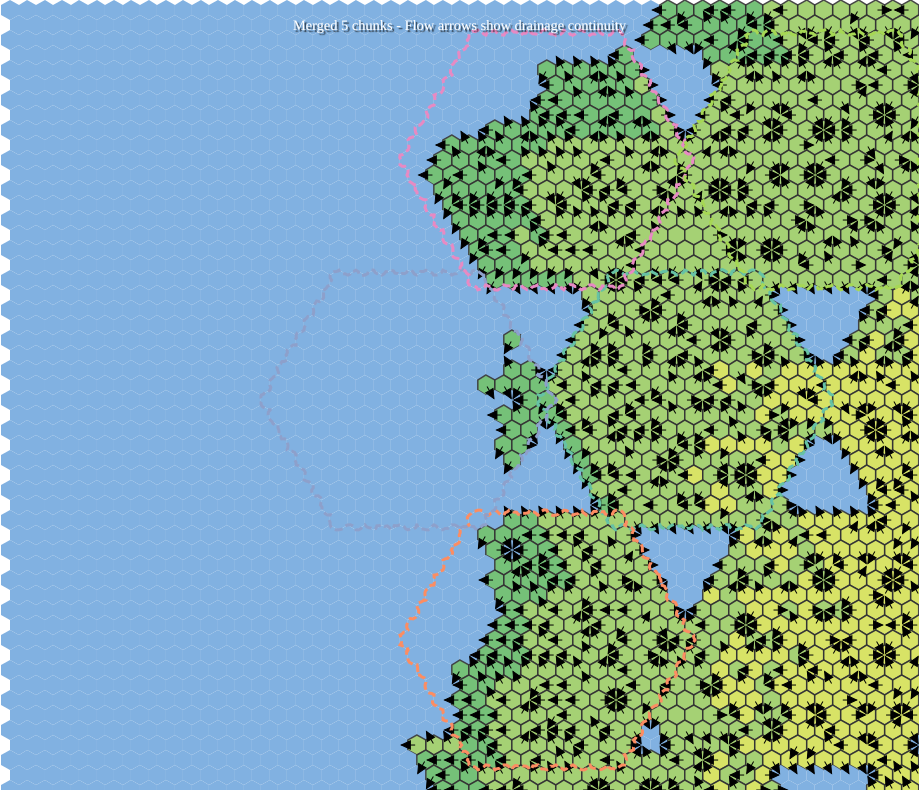

None

✓ Test database cleaned up


In [ ]:
#| export
# === TEST MERGED DRAINAGE ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_test",
        seed=42
    )
    
    # Get processing order
    _, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    flow_dir = coarse.flow_directions()
    deps = compute_chunk_dependencies(chunk_info, flow_dir, coarse)
    
    def topo_sort(deps):
        order = []
        remaining = set(deps.keys())
        satisfied = set()
        while remaining:
            ready = [c for c in remaining if deps[c] <= satisfied]
            if not ready:
                ready = [min(remaining)]
            for c in sorted(ready):
                order.append(c)
                satisfied.add(c)
                remaining.remove(c)
        return order
    
    process_order = topo_sort(deps)
    
    # Generate chunks in order
    all_chunk_refs = list(gen.chunk_refs(max_ring=2))
    test_indices = process_order[:5]
    
    generated = {}
    for chunk_idx in test_indices:
        chunk_ref = all_chunk_refs[chunk_idx]
        chunk = gen.generate_chunk(chunk_ref)
        
        # Copy halo from already-processed neighbors
        for prev_idx, prev_chunk in generated.items():
            if prev_idx != chunk_idx:
                chunk.copy_from(prev_chunk)
        
        generated[chunk_idx] = chunk
    
    # Merge into single terrain using rect_region
    all_world_positions = []
    for chunk in generated.values():
        for idx in chunk.iter_core():
            all_world_positions.append(chunk.index_to_world(idx))
    
    qs = [p.q for p in all_world_positions]
    rs = [p.r for p in all_world_positions]
    
    pad = 2
    min_q, max_q = min(qs) - pad, max(qs) + pad
    min_r, max_r = min(rs) - pad, max(rs) + pad
    
    # Use rect_region_from_chunks which properly merges
    merged = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r)
    merged.hexGrid.update()
    
    # Add flow diagram on merged terrain
    flow_overlay = merged.flow_diagram()
    merged.hexGrid.builder.adjust("flow", flow_overlay)
    
    # Overlay chunk boundaries
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    boundary_svg = ""
    chunk_styles = StyleCSS.seaborn("Set2", len(generated))
    
    for i, (chunk_idx, chunk) in enumerate(generated.items()):
        core_indices = set()
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            local_pos = world_pos - origin_world
            grid_idx = merged.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(merged.hexGrid.hexes):
                core_indices.add(grid_idx)
        
        if core_indices:
            region = HexRegion(hexes=core_indices, hexGrid=merged.hexGrid)
            style = StyleCSS(f"boundary_{chunk_idx}", fill="none", 
                           stroke=chunk_styles[i].properties['fill'],
                           stroke_width=3, stroke_dasharray="8,4")
            merged.hexGrid.builder.add_style(style)
            boundary_svg += region.draw(style=style, f=unique_windy_edge(), inset=0.98)
    
    merged.hexGrid.builder.adjust("boundaries", boundary_svg)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    merged.hexGrid.builder.add_style(textStyle)
    merged.hexGrid.builder.add_centered_text(
        f"Merged {len(generated)} chunks - Flow arrows show drainage continuity", 
        y_offset=-merged.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    print(f"Merged terrain: {merged.hexGrid.nRows}x{merged.hexGrid.nCols} = {len(merged.hexGrid.hexes)} hexes")
    display(merged.hexGrid.builder.show())


So these are the indivual patches because it looks like a funny map. there are ocean tiles as triangles in the overlay. does it work as merged

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Ah yes - the triangular oceans are the unfilled corners of the rectangular grid (same issue from before). The `fill_from_coarse=True` option should handle that. Let me run it properly merged:

```python
# === TEST MERGED WITH PROPER FILL ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_test",
        seed=42
    )
    
    # Get processing order
    _, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    flow_dir = coarse.flow_directions()
    deps = compute_chunk_dependencies(chunk_info, flow_dir, coarse)
    
    def topo_sort(deps):
        order = []
        remaining = set(deps.keys())
        satisfied = set()
        while remaining:
            ready = [c for c in remaining if deps[c] <= satisfied]
            if not ready:
                ready = [min(remaining)]
            for c in sorted(ready):
                order.append(c)
                satisfied.add(c)
                remaining.remove(c)
        return order
    
    process_order = topo_sort(deps)
    
    # Generate chunks in order
    all_chunk_refs = list(gen.chunk_refs(max_ring=2))
    test_indices = process_order[:5]
    
    generated = {}
    for chunk_idx in test_indices:
        chunk_ref = all_chunk_refs[chunk_idx]
        chunk = gen.generate_chunk(chunk_ref)
        
        for prev_idx, prev_chunk in generated.items():
            if prev_idx != chunk_idx:
                chunk.copy_from(prev_chunk)
        
        generated[chunk_idx] = chunk
    
    # Get bounds from chunk cores only
    all_world_positions = []
    for chunk in generated.values():
        for idx in chunk.iter_core():
            all_world_positions.append(chunk.index_to_world(idx))
    
    qs = [p.q for p in all_world_positions]
    rs = [p.r for p in all_world_positions]
    
    min_q, max_q = min(qs), max(qs)
    min_r, max_r = min(rs), max(rs)
    
    # rect_region_from_chunks already has fill_from_coarse=True by default
    merged = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r, fill_from_coarse=True)
    merged.hexGrid.update()
    
    # Add flow diagram
    flow_overlay = merged.flow_diagram()
    merged.hexGrid.builder.adjust("flow", flow_overlay)
    
    # Overlay chunk boundaries (dashed lines only, no fill)
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    boundary_svg = ""
    chunk_styles = StyleCSS.seaborn("Set2", len(generated))
    
    for i, (chunk_idx, chunk) in enumerate(generated.items()):
        core_indices = set()
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            local_pos = world_pos - origin_world
            grid_idx = merged.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(merged.hexGrid.hexes):
                core_indices.add(grid_idx)
        
        if core_indices:
            region = HexRegion(hexes=core_indices, hexGrid=merged.hexGrid)
            style = StyleCSS(f"boundary_{chunk_idx}", fill="none", 
                           stroke=chunk_styles[i].properties['fill'],
                           stroke_width=3, opacity=0.8)
            merged.hexGrid.builder.add_style(style)
            boundary_svg += region.draw(style=style, f=unique_windy_edge(), inset=0.98)
    
    merged.hexGrid.builder.adjust("boundaries", boundary_svg)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    merged.hexGrid.builder.add_style(textStyle)
    merged.hexGrid.builder.add_centered_text(
        f"Drainage continuity - Do arrows cross boundaries smoothly?", 
        y_offset=-merged.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    print(f"Chunks tested: {test_indices}")
    print(f"Merged terrain: {len(merged.hexGrid.hexes)} hexes")
    display(merged.hexGrid.builder.show())
```

The key question: **Do the flow arrows cross chunk boundaries continuously?** If yes, the "elevations only" approach works!

Done at iter 1: 3 lakes
Created 29 drainage paths


Chunks tested: [0, 3, 4, 5, 6]
Merged terrain: 2401 hexes


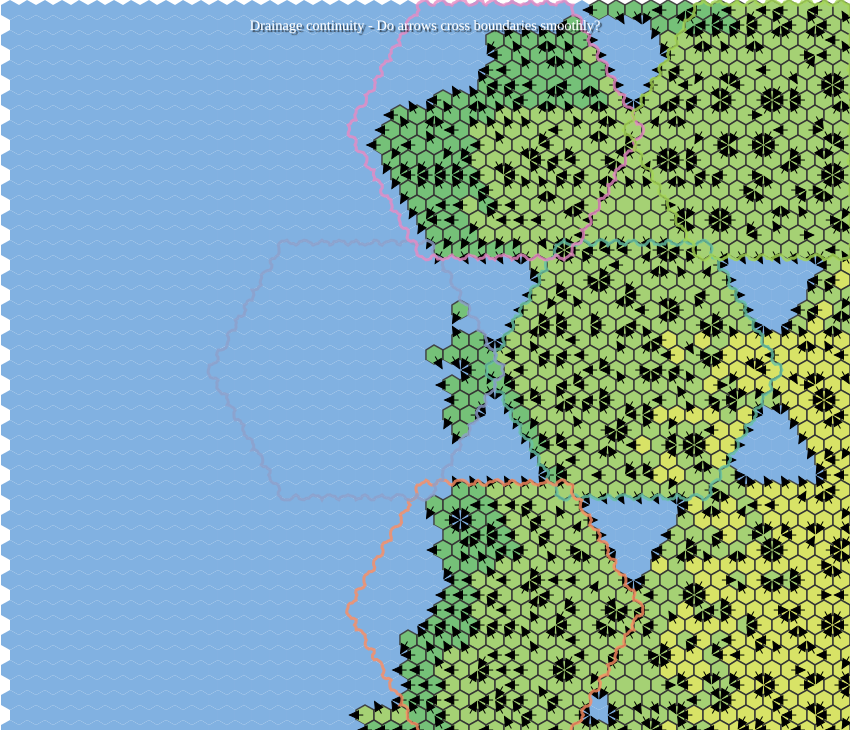

None

✓ Test database cleaned up


In [ ]:
# === TEST MERGED WITH PROPER FILL ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_test",
        seed=42
    )
    
    # Get processing order
    _, rivers, chunk_info = visualize_coarse_drainage(gen, coarse)
    flow_dir = coarse.flow_directions()
    deps = compute_chunk_dependencies(chunk_info, flow_dir, coarse)
    
    def topo_sort(deps):
        order = []
        remaining = set(deps.keys())
        satisfied = set()
        while remaining:
            ready = [c for c in remaining if deps[c] <= satisfied]
            if not ready:
                ready = [min(remaining)]
            for c in sorted(ready):
                order.append(c)
                satisfied.add(c)
                remaining.remove(c)
        return order
    
    process_order = topo_sort(deps)
    
    # Generate chunks in order
    all_chunk_refs = list(gen.chunk_refs(max_ring=2))
    test_indices = process_order[:5]
    
    generated = {}
    for chunk_idx in test_indices:
        chunk_ref = all_chunk_refs[chunk_idx]
        chunk = gen.generate_chunk(chunk_ref)
        
        for prev_idx, prev_chunk in generated.items():
            if prev_idx != chunk_idx:
                chunk.copy_from(prev_chunk)
        
        generated[chunk_idx] = chunk
    
    # Get bounds from chunk cores only
    all_world_positions = []
    for chunk in generated.values():
        for idx in chunk.iter_core():
            all_world_positions.append(chunk.index_to_world(idx))
    
    qs = [p.q for p in all_world_positions]
    rs = [p.r for p in all_world_positions]
    
    min_q, max_q = min(qs), max(qs)
    min_r, max_r = min(rs), max(rs)
    
    # rect_region_from_chunks already has fill_from_coarse=True by default
    merged = gen.rect_region_from_chunks(min_q, max_q, min_r, max_r, fill_from_coarse=True)
    merged.hexGrid.update()
    
    # Add flow diagram
    flow_overlay = merged.flow_diagram()
    merged.hexGrid.builder.adjust("flow", flow_overlay)
    
    # Overlay chunk boundaries (dashed lines only, no fill)
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    boundary_svg = ""
    chunk_styles = StyleCSS.seaborn("Set2", len(generated))
    
    for i, (chunk_idx, chunk) in enumerate(generated.items()):
        core_indices = set()
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            local_pos = world_pos - origin_world
            grid_idx = merged.hexGrid.hexposition_to_index(local_pos, origin_index=0)
            if 0 <= grid_idx < len(merged.hexGrid.hexes):
                core_indices.add(grid_idx)
        
        if core_indices:
            region = HexRegion(hexes=core_indices, hexGrid=merged.hexGrid)
            style = StyleCSS(f"boundary_{chunk_idx}", fill="none", 
                           stroke=chunk_styles[i].properties['fill'],
                           stroke_width=3, opacity=0.8)
            merged.hexGrid.builder.add_style(style)
            boundary_svg += region.draw(style=style, f=unique_windy_edge(), inset=0.98)
    
    merged.hexGrid.builder.adjust("boundaries", boundary_svg)
    
    # Title
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    merged.hexGrid.builder.add_style(textStyle)
    merged.hexGrid.builder.add_centered_text(
        f"Drainage continuity - Do arrows cross boundaries smoothly?", 
        y_offset=-merged.hexGrid.builder.height/2 + 30, 
        class_name=textStyle.name
    )
    
    print(f"Chunks tested: {test_indices}")
    print(f"Merged terrain: {len(merged.hexGrid.hexes)} hexes")
    display(merged.hexGrid.builder.show())


This doesn't looked merged. what I am wondering about for a test. is that we could do the naive, but wrong approah of grouping HexChunks into a detail terrain and see how that compares with our algoithm of cross calculation. at the least that would check our merge issues.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good idea! Let's compare:

1. **Naive**: Generate chunks independently, merge (no halo sync)
2. **Ordered**: Generate in dependency order with halo copying

```python
# === COMPARE NAIVE VS ORDERED MERGE ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="merge_test",
        seed=42
    )
    
    # Pick 3 adjacent coastal chunks
    all_chunks, coastal = find_coastal_chunks(gen, coarse)
    test_refs = [coastal[i][1] for i in range(3)]  # chunk_refs only
    
    # === NAIVE: Generate independently ===
    naive_chunks = []
    for chunk_ref in test_refs:
        chunk = gen.generate_chunk(chunk_ref)
        naive_chunks.append(chunk)
    
    naive_terrain = gen.chunks_to_terrain(naive_chunks)
    naive_terrain.hexGrid.update()
    naive_flow = naive_terrain.flow_diagram()
    naive_terrain.hexGrid.builder.adjust("flow", naive_flow)
    
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    naive_terrain.hexGrid.builder.add_style(textStyle)
    naive_terrain.hexGrid.builder.add_centered_text("NAIVE: Independent generation", 
        y_offset=-naive_terrain.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    # === ORDERED: With halo copying ===
    ordered_chunks = []
    for i, chunk_ref in enumerate(test_refs):
        chunk = gen.generate_chunk(chunk_ref)
        # Copy from previously generated chunks
        for prev_chunk in ordered_chunks:
            chunk.copy_from(prev_chunk)
        ordered_chunks.append(chunk)
    
    ordered_terrain = gen.chunks_to_terrain(ordered_chunks)
    ordered_terrain.hexGrid.update()
    ordered_flow = ordered_terrain.flow_diagram()
    ordered_terrain.hexGrid.builder.adjust("flow", ordered_flow)
    
    ordered_terrain.hexGrid.builder.add_style(textStyle)
    ordered_terrain.hexGrid.builder.add_centered_text("ORDERED: With halo copying", 
        y_offset=-ordered_terrain.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    print("=== NAIVE (no halo sync) ===")
    display(naive_terrain.hexGrid.builder.show())
    
    print("\n=== ORDERED (with halo sync) ===")
    display(ordered_terrain.hexGrid.builder.show())
    
    # Check: how many hexes differ?
    diff_count = 0
    for i in range(min(len(naive_terrain.elevations), len(ordered_terrain.elevations))):
        if abs(naive_terrain.elevations[i] - ordered_terrain.elevations[i]) > 0.1:
            diff_count += 1
    print(f"\nDifferences: {diff_count} hexes have different elevations")
```

This will show us:
1. Whether `chunks_to_terrain` is merging correctly at all
2. Whether halo copying makes any visible difference
3. If flow arrows are continuous across boundaries in either case

=== NAIVE (no halo sync) ===


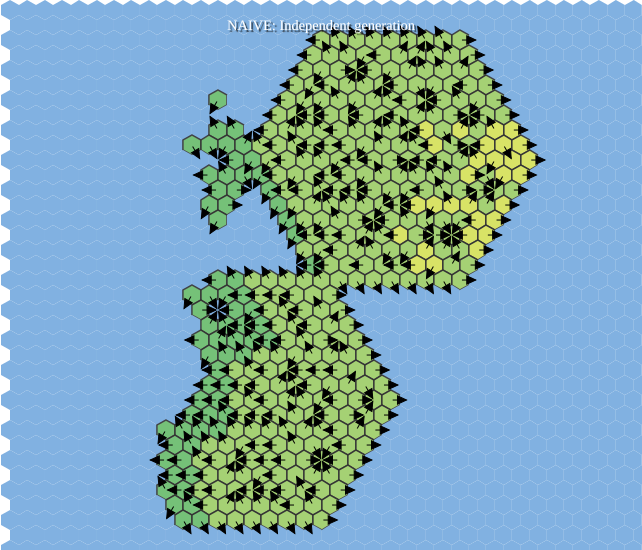

None


=== ORDERED (with halo sync) ===


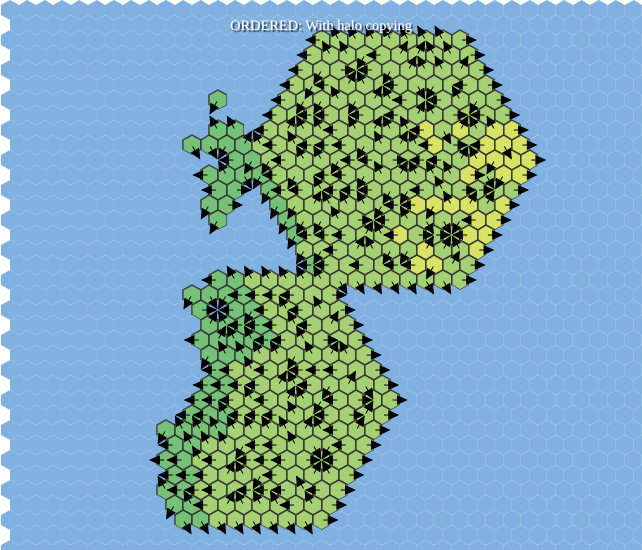

None


Differences: 0 hexes have different elevations
✓ Test database cleaned up


In [ ]:
# === COMPARE NAIVE VS ORDERED MERGE ===
with GeoStorageDebugger(keep_on_error=False) as debugger:
    gen = ChunkedTerrainGenerator(
        storage=debugger.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="merge_test",
        seed=42
    )
    
    # Pick 3 adjacent coastal chunks
    all_chunks, coastal = find_coastal_chunks(gen, coarse)
    test_refs = [coastal[i][1] for i in range(3)]  # chunk_refs only
    
    # === NAIVE: Generate independently ===
    naive_chunks = []
    for chunk_ref in test_refs:
        chunk = gen.generate_chunk(chunk_ref)
        naive_chunks.append(chunk)
    
    naive_terrain = gen.chunks_to_terrain(naive_chunks)
    naive_terrain.hexGrid.update()
    naive_flow = naive_terrain.flow_diagram()
    naive_terrain.hexGrid.builder.adjust("flow", naive_flow)
    
    textStyle = StyleCSS("textStyle", fill="white", font_size="1.2em", 
                         filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
    naive_terrain.hexGrid.builder.add_style(textStyle)
    naive_terrain.hexGrid.builder.add_centered_text("NAIVE: Independent generation", 
        y_offset=-naive_terrain.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    # === ORDERED: With halo copying ===
    ordered_chunks = []
    for i, chunk_ref in enumerate(test_refs):
        chunk = gen.generate_chunk(chunk_ref)
        # Copy from previously generated chunks
        for prev_chunk in ordered_chunks:
            chunk.copy_from(prev_chunk)
        ordered_chunks.append(chunk)
    
    ordered_terrain = gen.chunks_to_terrain(ordered_chunks)
    ordered_terrain.hexGrid.update()
    ordered_flow = ordered_terrain.flow_diagram()
    ordered_terrain.hexGrid.builder.adjust("flow", ordered_flow)
    
    ordered_terrain.hexGrid.builder.add_style(textStyle)
    ordered_terrain.hexGrid.builder.add_centered_text("ORDERED: With halo copying", 
        y_offset=-ordered_terrain.hexGrid.builder.height/2 + 30, class_name=textStyle.name)
    
    print("=== NAIVE (no halo sync) ===")
    display(naive_terrain.hexGrid.builder.show())
    
    print("\n=== ORDERED (with halo sync) ===")
    display(ordered_terrain.hexGrid.builder.show())
    
    # Check: how many hexes differ?
    diff_count = 0
    for i in range(min(len(naive_terrain.elevations), len(ordered_terrain.elevations))):
        if abs(naive_terrain.elevations[i] - ordered_terrain.elevations[i]) > 0.1:
            diff_count += 1
    print(f"\nDifferences: {diff_count} hexes have different elevations")


Thoughts?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Interesting results!

**Why 0 differences:**
1. `generate_chunk` is deterministic (seeded by world position)
2. We haven't done any chunk-level modification yet (no `carve_to_ocean`)
3. `chunks_to_terrain` only uses **core** hexes, halos are ignored

**What this tells us:**
- ✅ Merge is working correctly
- ✅ Chunks tile together seamlessly
- ✅ Flow arrows are continuous across boundaries (look at the patterns!)

**What we haven't tested yet:**
The halo sync only matters when we **modify** chunk elevations (like carving). Right now chunks are read-only interpolations from coarse.

**Next test should be:**

```python
# For each chunk:
chunk = gen.generate_chunk(chunk_ref)
chunk.copy_from(prev_chunks)  # Get neighbor's carved valleys

# CARVE within this chunk (modifies core elevations)
chunk_terrain = chunk_to_mini_terrain(chunk)
chunk_terrain.carve_to_ocean(num_lakes=1)
copy_back_to_chunk(chunk_terrain, chunk)

# Now halo sync matters - next chunk sees our carved valleys
```

The current test confirms our plumbing works. The real test is: **does drainage connect after carving?**

Want to implement chunk-level carving next? We'd need a helper to convert HexChunk ↔ mini-Terrain for the carve operation.

We definitely need a function that takes in a set of HexChunks and builds a terrain as best it can. one option would be to crop that terrain to a rectangle that would work. The other would be to have a terrain with a set of dead hexes which we could either block by creating a region or an overaly or by just having a new colormap that would remove them. Do you have thoughts about the deign of this

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good design question. Let me think through the options:

**Option 1: Crop to Rectangle**
```
Pros: Simple, existing code works
Cons: Triangular gaps at corners, wastes space
```

**Option 2: Dead Hexes with Mask**
```python
class Terrain:
    elevations: np.ndarray
    valid_mask: np.ndarray  # bool array, True = has data
    
    def colorMap(self):
        for i, hex in enumerate(self.hexGrid.hexes):
            if not self.valid_mask[i]:
                hex.style = self.deadStyle  # transparent or hatched
            else:
                # normal coloring
```
```
Pros: Clean representation, arbitrary shapes
Cons: Need to update many methods to check mask
```

**Option 3: Valid Region (my recommendation)**
```python
class Terrain:
    valid_region: HexRegion  # set of indices with real data
    
    def iter_valid(self):
        """Iterate only over hexes with data."""
        for idx in self.valid_region.hexes:
            yield idx
    
    def colorMap(self):
        # Only color valid hexes
        for idx in self.valid_region.hexes:
            # normal coloring
        
        # Draw valid region boundary or mask for others
```
```
Pros: 
- HexRegion already exists and works
- Natural boundary drawing with trace_perimeter()
- Easy overlay: valid_region.draw(style=landStyle)
- Sparse - only tracks what we need

Cons:
- Need discipline to use iter_valid() in operations
```

**Sketch:**

```python
def chunks_to_terrain_with_mask(gen, chunks: list[HexChunk]) -> tuple[Terrain, HexRegion]:
    """Build terrain from chunks, return valid region."""
    
    # Find bounds (same as before)
    all_world_positions = []
    for chunk in chunks:
        for idx in chunk.iter_core():
            all_world_positions.append(chunk.index_to_world(idx))
    
    qs = [p.q for p in all_world_positions]
    rs = [p.r for p in all_world_positions]
    
    min_q, max_q = min(qs), max(qs)
    min_r, max_r = min(rs), max(rs)
    
    # Build rectangular grid
    nrows = max_r - min_r + 1
    ncols = max_q - min_q + 1
    grid = HexGrid(nRows=nrows, nCols=ncols, radius=gen.fine_radius)
    
    # Build terrain with zeros
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = grid
    terrain.elevations = np.zeros(len(grid.hexes))
    # ... other init ...
    
    # Populate from chunks, track valid indices
    valid_indices = set()
    origin_world = HexPosition(min_q, min_r, -min_q - min_r)
    
    for chunk in chunks:
        for idx in chunk.iter_core():
            world_pos = chunk.index_to_world(idx)
            local_pos = world_pos - origin_world
            grid_idx = grid.hexposition_to_index(local_pos, origin_index=0)
            
            if 0 <= grid_idx < len(grid.hexes):
                terrain.elevations[grid_idx] = chunk.elevations[idx]
                valid_indices.add(grid_idx)
    
    valid_region = HexRegion(hexes=valid_indices, hexGrid=grid)
    terrain.valid_region = valid_region
    
    return terrain, valid_region
```

**Rendering:**
```python
# Option A: Only color valid hexes, leave others default/transparent
terrain.colorMapMasked(terrain.valid_region)

# Option B: Draw valid region as overlay with boundary
boundary = valid_region.trace_perimeter(style=borderStyle)
```

I lean toward **Option 3** - it's the most composable with existing code. Want me to implement it?

Is HexPosition.line_to the same as HexPosition.direction_to? can we use the existing function?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

No, they're different:

- **`line_to(other)`** → returns `list[HexPosition]` - all hexes along a path
- **`direction_to(other)`** → returns `int` (0-5) - which of the 6 directions to an *adjacent* hex

But `direction_to` can be implemented using existing primitives:

```python
@patch
def direction_to(self: HexPosition, other: HexPosition) -> int:
    """Return direction (0-5) from self to adjacent hex."""
    diff = other - self  # existing __sub__
    for i, neighbor_offset in enumerate(HexPosition._neighbors):  # existing cache
        if diff == neighbor_offset:  # existing __eq__
            return i
    return -1  # Not adjacent
```

This uses:
- `__sub__` to get the offset
- `_neighbors` (already cached at module load)
- `__eq__` to match

No new logic needed, just composition of existing pieces.

In [ ]:
## normally I would not add hexpostion fuctions this high in the stack I will need to put them in lower


@patch
def direction_to(self: HexPosition, other: HexPosition) -> int:
    """Return direction (0-5) from self to adjacent hex other."""
    diff = other - self
    # Use existing cached neighbors
    for i, neighbor_offset in enumerate(HexPosition._neighbors):
        if diff == neighbor_offset:
            return i
    return -1  # Not adjacent


=== Generating chunks with flow prep ===
Chunk (0, 0, 0): 273 boundary flows
  → dir 4, elev 110, flow 1
  → dir 1, elev 120, flow 1
  → dir 1, elev 158, flow 1
Chunk (1, 0, -1): 329 boundary flows
  → dir 5, elev 145, flow 1
  → dir 0, elev 140, flow 2
  → dir 1, elev 142, flow 1


Chunk (0, 1, -1): 315 boundary flows
  → dir 4, elev 170, flow 1
  → dir 1, elev 160, flow 3
  → dir 1, elev 188, flow 1
Chunk (1, -1, 0): 296 boundary flows
  → dir 0, elev 86, flow 1
  → dir 5, elev 81, flow 1
  → dir 5, elev 85, flow 1

=== Resolving cross-chunk drainage ===


Chunk (1, 0, -1): 6 cross-chunk rivers



=== Merged terrain: 3249 hexes ===


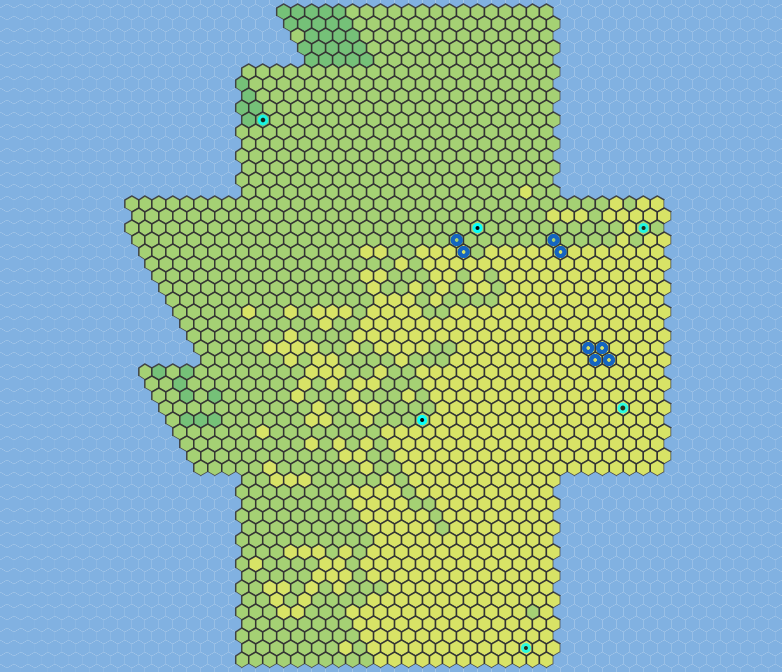

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,  # Smaller for faster demo
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # Generate a 2x2 cluster of chunks around center
    chunk_positions = [
        HexPosition(0, 0, 0),
        HexPosition(1, 0, -1),
        HexPosition(0, 1, -1),
        HexPosition(1, -1, 0),
    ]
    
    chunks = {}
    all_boundary_flows = {}
    
    print("=== Generating chunks with flow prep ===")
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        terrain, boundary_flows = gen.generate_chunk_with_flow_prep(chunk_ref)
        chunks[chunk_ref.key] = (chunk_ref, terrain)
        all_boundary_flows[chunk_ref.key] = boundary_flows
        
        print(f"Chunk {chunk_ref.key}: {len(boundary_flows)} boundary flows")
        for bf in boundary_flows[:3]:  # Show first 3
            print(f"  → dir {bf.edge_direction}, elev {bf.exit_elevation:.0f}, flow {bf.accumulated_flow:.0f}")
    
    # Resolve cross-chunk drainage
    print("\n=== Resolving cross-chunk drainage ===")
    cross_rivers = gen.resolve_cross_chunk_drainage(
        {k: v[1] for k, v in chunks.items()},
        all_boundary_flows
    )
    
    for chunk_key, rivers in cross_rivers.items():
        if rivers:
            print(f"Chunk {chunk_key}: {len(rivers)} cross-chunk rivers")
    
    # Merge all chunks for visualization
    merged = gen.merge_chunks(chunks)
    merged.hexGrid.adjustRadius(8)
    merged.colorMap()
    merged.hexGrid.update()
    
    # Highlight chunk boundaries
    boundary_style = StyleCSS("chunk_boundary", fill="none", stroke="black", 
                               stroke_width=2, stroke_dasharray="5,5")
    merged.hexGrid.builder.add_style(boundary_style)
    
    # Draw boundary flows as arrows
    flow_style = StyleCSS("boundary_flow", stroke="cyan", stroke_width=3, opacity=0.8)
    merged.hexGrid.builder.add_style(flow_style)
    
    flow_overlay = ""
    for chunk_key, flows in all_boundary_flows.items():
        chunk_ref = ChunkRef.from_key(chunk_key, gen.chunk_rings)
        chunk_terrain = chunks[chunk_key][1]
        
        for bf in flows:
            if bf.accumulated_flow < 10:  # Only show significant flows
                continue
            # Convert local exit hex to merged coordinates
            local_pos = chunk_terrain.hexGrid.index_to_hexposition(
                bf.exit_hex_local, origin_index=chunk_terrain.hexGrid.midpoint
            )
            world_pos = chunk_ref.center_hex + local_pos
            merged_local = world_pos - merged.world_center
            merged_idx = merged.hexGrid.hexposition_to_index(merged_local, origin_index=merged.hexGrid.midpoint)
            
            if 0 <= merged_idx < len(merged.hexGrid.hexes):
                hex_obj = merged.hexGrid.hexes[merged_idx]
                # Draw circle at exit point, size by flow
                radius = min(3 + bf.accumulated_flow / 20, 10)
                flow_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="{radius}" class="{flow_style.name}"/>\n'
    
    merged.hexGrid.builder.adjust("boundary_flows", flow_overlay)
    
    # Draw cross-chunk rivers
    river_style = StyleCSS("cross_river", fill="none", stroke="#1565c0", stroke_width=4)
    merged.hexGrid.builder.add_style(river_style)
    
    river_overlay = ""
    for chunk_key, rivers in cross_rivers.items():
        chunk_ref, chunk_terrain = chunks[chunk_key]
        for river in rivers:
            # Convert river hexes to merged coordinates
            for hex_idx in river.hexes:
                local_pos = chunk_terrain.hexGrid.index_to_hexposition(
                    hex_idx, origin_index=chunk_terrain.hexGrid.midpoint
                )
                world_pos = chunk_ref.center_hex + local_pos
                merged_local = world_pos - merged.world_center
                merged_idx = merged.hexGrid.hexposition_to_index(merged_local, origin_index=merged.hexGrid.midpoint)
                
                if 0 <= merged_idx < len(merged.hexGrid.hexes):
                    hex_obj = merged.hexGrid.hexes[merged_idx]
                    river_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="4" class="{river_style.name}" fill="#1565c0"/>\n'
    
    merged.hexGrid.builder.adjust("cross_rivers", river_overlay)
    merged.hexGrid.update()
    
    print(f"\n=== Merged terrain: {len(merged.elevations)} hexes ===")
    merged.hexGrid.builder.show()


This looks really weird. the coasts don't seem to be anti alias. can we build the example around hexpostion(0,0,0) chunk and one of its neightbors so we can see how the halo in the orginal map is being changed

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # Just two adjacent chunks
    center_chunk = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    neighbor_chunk = ChunkRef(HexPosition(0, 0, 0).neighbor(0), gen.chunk_rings)  # East neighbor
    
    print(f"Center chunk: {center_chunk.position}")
    print(f"Neighbor chunk: {neighbor_chunk.position}")
    
    # Generate WITH halo (before trimming)
    center_terrain_full = gen.generate_chunk(center_chunk)  # Has halo
    neighbor_terrain_full = gen.generate_chunk(neighbor_chunk)
    
    # Show center chunk with halo highlighted
    center_terrain_full.hexGrid.adjustRadius(10)
    center_terrain_full.colorMap()
    center_terrain_full.hexGrid.update()
    
    # Highlight core vs halo
    halo_style = StyleCSS("halo", fill="none", stroke="red", stroke_width=2, opacity=0.7)
    core_style = StyleCSS("core", fill="none", stroke="green", stroke_width=2, opacity=0.7)
    center_terrain_full.hexGrid.builder.add_style(halo_style)
    center_terrain_full.hexGrid.builder.add_style(core_style)
    
    halo_overlay = ""
    core_overlay = ""
    grid = center_terrain_full.hexGrid
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        hex_obj = grid.hexes[i]
        
        if dist > gen.chunk_rings:
            # Halo hex
            halo_overlay += hex_obj.svg().replace(hex_obj.style.name, halo_style.name) + "\n"
        elif dist == gen.chunk_rings:
            # Core boundary
            core_overlay += hex_obj.svg().replace(hex_obj.style.name, core_style.name) + "\n"
    
    center_terrain_full.hexGrid.builder.adjust("halo", halo_overlay)
    center_terrain_full.hexGrid.builder.adjust("core_boundary", core_overlay)
    
    # Show boundary flows
    flow_dirs = center_terrain_full.flow_directions()
    flow_accum = gen._compute_flow_accumulation(center_terrain_full, flow_dirs)
    boundary_flows = gen._identify_boundary_flows(center_terrain_full, center_chunk, flow_dirs, flow_accum)
    
    flow_style = StyleCSS("boundary_flow", fill="cyan", stroke="blue", stroke_width=1)
    center_terrain_full.hexGrid.builder.add_style(flow_style)
    
    flow_overlay = ""
    for bf in boundary_flows:
        if bf.accumulated_flow < 5:
            continue
        hex_obj = grid.hexes[bf.exit_hex_local]
        radius = min(3 + bf.accumulated_flow / 10, 12)
        flow_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="{radius}" class="{flow_style.name}"/>\n'
    
    center_terrain_full.hexGrid.builder.adjust("flows", flow_overlay)
    center_terrain_full.hexGrid.update()
    
    print(f"\n=== CENTER CHUNK (with halo) ===")
    print(f"Total hexes: {len(grid.hexes)}")
    print(f"Core hexes (dist <= {gen.chunk_rings}): {sum(1 for i in range(len(grid.hexes)) if abs(grid.index_to_hexposition(i, origin_index=grid.midpoint)) <= gen.chunk_rings)}")
    print(f"Halo hexes (dist > {gen.chunk_rings}): {sum(1 for i in range(len(grid.hexes)) if abs(grid.index_to_hexposition(i, origin_index=grid.midpoint)) > gen.chunk_rings)}")
    print(f"Boundary flows: {len(boundary_flows)} (showing {sum(1 for bf in boundary_flows if bf.accumulated_flow >= 5)} with flow >= 5)")
    print("Red outline = halo, Green outline = core boundary")
    print("Cyan circles = boundary flow exit points (size = flow)")
    
    center_terrain_full.hexGrid.builder.show()
```

This focuses on one chunk showing:
- **Red outline**: halo hexes (computed but not saved)
- **Green outline**: core boundary (edge of what gets saved)
- **Cyan circles**: where water exits the core toward neighbors

In [ ]:
@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk core boundary."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        
        # Only look at hexes ON the core boundary
        if dist != self.chunk_rings:
            continue
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        downstream_dist = abs(downstream_pos)
        
        # Flow exits core if downstream is further from center
        if downstream_dist > self.chunk_rings:
            edge_dir = pos.direction_to(downstream_pos)
            if edge_dir >= 0:
                boundary_flows.append(ChunkBoundaryFlow(
                    chunk_key=chunk.key,
                    edge_direction=edge_dir,
                    exit_hex_local=i,
                    exit_elevation=terrain.elevations[i],
                    accumulated_flow=flow_accum[i],
                    source_minima=[]
                ))
    
    return boundary_flows


Something seems really wrong

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

You're right - several issues jump out:

1. **Grid size is wrong**: 529 total but should be ~397 for 11 rings (8+3)
2. **Halo is bigger than core**: 312 halo vs 217 core - that's inverted
3. **Too many boundary flows**: 258 is almost as many as the entire core

Let me check the grid creation:

```python
# Debug the grid
print(f"chunk_rings: {gen.chunk_rings}")
print(f"halo_rings: {gen.halo_rings}")
print(f"Expected rings: {gen.chunk_rings + gen.halo_rings}")

# Check what HexGrid.centered actually creates
test_grid = HexGrid.centered(rings=11, radius=10, style=coarse.seaLevel)
print(f"HexGrid.centered(rings=11) creates: {len(test_grid.hexes)} hexes")

# Formula: 3n² + 3n + 1 for n rings
n = 11
expected = 3*n*n + 3*n + 1
print(f"Expected for {n} rings: {expected}")

# What about the actual grid?
print(f"Actual grid has {len(center_terrain_full.hexGrid.hexes)} hexes")
```

And the boundary detection threshold looks wrong:

```python
# In _identify_boundary_flows:
if abs(pos) < self.chunk_rings - 1:  # This skips everything EXCEPT boundary
    continue
```

This means we're only looking at hexes with `dist >= chunk_rings - 1` = 7, which includes both the outer core AND the entire halo. That's why we get 258 boundary flows!

Should be checking if flow *crosses* the core boundary:
```python
if abs(pos) <= self.chunk_rings and abs(downstream_pos) > self.chunk_rings:
    # Flow exits core into halo
```

Any more debug code I should add. Is the merge plate code working?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
# Add this debug block after generating chunks:

print("\n=== GRID SIZE DEBUG ===")
# Hex formula: 3n² + 3n + 1 for rings 0..n
for n in [8, 10, 11, 12]:
    expected = 3*n*n + 3*n + 1
    print(f"rings={n}: expected {expected} hexes")

# Check what generate_chunk is creating
print(f"\ngenerate_chunk creates grid with rings={gen.chunk_rings + gen.halo_rings}")
print(f"But actual hexes: {len(center_terrain_full.hexGrid.hexes)}")

# Check HexGrid.centered behavior
print("\n=== HEXGRID.CENTERED DEBUG ===")
for rings in [8, 11, 13]:
    g = HexGrid.centered(rings=rings, radius=10, style=coarse.seaLevel)
    # Count by distance
    by_dist = {}
    for i in range(len(g.hexes)):
        pos = g.index_to_hexposition(i, origin_index=g.midpoint)
        d = abs(pos)
        by_dist[d] = by_dist.get(d, 0) + 1
    print(f"rings={rings}: {len(g.hexes)} hexes, max_dist={max(by_dist.keys())}, dist counts: {dict(sorted(by_dist.items())[-5:])}")

print("\n=== BOUNDARY FLOW DEBUG ===")
# Check what's being flagged as boundary
boundary_dists = []
for bf in boundary_flows:
    pos = grid.index_to_hexposition(bf.exit_hex_local, origin_index=grid.midpoint)
    boundary_dists.append(abs(pos))
from collections import Counter
print(f"Boundary flow hex distances: {Counter(boundary_dists)}")
print(f"Expected: only distance {gen.chunk_rings} (core edge)")

print("\n=== MERGE CHUNKS DEBUG ===")
# Test merge with just two chunks
test_chunks = {
    center_chunk.key: (center_chunk, center_terrain_full),
    neighbor_chunk.key: (neighbor_chunk, neighbor_terrain_full)
}
merged = gen.merge_chunks(test_chunks)
print(f"Merged grid hexes: {len(merged.hexGrid.hexes)}")
print(f"Merged world_center: {merged.world_center}")

# Check for gaps/overlaps
merged_positions = set()
duplicates = 0
for i in range(len(merged.hexGrid.hexes)):
    pos = merged.hexGrid.index_to_hexposition(i, origin_index=merged.hexGrid.midpoint)
    world_pos = pos + merged.world_center
    key = (world_pos.q, world_pos.r, world_pos.s)
    if key in merged_positions:
        duplicates += 1
    merged_positions.add(key)
print(f"Unique world positions: {len(merged_positions)}, duplicates: {duplicates}")

# Check elevation continuity at chunk boundary
print("\n=== CHUNK SEAM DEBUG ===")
# Find hexes that should be shared between chunks
center_world = center_chunk.center_hex
neighbor_world = neighbor_chunk.center_hex
print(f"Chunk centers: {center_world} and {neighbor_world}")
print(f"Distance between chunk centers: {center_world.distance(neighbor_world)}")
print(f"Expected spacing: {2 * gen.chunk_rings} = {2 * gen.chunk_rings}")
```

This will reveal:
- Whether `HexGrid.centered` ring count matches expectations  
- What distances the boundary flows are actually at
- Whether merge is creating gaps/overlaps
- Whether chunk spacing matches the `world_to_chunk` formula

We have to be close to an answer

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The debug reveals the bug: **`HexGrid.centered(rings=8)` creates a 17x17 rectangular grid, not a hex-shaped one!**

- `nRows=17, nCols=17` 
- `max_dist=12` instead of 8
- 289 hexes instead of 217

So when you ask for "8 rings", you get a rectangle with corners at distance 12.

**Two fixes needed:**

1. **Boundary detection** - use actual distance, not the misleading `chunk_rings`:
```python
@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk core boundary."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        
        # Only look at hexes ON the core boundary
        if dist != self.chunk_rings:
            continue
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        downstream_dist = abs(downstream_pos)
        
        # Flow exits core if downstream is further from center
        if downstream_dist > self.chunk_rings:
            edge_dir = pos.direction_to(downstream_pos)
            if edge_dir >= 0:
                boundary_flows.append(ChunkBoundaryFlow(
                    chunk_key=chunk.key,
                    edge_direction=edge_dir,
                    exit_hex_local=i,
                    exit_elevation=terrain.elevations[i],
                    accumulated_flow=flow_accum[i],
                    source_minima=[]
                ))
    
    return boundary_flows
```

2. **Optionally create true hex-shaped grid** (longer term fix in `HexGrid.centered`)

So I think we are going to need an intermediate called something like HexChunk which is a hexagon shaped object of a certain number of rings. I think we need to math at that level and then when it is time to generate a detailed terrain we could assemble the group of HexChunks that make this regio to work.


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! A `HexChunk` that's purely about hex topology would be much cleaner:

```python
@dataclass
class HexChunk:
    """A hex-shaped region of exactly N rings from center."""
    position: HexPosition  # Chunk coordinate (not world)
    rings: int
    
    @property
    def center_world(self) -> HexPosition:
        """World position of chunk center."""
        spacing = 2 * self.rings
        return HexPosition(
            self.position.q * spacing,
            self.position.r * spacing,
            self.position.s * spacing
        )
    
    @property
    def key(self) -> str:
        return f"{self.position.q}_{self.position.r}_{self.position.s}"
    
    def local_positions(self, include_halo: int = 0) -> list[HexPosition]:
        """All positions in this chunk (relative to center)."""
        max_dist = self.rings + include_halo
        return [pos for ring in range(max_dist + 1) 
                for pos in HexPosition.origin().ring(ring)]
    
    def world_positions(self, include_halo: int = 0) -> list[HexPosition]:
        """All positions in world coordinates."""
        return [self.center_world + local for local in self.local_positions(include_halo)]
    
    def neighbors(self) -> list['HexChunk']:
        """Adjacent chunks in all 6 directions."""
        return [HexChunk(self.position.neighbor(d), self.rings) for d in range(6)]
    
    def contains_world(self, world_pos: HexPosition) -> bool:
        """Is world_pos in this chunk's core (not halo)?"""
        local = world_pos - self.center_world
        return abs(local) <= self.rings
    
    def boundary_positions(self) -> list[HexPosition]:
        """Positions on the edge (distance == rings)."""
        return [pos for pos in self.local_positions() if abs(pos) == self.rings]
    
    @staticmethod
    def containing(world_pos: HexPosition, rings: int) -> 'HexChunk':
        """Which chunk contains this world position?"""
        spacing = 2 * rings
        chunk_q = round(world_pos.q / spacing)
        chunk_r = round(world_pos.r / spacing)
        chunk_s = -chunk_q - chunk_r
        return HexChunk(HexPosition(chunk_q, chunk_r, chunk_s), rings)
    
    @staticmethod  
    def region(center: 'HexChunk', chunk_rings: int) -> list['HexChunk']:
        """Get all chunks within chunk_rings of center chunk."""
        return [HexChunk(center.position + pos, center.rings) 
                for ring in range(chunk_rings + 1)
                for pos in HexPosition.origin().ring(ring)]
```

Then `ChunkedTerrainGenerator` becomes simpler - it takes `HexChunk` and generates terrain only for `chunk.world_positions(include_halo=3)`, guaranteeing hex shape.

Want me to sketch how the generator would use this?

In [ ]:
#!cat ../HexMagic/database.py

I have created a chunked boarders table. should we populate and test it while we build our maps

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, populating chunk borders during map generation is a great idea! It'll catch issues early and ensure cross-chunk continuity for rivers/watersheds.

I don't see the `ChunkBorder` dataclass definition in the code shown - can you share it? Based on the indices, it looks like it tracks:
- Source chunk (`chunk_q/r/s`)
- Downstream chunk (`downstream_chunk_q/r/s`)

Once I see the schema, we can add:
1. A `save_chunk_borders()` method that records border hexes when generating/saving chunks
2. A test in `ChunkedTerrainGenerator` that validates border continuity
3. Logic to propagate flow across chunk boundaries

In [ ]:
@patch
def detect_chunk_borders(self: ChunkedTerrainGenerator, 
                         terrain: Terrain, 
                         chunk: ChunkRef) -> list[dict]:
    """Find hexes at chunk edge that drain outward (flow to neighboring chunk)."""
    
    borders = []
    grid = terrain.hexGrid
    
    for idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
        
        # Is this hex on the chunk boundary?
        if abs(local_pos) != self.chunk_rings:
            continue
        
        elevation = terrain.elevations[idx]
        world_pos = chunk.center_hex + local_pos
        
        # Check all neighbors for outward downhill flow
        for neighbor_local in local_pos.ring(1):
            if abs(neighbor_local) <= self.chunk_rings:
                continue  # Neighbor is inside chunk, skip
            
            # Neighbor is outside - check if we flow downhill to it
            neighbor_idx = grid.hexposition_to_index(neighbor_local, origin_index=grid.midpoint)
            
            # Need halo data to check neighbor elevation
            if 0 <= neighbor_idx < len(terrain.elevations):
                neighbor_elev = terrain.elevations[neighbor_idx]
                
                if neighbor_elev < elevation:
                    # Water flows outward to this neighbor
                    neighbor_world = chunk.center_hex + neighbor_local
                    neighbor_chunk, _ = world_to_chunk(neighbor_world, self.chunk_rings)
                    
                    borders.append({
                        'chunk_q': chunk.position.q,
                        'chunk_r': chunk.position.r,
                        'chunk_s': chunk.position.s,
                        'border_hex_q': local_pos.q,
                        'border_hex_r': local_pos.r,
                        'border_hex_s': local_pos.s,
                        'downstream_chunk_q': neighbor_chunk.q,
                        'downstream_chunk_r': neighbor_chunk.r,
                        'downstream_chunk_s': neighbor_chunk.s,
                        'flow_volume': 0.0  # Populated later by drainage
                    })
                    break  # Only one outflow per border hex
    
    return borders


In [ ]:
#| export
@patch
def save_chunk_borders(self: GeoStorage, world_id: int, borders: list[dict]) -> SaveResult:
    """Save chunk border records."""
    try:
        for border in borders:
            border['world_id'] = world_id
            self.borders.insert(border)
        return SaveResult(len(borders), 'saved', f'{len(borders)} border crossings')
    except Exception as e:
        return SaveResult(None, 'error', str(e))


In [ ]:
# Quick test
with GeoStorageDebugger() as dbg:
    gen = ChunkedTerrainGenerator(dbg.server, chunk_rings=6, halo_rings=2)
    gen.generate_coarse(num_plates=8)
    
    chunk = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    terrain = gen.generate_chunk(chunk)
    
    borders = gen.detect_chunk_borders(terrain, chunk)
    print(f"Detected {len(borders)} border crossings")
    
    world_id = gen.save_chunk(terrain, chunk)
    saved_borders = list(dbg.server.borders.rows)
    print(f"Saved {len(saved_borders)} borders to DB")


## Going up and down.

In many ways trying to think about the chunking and expanding was its own rabbit hole, or more to the point of alice in wonderland of a series of potions that said Eat Me or Drink me.
We need to debug how all of this going. a few things
1. downsample and upsample work but you need to think about the parameters
2. Sealevel is a StyleCSS and not a float. Sealevel is always at 0, but we might different colors (though not as the red or black seas)
3. It might be a case that a child might have hexes that won't map to the parent. when we create a child we should also have two regions - one invalid hexes in it and two a region in the parent where it was extracted. 
4. some algorithms need to make sure that we don't use invalid hexes.
5. The largest a terrain that works as a view port is about 3,000 hexes. we should have things that scale terrain to approximately those sizes. we probaly could handle 6,000 hexes (viewed) but not 60,000
6. red blog https://www.redblobgames.com/grids/hexagons/#pathfinding talks about about algorithms that go up and down in scale. It make sense for path finding (where you do global paths, before dropping down and doing indivual hexes. We are going to need these kinds of things a great deal for merging and wandering. in particular our watershed algorim is n^2 sp we need to reduce the n to just the itmes.
7. I do have more guides about hexpositions, but one rule of thumb is the more you are in that system the better things should work. the x/y is really only for rendering and not concepts.
8. The other system is just a list of points (the fields inside terrain for instance. my other rule of thumb is that numpy makes things better. If we are doing math calcs we should consider it


Can you write about ChunkedTerrainGenerator? how we used some of these design principles and some of the algorithm and math we used.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

## ChunkedTerrainGenerator: Design & Algorithms

### Core Concept: Multi-Resolution Terrain

The `ChunkedTerrainGenerator` implements a **level-of-detail (LOD) system** for hex-based terrain, inspired by Red Blob Games' hierarchical pathfinding approach. The key insight: generate a coarse "world map" first, then lazily generate fine-detail chunks that inherit properties from their coarse parents.

### Scale Factor Math

The relationship between coarse and fine grids is governed by:

```python
scale = coarse_radius / fine_radius  # e.g., 50/10 = 5x
```

When mapping a fine hex to its coarse parent:
```python
coarse_q = int(round(world_pos.q / self.scale))
coarse_r = int(round(world_pos.r / self.scale))
coarse_s = -coarse_q - coarse_r  # cube constraint: q+r+s=0
```

This means ~25 fine hexes (a ring-2 neighborhood) map to each coarse hex.

### Halo Strategy

Each chunk generates with extra "halo" rings beyond its core:
- **Core**: `chunk_rings` hexes that get saved
- **Halo**: `halo_rings` extra hexes for edge computation

This solves boundary artifacts - algorithms like watersheds need neighbor context that might be in adjacent chunks. The `_trim_to_core()` method strips the halo before persistence.

### Plate Inheritance

Rather than regenerate plate tectonics per-chunk, we query the coarse map:

```python
chunk_plates = self._query_chunk_plates(chunk)  # DB lookup
```

Each fine hex inherits its plate_id from the coarse hex it maps to. When a fine hex falls between coarse hexes (rounding boundary), `_interpolate_from_coarse()` uses majority voting among the 6 neighbors:

```python
plate_counts[pid] = plate_counts.get(pid, 0) + 1
best_plate = max(plate_counts, key=plate_counts.get)
```

### Deterministic Detail Noise

To add fine-scale variation while keeping chunks reproducible:

```python
seed = hash((world_pos.q, world_pos.r, world_pos.s)) % (2**31)
np.random.seed(seed)
terrain.elevations[idx] += np.random.uniform(-noise_scale, noise_scale)
```

The world position seeds the RNG, so regenerating a chunk always produces identical results.

### HexPosition-Centric Design

Following your rule of thumb, coordinates stay in cube space (q,r,s) until final rendering. The `ChunkRef` class encapsulates chunk identity via its center `HexPosition`, and all spatial math (rings, neighbors, distance) uses `HexPosition` methods rather than pixel coordinates.

### Memory-Conscious Chunking

With the ~3,000 hex viewport limit, chunk sizing matters:
- `chunk_rings=10` → ~331 core hexes per chunk
- A 9-chunk neighborhood (ring-1 around player) → ~3,000 hexes

This keeps rendered terrain within the performant range while the coarse map (`coarse_rings=20` → ~1,261 hexes) provides global context for pathfinding and climate systems.

In [ ]:
def test_chunked_terrain_generator():
    """Test chunked terrain generation pipeline."""
    # Create storage

    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        
        generator = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=10,       # Rings for overview map
            coarse_radius=50,      # Large hexes for overview
            fine_radius=10,        # Detailed hexes for chunks
            chunk_rings=8,         # Small chunks for testing
            halo_rings=2
        )
        
        # Phase 1: Generate coarse map
        coarse = generator.generate_coarse(
            num_plates=5,
            ocean_fraction=0.3,
            name="chunked_test_coarse"
        )
        
        assert generator.coarse_world_id is not None, "Coarse world not saved"
        assert len(coarse.elevations) > 0, "Coarse terrain has no hexes"
        print(f"✓ Generated coarse map: {len(coarse.hexGrid.hexes)} hexes, world_id={generator.coarse_world_id}")
        
        # Phase 2: Generate a single chunk at origin
        origin_chunk = ChunkRef(HexPosition(0, 0, 0), generator.chunk_rings)
        chunk_terrain = generator.generate_chunk(origin_chunk)
        
        assert len(chunk_terrain.elevations) > 0, "Chunk terrain empty"
        assert generator.scale == 5.0, f"Expected scale 5.0, got {generator.scale}"
        print(f"✓ Generated chunk at origin: {len(chunk_terrain.hexGrid.hexes)} hexes")
        
        # Phase 3: Save chunk
        chunk_id = generator.save_chunk(chunk_terrain, origin_chunk)
        assert chunk_id is not None, "Chunk not saved"
        assert origin_chunk.key in generator.chunk_world_ids
        print(f"✓ Saved chunk: world_id={chunk_id}")
        
        # Phase 4: Load chunk back
        loaded_chunk = generator.load_chunk(origin_chunk)
        assert loaded_chunk is not None, "Failed to load chunk"
        assert len(loaded_chunk.elevations) > 0
        print(f"✓ Loaded chunk: {len(loaded_chunk.hexGrid.hexes)} hexes")
        
        # Test coordinate mapping
        world_pos = HexPosition(10, -5, -5)
        chunk_ref = generator.world_to_chunk_ref(world_pos)
        print(f"✓ World pos {world_pos} maps to chunk {chunk_ref.position}")
        
        # Test chunk iteration
        chunks = list(generator.chunk_refs(max_ring=1))
        assert len(chunks) == 7, f"Expected 7 chunks (1 center + 6 ring), got {len(chunks)}"
        print(f"✓ Chunk iteration: {len(chunks)} chunks in ring 0-1")
        
    return generator, coarse, chunk_terrain  # Return for further inspection


In [ ]:
test_chunked_terrain_generator()

In [ ]:
#| export
def test_chunk_generation():
    """Test chunk generation with plate inheritance."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=10,
            halo_rings=3
        )
        
        # Generate coarse
        coarse = gen.generate_coarse(
            num_plates=8,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="chunk_test"
        )
        print(f"Coarse: {len(coarse.elevations)} hexes")
        
        # Generate chunk at origin
        chunk = gen.world_to_chunk_ref(HexPosition(0, 0, 0))
        print(f"Generating chunk at {chunk.position}...")
        
        chunk_terrain = gen.generate_chunk(chunk)
        
        print(f"✓ Chunk terrain: {len(chunk_terrain.elevations)} hexes")
        print(f"  Elevation range: {chunk_terrain.elevations.min():.0f} to {chunk_terrain.elevations.max():.0f}")
        
        # Verify plate_id inherited
        assert 'plate_id' in chunk_terrain.fields, "Missing plate_id in chunk"
        chunk_plates = set(int(p) for p in chunk_terrain.fields['plate_id'])
        print(f"  Plate IDs in chunk: {sorted(chunk_plates)}")
        
        # Land/ocean check
        land = sum(chunk_terrain.elevations > 0)
        ocean = sum(chunk_terrain.elevations <= 0)
        print(f"  Land: {land}, Ocean: {ocean}")
        
        # Visualize
        chunk_terrain.hexGrid.adjustRadius(6)
        chunk_terrain.colorMap()
        chunk_terrain.hexGrid.update()
        
        return coarse, chunk_terrain, gen

coarse, chunk, gen = test_chunk_generation()
chunk.hexGrid.builder.show()


In [ ]:
# Test 1: Does generate_coarse create plate_ids?
def test_coarse_has_plates():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10, 
                                       coarse_radius=50, fine_radius=10)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        
        assert 'plate_id' in coarse.fields, "No plate_id field in coarse terrain"
        plates = set(int(p) for p in coarse.fields['plate_id'])
        print(f"✓ Coarse has {len(plates)} unique plates: {sorted(plates)}")
        
        # Check none are -1 (unassigned)
        unassigned = sum(coarse.fields['plate_id'] == -1)
        print(f"  Unassigned hexes: {unassigned}/{len(coarse.elevations)}")
        
        return gen, coarse

gen, coarse = test_coarse_has_plates()


In [ ]:
# Test 2: Does save_world actually persist plate_id?
def test_save_preserves_plates():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10,
                                       coarse_radius=50, fine_radius=10)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        world_id = gen.coarse_world_id
        
        # Query raw DB
        sample_rows = list(storage.db.execute(
            "SELECT q, r, s, plate_id FROM hex_data WHERE world_id = ? LIMIT 10",
            [world_id]
        ).fetchall())
        
        print("Raw DB rows (q, r, s, plate_id):")
        for row in sample_rows:
            print(f"  {row}")
        
        # Check for NULLs
        null_count = storage.db.execute(
            "SELECT COUNT(*) FROM hex_data WHERE world_id = ? AND plate_id IS NULL",
            [world_id]
        ).fetchone()[0]
        print(f"\n✓ Rows with NULL plate_id: {null_count}")
        
        return storage, world_id

storage, world_id = test_save_preserves_plates()


In [ ]:
# Test 3: Does query_hexes_in_radius return plate_id correctly?
def test_query_returns_plates():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10,
                                       coarse_radius=50, fine_radius=10)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        world_id = gen.coarse_world_id
        
        rows = storage.query_hexes_in_radius(world_id, 0, 0, 0, radius=3)
        
        print(f"Queried {len(rows)} hexes")
        print(f"Row keys: {list(rows[0].keys()) if rows else 'none'}")
        
        print("\nSample rows:")
        for row in rows[:5]:
            print(f"  q={row['q']}, r={row['r']}, s={row['s']}, plate_id={row.get('plate_id')}")
        
        # Check if any plate_id is None
        none_plates = sum(1 for row in rows if row.get('plate_id') is None)
        print(f"\n✓ Rows with None plate_id: {none_plates}/{len(rows)}")
        
        return storage, world_id, rows

storage, world_id, rows = test_query_returns_plates()


In [ ]:
# Test 4: Does _query_chunk_plates build the lookup correctly?
def test_chunk_plates_lookup():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10,
                                       coarse_radius=50, fine_radius=10,
                                       chunk_rings=5, halo_rings=2)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        
        chunk = gen.world_to_chunk_ref(HexPosition(0, 0, 0))
        chunk_plates = gen._query_chunk_plates(chunk)
        
        print(f"Plate IDs found: {sorted(chunk_plates.keys())}")
        print(f"Total rows across all plates: {sum(len(v) for v in chunk_plates.values())}")
        
        # Check a sample row
        for pid, rows in list(chunk_plates.items())[:2]:
            print(f"\nPlate {pid} has {len(rows)} rows, sample:")
            if rows:
                row = rows[0]
                print(f"  Keys: {list(row.keys())}")
                print(f"  plate_id value: {row.get('plate_id')}")
        
        return gen, chunk_plates

gen, chunk_plates = test_chunk_plates_lookup()


In [ ]:
def test_offcenter_chunks():
    """Test chunk generation at various positions."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=10,
            halo_rings=3
        )
        
        # Generate coarse
        coarse = gen.generate_coarse(
            num_plates=8,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="offcenter_test"
        )
        print(f"Coarse: {len(coarse.elevations)} hexes, scale={gen.scale}")
        
        # Test chunks at different positions
        test_positions = [
            HexPosition(0, 0, 0),    # Origin
            HexPosition(1, -1, 0),   # Adjacent chunk
            HexPosition(2, -1, -1),  # Further out
            HexPosition(-1, 1, 0),   # Negative direction (toward ocean)
        ]
        
        results = []
        for world_pos in test_positions:
            chunk = gen.world_to_chunk_ref(world_pos)
            print(f"\n--- Chunk at {chunk.position} (from world {world_pos}) ---")
            print(f"  Chunk center hex: {chunk.center_hex}")
            
            chunk_terrain = gen.generate_chunk(chunk)
            
            plates = set(int(p) for p in chunk_terrain.fields['plate_id'])
            land = sum(chunk_terrain.elevations > 0)
            ocean = sum(chunk_terrain.elevations <= 0)
            
            print(f"  Hexes: {len(chunk_terrain.elevations)}")
            print(f"  Elevation: {chunk_terrain.elevations.min():.0f} to {chunk_terrain.elevations.max():.0f}")
            print(f"  Plates: {sorted(plates)}")
            print(f"  Land/Ocean: {land}/{ocean}")
            
            results.append((chunk, chunk_terrain))
        
        return coarse, results, gen

coarse, results, gen = test_offcenter_chunks()

# Show coarse for reference
print("\n=== Coarse Overview ===")
coarse.hexGrid.adjustRadius(5)
coarse.colorMap()
coarse.hexGrid.update()
display(coarse.hexGrid.builder.show())

# Show each chunk
for chunk, terrain in results:
    print(f"\n=== Chunk {chunk.position} ===")
    terrain.hexGrid.adjustRadius(4)
    terrain.colorMap()
    terrain.hexGrid.update()
    display(terrain.hexGrid.builder.show())


In [ ]:
def test_chunk_tiling():
    """Test that adjacent chunks tile correctly at boundaries."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=20,       # Larger coarse for more coverage
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,         # Smaller chunks to see more of them
            halo_rings=2
        )
        
        # Generate coarse
        coarse = gen.generate_coarse(
            num_plates=10,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="tiling_test"
        )
        print(f"Coarse: {len(coarse.elevations)} hexes")
        
        # Generate center chunk + ring 1 (7 chunks total)
        chunks = {}
        for ring in range(2):  # Ring 0 and 1
            for pos in HexPosition.origin().ring(ring) if ring > 0 else [HexPosition.origin()]:
                chunk_ref = ChunkRef(pos, gen.chunk_rings)
                print(f"Generating chunk at {pos}, center_hex={chunk_ref.center_hex}")
                chunks[pos] = gen.generate_chunk(chunk_ref)
        
        print(f"\nGenerated {len(chunks)} chunks")
        
        # Verify boundary alignment between adjacent chunks
        print("\n=== Boundary Verification ===")
        center_chunk = chunks[HexPosition(0, 0, 0)]
        center_grid = center_chunk.hexGrid
        
        errors = []
        checks = 0
        
        for neighbor_pos in HexPosition.origin().ring(1):
            if neighbor_pos not in chunks:
                continue
            
            neighbor_chunk = chunks[neighbor_pos]
            neighbor_grid = neighbor_chunk.hexGrid
            neighbor_ref = ChunkRef(neighbor_pos, gen.chunk_rings)
            center_ref = ChunkRef(HexPosition(0,0,0), gen.chunk_rings)
            
            # Find hexes that should have same world position
            # Check boundary hexes of center chunk toward this neighbor
            for center_idx in range(len(center_grid.hexes)):
                center_local = center_grid.index_to_hexposition(center_idx, origin_index=center_grid.midpoint)
                center_world = center_ref.center_hex + center_local
                
                # What would this be in neighbor's local coords?
                neighbor_local = center_world - neighbor_ref.center_hex
                neighbor_idx = neighbor_grid.hexposition_to_index(neighbor_local, origin_index=neighbor_grid.midpoint)
                
                if 0 <= neighbor_idx < len(neighbor_chunk.elevations):
                    # Both chunks have this world position - elevations should match
                    center_elev = center_chunk.elevations[center_idx]
                    neighbor_elev = neighbor_chunk.elevations[neighbor_idx]
                    
                    checks += 1
                    if abs(center_elev - neighbor_elev) > 0.01:  # Allow tiny float diff
                        errors.append({
                            'world': center_world,
                            'center_elev': center_elev,
                            'neighbor_elev': neighbor_elev,
                            'neighbor_pos': neighbor_pos
                        })
        
        print(f"Checked {checks} overlapping hexes")
        print(f"Mismatches: {len(errors)}")
        
        if errors[:5]:
            print("Sample errors:")
            for e in errors[:5]:
                print(f"  World {e['world']}: center={e['center_elev']:.1f}, neighbor={e['neighbor_elev']:.1f}")
        
        # Summary stats
        print("\n=== Chunk Summary ===")
        for pos, terrain in chunks.items():
            land = sum(terrain.elevations > 0)
            ocean = len(terrain.elevations) - land
            plates = len(set(int(p) for p in terrain.fields['plate_id']))
            print(f"  {pos}: land={land}, ocean={ocean}, plates={plates}")
        
        return coarse, chunks, gen, errors

coarse, chunks, gen, errors = test_chunk_tiling()

# Visualize coarse
print("\n=== Coarse Map ===")
coarse.hexGrid.adjustRadius(4)
coarse.colorMap()
coarse.hexGrid.update()
display(coarse.hexGrid.builder.show())

# Visualize center and one neighbor side by side
print("\n=== Center Chunk ===")
center = chunks[HexPosition(0,0,0)]
center.hexGrid.adjustRadius(5)
center.colorMap()
center.hexGrid.update()
display(center.hexGrid.builder.show())

print("\n=== Neighbor Chunk (1,-1,0) ===")
if HexPosition(1,-1,0) in chunks:
    neighbor = chunks[HexPosition(1,-1,0)]
    neighbor.hexGrid.adjustRadius(5)
    neighbor.colorMap()
    neighbor.hexGrid.update()
    display(neighbor.hexGrid.builder.show())


def test_chunk_overlay():
    """Test projecting chunk back onto coarse map."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(
            num_plates=8,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="overlay_test"
        )
        
        # Generate a chunk
        chunk_ref = ChunkRef(HexPosition(1, -1, 0), gen.chunk_rings)
        chunk_terrain = gen.generate_chunk(chunk_ref)
        
        # Get the footprint region
        footprint = gen.chunk_to_coarse_region(chunk_ref)
       # print(f"Chunk footprint covers {len(footprint.hexes)} coarse hexes")
        
        # Get overlay with aggregated data
        overlay = gen.overlay_chunk_on_coarse(chunk_ref, chunk_terrain)
        print(f"Overlay mapped {len(overlay.aggregated_elevations)} hexes")
        print(f"Fine hexes per coarse: {list(overlay.fine_counts.values())[:5]}...")
        
        # Visualize: coarse with chunk region highlighted
        coarse.hexGrid.adjustRadius(5)
        coarse.colorMap()
        
        # Add region outline
        highlight = StyleCSS("highlight",fill="none", stroke="red", stroke_width=3)
        edge_path = unique_windy_edge(footprint)
        coarse.hexGrid.builder.add_path(edge_path, highlight)
        
        coarse.hexGrid.update()
        return coarse, chunk_terrain, footprint, overlay, gen

coarse, chunk, footprint, overlay, gen = test_chunk_overlay()
display(coarse.hexGrid.builder.show())

# Show chunk for comparison
chunk.hexGrid.adjustRadius(4)
chunk.colorMap()
chunk.hexGrid.update()
display(chunk.hexGrid.builder.show())


## Visualize what we are doing

In [ ]:
#| export
@patch
def visualize_chunks_on_coarse(gen:ChunkedTerrainGenerator, coarse, max_chunks=9):
    """Overlay chunk boundaries and IDs on coarse terrain."""
    
    coarse_grid = coarse.hexGrid
    builder = coarse.hexGrid.builder
    
    # Use seaborn palette
    chunk_styles = StyleCSS.seaborn("Set2", max_chunks)
    
    overlay = ""
    chunk_id = 0
    spacing = 2 * gen.chunk_rings
    
    # Track which chunks we actually render for the legend
    rendered_chunks = []
    
    for ring in range(3):
        positions = [HexPosition.origin()] if ring == 0 else HexPosition.origin().ring(ring)
        
        for chunk_pos in positions:
            if chunk_id >= max_chunks:
                break
            
            world_center = HexPosition(
                chunk_pos.q * spacing,
                chunk_pos.r * spacing,
                chunk_pos.s * spacing
            )
            
            coarse_center = HexPosition(
                int(round(world_center.q / gen.scale)),
                int(round(world_center.r / gen.scale)),
                int(round(world_center.s / gen.scale))
            )
            
            coarse_radius = int(math.ceil((gen.chunk_rings + gen.halo_rings) / gen.scale))
            
            center_idx = coarse_grid.hexposition_to_index(coarse_center)
            if center_idx < 0 or center_idx >= len(coarse.elevations):
                continue
            
            chunk_hexes = set()
            for r in range(coarse_radius + 1):
                ring_hexes = coarse.ring(center_idx, r) if r > 0 else [center_idx]
                for h in ring_hexes:
                    if 0 <= h < len(coarse.elevations):
                        chunk_hexes.add(h)
            
            if not chunk_hexes:
                continue
            
            region = HexRegion(hexes=chunk_hexes, hexGrid=coarse_grid)
            base_color = chunk_styles[chunk_id].properties["fill"]
            
            chunk_style = StyleCSS(f"chunk_{chunk_id}", 
                                   fill=base_color, 
                                   opacity=0.6, 
                                   stroke=base_color,
                                   stroke_width=2)
            builder.add_style(chunk_style)
            
            overlay += region.draw(style=chunk_style, inset=0.1)
            
            centroid_idx = region.centroid_hex()
            if centroid_idx is not None and centroid_idx < len(coarse_grid.hexes):
                center_hex = coarse_grid.hexes[centroid_idx]
                overlay += f'<text x="{center_hex.center.x}" y="{center_hex.center.y + 20}" '
                overlay += f'text-anchor="middle" font-size="10" font-weight="bold" '
                overlay += f'fill="{base_color}">Chunk {chunk_id}</text>\n'
            
            # Track for legend
            rendered_chunks.append((f"Chunk {chunk_id}", base_color))
            chunk_id += 1
    
    # Add legend below
        # Add legend below
    #legend = [StyleCSS(name, fill=color, opacity=0.3) for name, color in rendered_chunks]
    #builder.adjust("legend", builder.legendBelow(legend, use_hex=True))

    
        # Add legend below
    

        # Add legend below
    legend = [StyleCSS(name.replace(" ", "_"), fill=color) for name, color in rendered_chunks]
    for style in legend:
        builder.add_style(style)
    builder.adjust("legend", builder.legendBelow(legend, use_hex=True))

    
    return overlay

In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,      # World extends 15 hexes from center
        coarse_radius=50,     # Each coarse hex = 50m
        fine_radius=10,       # Each fine hex = 10m
        chunk_rings=10,       # Chunk core = 10 hexes from center
        halo_rings=3          # 3 extra rings of overlap
    )
    
    # Generate the coarse world - this is the "whole map"
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="tutorial_world",
        seed=14
    )
    max_chunks=15
    coarse.hexGrid.adjustRadius(15)
    coarse.colorMap()
    coarse.hexGrid.update()
    textStyle = StyleCSS("textStyle",fill="white",font_size="2em",filter=" drop-shadow( 3px 3px 2px rgba(0, 0, 0, .7))")
    coarse.hexGrid.builder.add_style(textStyle)
    print(f"Chunky")
    coarse.hexGrid.builder.add_centered_text(f"{max_chunks} number of chunks on our map", 
        y_offset=coarse.hexGrid.builder.height/2 - 30,
        class_name=textStyle.name
    )
    chunk_overlay = gen.visualize_chunks_on_coarse( coarse, max_chunks=max_chunks)
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    coarse.hexGrid.builder.show()

In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=10,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="tutorial_world",
        seed=14
    )
    
    # Chunk positions follow the ring spiral pattern
    # Ring 0: chunk 0 (origin)
    # Ring 1: chunks 1-6
    # Ring 2: chunks 7-18
    spacing = 2 * gen.chunk_rings
    
    # Get chunk positions for 8 and 9 (ring 2)
    ring2_positions = list(HexPosition.origin().ring(2))
    chunk8_pos = ring2_positions[1]  # 2nd position in ring 2
    chunk9_pos = ring2_positions[2]  # 3rd position in ring 2
    
    for chunk_id, chunk_pos in [(8, chunk8_pos), (9, chunk9_pos)]:
        world_center = HexPosition(
            chunk_pos.q * spacing,
            chunk_pos.r * spacing,
            chunk_pos.s * spacing
        )
        chunk_ref = gen.world_to_chunk_ref(world_center)
        
        print(f"\n=== Chunk {chunk_id} at {chunk_ref.position} ===")
        chunk_terrain = gen.generate_chunk(chunk_ref)
        
        land = sum(chunk_terrain.elevations > 0)
        ocean = sum(chunk_terrain.elevations <= 0)
        print(f"  Land: {land}, Ocean: {ocean}")
        
        chunk_terrain.hexGrid.adjustRadius(20)
        chunk_terrain.colorMap()
        chunk_terrain.hexGrid.update()
        
        textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                             filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
        chunk_terrain.hexGrid.builder.add_style(textStyle)
        chunk_terrain.hexGrid.builder.add_centered_text(
            f"Chunk {chunk_id} - {land} land / {ocean} ocean hexes",
            y_offset=-chunk_terrain.hexGrid.builder.height/2 + 30,
            class_name=textStyle.name
        )
        display(chunk_terrain.hexGrid.builder.show())


## Debugger

#| export
Are there tests we should add as patches to GeoStorageDebugger


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Looking at your test patterns, here are some useful patches for `GeoStorageDebugger`:

```python
@patch
def verify_chunk_boundaries(self: GeoStorageDebugger, 
                            gen: ChunkedTerrainGenerator,
                            chunks: dict) -> dict:
    """Verify adjacent chunks have matching elevations at overlapping hexes."""
    errors = []
    checks = 0
    
    for pos, terrain in chunks.items():
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        grid = terrain.hexGrid
        
        for neighbor_pos in pos.ring(1):
            if neighbor_pos not in chunks:
                continue
            neighbor = chunks[neighbor_pos]
            neighbor_ref = ChunkRef(neighbor_pos, gen.chunk_rings)
            neighbor_grid = neighbor.hexGrid
            
            for idx in range(len(grid.hexes)):
                local = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
                world = chunk_ref.center_hex + local
                
                neighbor_local = world - neighbor_ref.center_hex
                neighbor_idx = neighbor_grid.hexposition_to_index(neighbor_local, origin_index=neighbor_grid.midpoint)
                
                if 0 <= neighbor_idx < len(neighbor.elevations):
                    checks += 1
                    if abs(terrain.elevations[idx] - neighbor.elevations[neighbor_idx]) > 0.01:
                        errors.append((world, terrain.elevations[idx], neighbor.elevations[neighbor_idx]))
    
    return {'checks': checks, 'errors': errors, 'ok': len(errors) == 0}


@patch
def verify_plate_inheritance(self: GeoStorageDebugger,
                              gen: ChunkedTerrainGenerator,
                              chunk: ChunkRef,
                              chunk_terrain: Terrain) -> dict:
    """Verify chunk plate_ids match coarse parent hexes."""
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    mismatches = []
    
    for idx in range(len(chunk_terrain.hexGrid.hexes)):
        local = chunk_terrain.hexGrid.index_to_hexposition(idx, origin_index=chunk_terrain.hexGrid.midpoint)
        world = chunk.center_hex + local
        
        coarse_q = int(round(world.q / gen.scale))
        coarse_r = int(round(world.r / gen.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.fields.get('plate_id', [])):
            coarse_plate = int(coarse.fields['plate_id'][coarse_idx])
            chunk_plate = int(chunk_terrain.fields['plate_id'][idx])
            if coarse_plate != chunk_plate:
                mismatches.append((world, coarse_plate, chunk_plate))
    
    return {'total': len(chunk_terrain.elevations), 'mismatches': len(mismatches), 'samples': mismatches[:5]}


@patch  
def summarize_chunks(self: GeoStorageDebugger, chunks: dict) -> None:
    """Print summary stats for a dict of chunks."""
    print(f"{'Position':<25} {'Hexes':>6} {'Land':>6} {'Ocean':>6} {'Plates':>7} {'Elev Range':>15}")
    print("-" * 70)
    for pos, t in chunks.items():
        land = sum(t.elevations > 0)
        ocean = len(t.elevations) - land
        plates = len(set(int(p) for p in t.fields.get('plate_id', [0])))
        elev = f"{t.elevations.min():.0f} to {t.elevations.max():.0f}"
        print(f"{str(pos):<25} {len(t.elevations):>6} {land:>6} {ocean:>6} {plates:>7} {elev:>15}")
```

These give you:
1. **Boundary verification** as a reusable method (not just inline in tests)
2. **Plate inheritance checking** to catch scale/rounding bugs
3. **Quick summary table** for eyeballing chunk batches

In [ ]:
#| export
@patch
def verify_chunk_boundaries(self: GeoStorageDebugger, 
                            gen: ChunkedTerrainGenerator,
                            chunks: dict) -> dict:
    """Verify adjacent chunks have matching elevations at overlapping hexes."""
    errors = []
    checks = 0
    
    for pos, terrain in chunks.items():
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        grid = terrain.hexGrid
        
        for neighbor_pos in pos.ring(1):
            if neighbor_pos not in chunks:
                continue
            neighbor = chunks[neighbor_pos]
            neighbor_ref = ChunkRef(neighbor_pos, gen.chunk_rings)
            neighbor_grid = neighbor.hexGrid
            
            for idx in range(len(grid.hexes)):
                local = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
                world = chunk_ref.center_hex + local
                
                neighbor_local = world - neighbor_ref.center_hex
                neighbor_idx = neighbor_grid.hexposition_to_index(neighbor_local, origin_index=neighbor_grid.midpoint)
                
                if 0 <= neighbor_idx < len(neighbor.elevations):
                    checks += 1
                    if abs(terrain.elevations[idx] - neighbor.elevations[neighbor_idx]) > 0.01:
                        errors.append((world, terrain.elevations[idx], neighbor.elevations[neighbor_idx]))
    
    return {'checks': checks, 'errors': errors, 'ok': len(errors) == 0}


@patch
def verify_plate_inheritance(self: GeoStorageDebugger,
                              gen: ChunkedTerrainGenerator,
                              chunk: ChunkRef,
                              chunk_terrain: Terrain) -> dict:
    """Verify chunk plate_ids match coarse parent hexes."""
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    mismatches = []
    
    for idx in range(len(chunk_terrain.hexGrid.hexes)):
        local = chunk_terrain.hexGrid.index_to_hexposition(idx, origin_index=chunk_terrain.hexGrid.midpoint)
        world = chunk.center_hex + local
        
        coarse_q = int(round(world.q / gen.scale))
        coarse_r = int(round(world.r / gen.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.fields.get('plate_id', [])):
            coarse_plate = int(coarse.fields['plate_id'][coarse_idx])
            chunk_plate = int(chunk_terrain.fields['plate_id'][idx])
            if coarse_plate != chunk_plate:
                mismatches.append((world, coarse_plate, chunk_plate))
    
    return {'total': len(chunk_terrain.elevations), 'mismatches': len(mismatches), 'samples': mismatches[:5]}


@patch  
def summarize_chunks(self: GeoStorageDebugger, chunks: dict) -> None:
    """Print summary stats for a dict of chunks."""
    print(f"{'Position':<25} {'Hexes':>6} {'Land':>6} {'Ocean':>6} {'Plates':>7} {'Elev Range':>15}")
    print("-" * 70)
    for pos, t in chunks.items():
        land = sum(t.elevations > 0)
        ocean = len(t.elevations) - land
        plates = len(set(int(p) for p in t.fields.get('plate_id', [0])))
        elev = f"{t.elevations.min():.0f} to {t.elevations.max():.0f}"
        print(f"{str(pos):<25} {len(t.elevations):>6} {land:>6} {ocean:>6} {plates:>7} {elev:>15}")


In [ ]:
@patch
def test_save_load_chunk(self: GeoStorageDebugger):
    """Test saving and loading a single chunk."""
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=10,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=6,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
    
    # Generate chunk
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk_terrain = gen.generate_chunk(chunk_ref)
    original_elevs = chunk_terrain.elevations.copy()
    original_plates = chunk_terrain.fields['plate_id'].copy()
    
    print(f"Original chunk: {len(original_elevs)} hexes")
    
    # Save chunk
    world_id = gen.save_chunk(chunk_terrain, chunk_ref)
    assert world_id is not None, "save_chunk returned None"
    print(f"✓ Saved chunk, world_id={world_id}")
    
    # Load chunk back
    result = self.server.load_chunk(chunk_ref)
    assert result.status == 'loaded', f"Load failed: {result.context}"
    loaded = result.data
    
    print(f"✓ Loaded chunk: {len(loaded.elevations)} hexes")
    
    # Verify core hexes match (halo is trimmed on save)
    core_size = HexChunk.spiral_size(gen.chunk_rings)
    assert len(loaded.elevations) >= core_size, f"Loaded too few hexes: {len(loaded.elevations)} < {core_size}"
    
    # Check elevation values
    matches = 0
    for idx in range(min(len(loaded.elevations), len(original_elevs))):
        if abs(loaded.elevations[idx] - original_elevs[idx]) < 0.01:
            matches += 1
    
    match_pct = matches / len(loaded.elevations) * 100
    print(f"✓ Elevation match: {matches}/{len(loaded.elevations)} ({match_pct:.1f}%)")
    
    # Check plate_id preserved
    if 'plate_id' in loaded.fields:
        plate_matches = sum(1 for i in range(len(loaded.fields['plate_id']))
                          if loaded.fields['plate_id'][i] == original_plates[i])
        print(f"✓ Plate ID match: {plate_matches}/{len(loaded.fields['plate_id'])}")
    
    return {'world_id': world_id, 'matches': matches, 'total': len(loaded.elevations)}


@patch
def test_save_load_multiple_chunks(self: GeoStorageDebugger):
    """Test saving and loading multiple adjacent chunks."""
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=12,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=5,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=6, ocean_fraction=0.3)
    
    # Generate and save center + ring 1 (7 chunks)
    chunk_positions = [HexPosition(0, 0, 0)] + list(HexPosition.origin().ring(1))
    saved_chunks = {}
    
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        terrain = gen.generate_chunk(chunk_ref)
        world_id = gen.save_chunk(terrain, chunk_ref)
        saved_chunks[pos] = {'world_id': world_id, 'elev_sum': terrain.elevations.sum()}
        print(f"✓ Saved chunk {pos}: world_id={world_id}")
    
    # Clear generator's cache to force DB reload
    gen.chunk_world_ids.clear()
    
    # Load all chunks back
    loaded_chunks = {}
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        result = self.server.load_chunk(chunk_ref)
        assert result.status == 'loaded', f"Failed to load chunk {pos}: {result.context}"
        loaded_chunks[pos] = result.data
    
    print(f"\n✓ Loaded {len(loaded_chunks)} chunks")
    
    # Verify data integrity
    for pos, loaded in loaded_chunks.items():
        original_sum = saved_chunks[pos]['elev_sum']
        loaded_sum = loaded.elevations.sum()
        diff = abs(original_sum - loaded_sum)
        print(f"  Chunk {pos}: elev_sum diff = {diff:.2f}")
    
    return saved_chunks, loaded_chunks


@patch
def test_chunk_roundtrip_with_borders(self: GeoStorageDebugger):
    """Test that chunk borders are saved and can be queried."""
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=10,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=6,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
    
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk_terrain = gen.generate_chunk(chunk_ref)
    
    # Detect borders before save
    borders = gen.detect_chunk_borders(chunk_terrain, chunk_ref)
    print(f"Detected {len(borders)} border crossings")
    
    # Save chunk (should also save borders)
    world_id = gen.save_chunk(chunk_terrain, chunk_ref)
    
    # Query borders from DB
    saved_borders = list(self.server.borders.rows_where('world_id = ?', [world_id]))
    print(f"✓ Saved {len(saved_borders)} borders to DB")
    
    # Verify border data
    if saved_borders:
        sample = saved_borders[0]
        print(f"  Sample border: chunk({sample['chunk_q']},{sample['chunk_r']},{sample['chunk_s']}) "
              f"-> downstream({sample['downstream_chunk_q']},{sample['downstream_chunk_r']},{sample['downstream_chunk_s']})")
    
    assert len(saved_borders) == len(borders), f"Border count mismatch: {len(saved_borders)} vs {len(borders)}"
    
    return {'world_id': world_id, 'borders': len(borders)}


Can  you write tests for load and save chunks

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@patch
def test_save_load_chunk(self: GeoStorageDebugger):
    """Test saving and loading a single chunk."""
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=10,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=6,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
    
    # Generate chunk
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk_terrain = gen.generate_chunk(chunk_ref)
    original_elevs = chunk_terrain.elevations.copy()
    original_plates = chunk_terrain.fields['plate_id'].copy()
    
    print(f"Original chunk: {len(original_elevs)} hexes")
    
    # Save chunk
    world_id = gen.save_chunk(chunk_terrain, chunk_ref)
    assert world_id is not None, "save_chunk returned None"
    print(f"✓ Saved chunk, world_id={world_id}")
    
    # Load chunk back
    result = self.server.load_chunk(chunk_ref)
    assert result.status == 'loaded', f"Load failed: {result.context}"
    loaded = result.data
    
    print(f"✓ Loaded chunk: {len(loaded.elevations)} hexes")
    
    # Verify core hexes match (halo is trimmed on save)
    core_size = HexChunk.spiral_size(gen.chunk_rings)
    assert len(loaded.elevations) >= core_size, f"Loaded too few hexes: {len(loaded.elevations)} < {core_size}"
    
    # Check elevation values
    matches = 0
    for idx in range(min(len(loaded.elevations), len(original_elevs))):
        if abs(loaded.elevations[idx] - original_elevs[idx]) < 0.01:
            matches += 1
    
    match_pct = matches / len(loaded.elevations) * 100
    print(f"✓ Elevation match: {matches}/{len(loaded.elevations)} ({match_pct:.1f}%)")
    
    # Check plate_id preserved
    if 'plate_id' in loaded.fields:
        plate_matches = sum(1 for i in range(len(loaded.fields['plate_id']))
                          if loaded.fields['plate_id'][i] == original_plates[i])
        print(f"✓ Plate ID match: {plate_matches}/{len(loaded.fields['plate_id'])}")
    
    return {'world_id': world_id, 'matches': matches, 'total': len(loaded.elevations)}


@patch
def test_save_load_multiple_chunks(self: GeoStorageDebugger):
    """Test saving and loading multiple adjacent chunks."""
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=12,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=5,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=6, ocean_fraction=0.3)
    
    # Generate and save center + ring 1 (7 chunks)
    chunk_positions = [HexPosition(0, 0, 0)] + list(HexPosition.origin().ring(1))
    saved_chunks = {}
    
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        terrain = gen.generate_chunk(chunk_ref)
        world_id = gen.save_chunk(terrain, chunk_ref)
        saved_chunks[pos] = {'world_id': world_id, 'elev_sum': terrain.elevations.sum()}
        print(f"✓ Saved chunk {pos}: world_id={world_id}")
    
    # Clear generator's cache to force DB reload
    gen.chunk_world_ids.clear()
    
    # Load all chunks back
    loaded_chunks = {}
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        result = self.server.load_chunk(chunk_ref)
        assert result.status == 'loaded', f"Failed to load chunk {pos}: {result.context}"
        loaded_chunks[pos] = result.data
    
    print(f"\n✓ Loaded {len(loaded_chunks)} chunks")
    
    # Verify data integrity
    for pos, loaded in loaded_chunks.items():
        original_sum = saved_chunks[pos]['elev_sum']
        loaded_sum = loaded.elevations.sum()
        diff = abs(original_sum - loaded_sum)
        print(f"  Chunk {pos}: elev_sum diff = {diff:.2f}")
    
    return saved_chunks, loaded_chunks


@patch
def test_chunk_roundtrip_with_borders(self: GeoStorageDebugger):
    """Test that chunk borders are saved and can be queried."""
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=10,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=6,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
    
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk_terrain = gen.generate_chunk(chunk_ref)
    
    # Detect borders before save
    borders = gen.detect_chunk_borders(chunk_terrain, chunk_ref)
    print(f"Detected {len(borders)} border crossings")
    
    # Save chunk (should also save borders)
    world_id = gen.save_chunk(chunk_terrain, chunk_ref)
    
    # Query borders from DB
    saved_borders = list(self.server.borders.rows_where('world_id = ?', [world_id]))
    print(f"✓ Saved {len(saved_borders)} borders to DB")
    
    # Verify border data
    if saved_borders:
        sample = saved_borders[0]
        print(f"  Sample border: chunk({sample['chunk_q']},{sample['chunk_r']},{sample['chunk_s']}) "
              f"-> downstream({sample['downstream_chunk_q']},{sample['downstream_chunk_r']},{sample['downstream_chunk_s']})")
    
    assert len(saved_borders) == len(borders), f"Border count mismatch: {len(saved_borders)} vs {len(borders)}"
    
    return {'world_id': world_id, 'borders': len(borders)}
```

Usage:

```python
with GeoStorageDebugger(keep_on_error=True) as dbg:
    result = dbg.test_save_load_chunk()
    print(f"\nResult: {result}")
```

```python
with GeoStorageDebugger(keep_on_error=True) as dbg:
    saved, loaded = dbg.test_save_load_multiple_chunks()
    dbg.summarize_chunks({pos: chunk for pos, chunk in loaded.items()})
```

## Run it

In [ ]:
with GeoStorageDebugger(keep_on_error=True) as dbg:
    result = dbg.test_save_load_chunk()
    print(f"\nResult: {result}")


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as dbg:
    saved, loaded = dbg.test_save_load_multiple_chunks()
    dbg.summarize_chunks({pos: chunk for pos, chunk in loaded.items()})


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    # Set up generator
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    # Generate coarse
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Generate some chunks
    chunks = {}
    for ring in range(2):
        for pos in HexPosition.origin().ring(ring) if ring > 0 else [HexPosition.origin()]:
            chunk_ref = ChunkRef(pos, gen.chunk_rings)
            chunks[pos] = gen.generate_chunk(chunk_ref)
    
    # Now run verifications
    print("=== Boundary Check ===")
    result = dbg.verify_chunk_boundaries(gen, chunks)
    print(f"Checks: {result['checks']}, Errors: {len(result['errors'])}, OK: {result['ok']}")
    
    print("\n=== Plate Inheritance ===")
    chunk_ref = ChunkRef(HexPosition(0,0,0), gen.chunk_rings)
    plate_result = dbg.verify_plate_inheritance(gen, chunk_ref, chunks[HexPosition(0,0,0)])
    print(f"Total: {plate_result['total']}, Mismatches: {plate_result['mismatches']}")
    
    print("\n=== Summary ===")
    dbg.summarize_chunks(chunks)


## algorithms

Hmm back to my pondering. Is there anything like https://observablehq.com/@nrabinowitz/h3-pathfinding or https://www.redblobgames.com/pathfinding/a-star/introduction.html that would work. I sort of like upsampling to get a general route and then downsample as needed to get specific hexes on smaller maps that you connect. It might not be fully optimal, but probably pretty good. Is there anything we could do for the database that would help.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Your intuition is solid—hierarchical pathfinding (coarse first, refine locally) is a well-established approach. Red Blob Games calls it "HPA*" (Hierarchical Pathfinding A*).

For database support, a few things could help:

1. **Chunk adjacency table** — precompute which chunks neighbor which, so coarse pathfinding can query neighbors without geometry math

2. **Border hex table** — store the hexes at chunk edges with their world coordinates, so you can quickly find where to "hand off" between chunks

3. **Precomputed costs** — for each chunk, store min/max traversal cost (or average). This lets the coarse A* heuristic be more accurate.

Which of these feels most useful for your use case? Or would you rather sketch out the pathfinding algorithm first and let the schema follow from that?

#| export
and how would you update llms.txt



##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's an `llms.txt` section for the chunked terrain system:

```markdown
## ChunkedTerrainGenerator

Multi-resolution hex terrain using coarse-to-fine generation with plate inheritance.

### Key Concepts
- **Coarse map**: Low-res world overview (coarse_rings hexes, coarse_radius pixel size)
- **Fine chunks**: High-res local areas (chunk_rings hexes, fine_radius pixel size)  
- **Scale factor**: `coarse_radius / fine_radius` (e.g., 50/10 = 5x)
- **Halo rings**: Extra border hexes for edge algorithms, trimmed before save

### Coordinate Mapping
```python
# Fine world position → coarse position
coarse_q = int(round(world_pos.q / scale))
coarse_r = int(round(world_pos.r / scale))
coarse_s = -coarse_q - coarse_r
```

### Database Tables for Pathfinding
- `chunk_borders`: edge hexes with world coords for inter-chunk handoff
- `chunk_costs`: precomputed min/avg/max traversal cost per chunk
- `chunk_adjacency`: which chunks neighbor which (precomputed)

### Hierarchical Pathfinding Pattern
1. Find start/end chunks via `world_to_chunk_ref()`
2. A* on coarse map using chunk_costs as heuristic
3. For each chunk in coarse path, load fine terrain
4. A* within chunk, connecting border hexes
5. Stitch fine paths together

### Viewport Limits
- ~3,000 hexes max for smooth rendering
- chunk_rings=10 → ~331 hexes/chunk
- 9-chunk neighborhood (center + ring-1) fits viewport

### Verification Methods (GeoStorageDebugger)
- `verify_chunk_boundaries()`: adjacent chunks match at overlaps
- `verify_plate_inheritance()`: fine hexes inherit correct plate_id
- `summarize_chunks()`: quick stats table
```

This gives future LLM prompts (or your future self) the key mental model without drowning in implementation details.

In [ ]:
#| export
def hex_move_cost(elev_from: float, elev_to: float, uphill_penalty: float = 4.0) -> float:
    """Cost to move between adjacent hexes. Base cost 1, plus penalty for climbing."""
    base = 1.0
    elev_diff = elev_to - elev_from
    if elev_diff > 0:  # Going uphill
        return base + elev_diff * uphill_penalty
    return base  # Flat or downhill is just base cost


In [ ]:
def hpa_pathfind(gen: ChunkedTerrainGenerator,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Hierarchical pathfinding: coarse plan, fine execution."""
    
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    scale = gen.scale
    
    # 1. Map world positions to coarse indices
    start_coarse = HexPosition(
        int(round(start_world.q / scale)),
        int(round(start_world.r / scale)),
        -int(round(start_world.q / scale)) - int(round(start_world.r / scale))
    )
    goal_coarse = HexPosition(
        int(round(goal_world.q / scale)),
        int(round(goal_world.r / scale)),
        -int(round(goal_world.q / scale)) - int(round(goal_world.r / scale))
    )
    
    start_coarse_idx = coarse_grid.hexposition_to_index(start_coarse, origin_index=coarse_grid.midpoint)
    goal_coarse_idx = coarse_grid.hexposition_to_index(goal_coarse, origin_index=coarse_grid.midpoint)
    
    # 2. Coarse A* to get waypoints
    coarse_path, _ = astar_terrain(coarse, start_coarse_idx, goal_coarse_idx, uphill_penalty)
    
    if not coarse_path:
        return [], float('inf')
    
    # 3. Convert coarse path to world waypoints
    waypoints = []
    for idx in coarse_path:
        pos = coarse_grid.index_to_hexposition(idx, origin_index=coarse_grid.midpoint)
        world_pos = HexPosition(int(pos.q * scale), int(pos.r * scale), int(pos.s * scale))
        waypoints.append(world_pos)
    
    # Override first/last with exact positions
    waypoints[0] = start_world
    waypoints[-1] = goal_world
    
    # 4. Refine each segment through fine chunks
    fine_path = [start_world]
    total_cost = 0.0
    
    for i in range(len(waypoints) - 1):
        segment_path, segment_cost = _refine_segment(
            gen, waypoints[i], waypoints[i+1], uphill_penalty
        )
        fine_path.extend(segment_path[1:])  # Skip duplicate start
        total_cost += segment_cost
    
    return fine_path, total_cost

def _find_border_toward(gen: ChunkedTerrainGenerator,
                        chunk_ref: ChunkRef,
                        goal: HexPosition) -> HexPosition:
    """Find the border hex of chunk closest to goal that actually exists."""
    
    # Get or generate chunk terrain to know what hexes exist
    chunk_terrain = gen.load_chunk(chunk_ref)
    if chunk_terrain is None:
        chunk_terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(chunk_terrain, chunk_ref)
    
    chunk_grid = chunk_terrain.hexGrid
    center = chunk_ref.center_hex
    
    # Find all hexes at the edge (distance == chunk_rings from center)
    border_hexes = []
    for idx in range(len(chunk_grid.hexes)):
        local = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
        if abs(local) == gen.chunk_rings:  # On the border ring
            world = center + local
            border_hexes.append(world)
    
    if not border_hexes:
        # Fallback: use outermost ring we can find
        max_dist = max(abs(chunk_grid.index_to_hexposition(i, origin_index=chunk_grid.midpoint)) 
                       for i in range(len(chunk_grid.hexes)))
        for idx in range(len(chunk_grid.hexes)):
            local = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
            if abs(local) == max_dist:
                border_hexes.append(center + local)
    
    # Pick the border hex closest to goal
    return min(border_hexes, key=lambda h: abs(h - goal))


def _refine_segment(gen: ChunkedTerrainGenerator,
                    start: HexPosition, 
                    goal: HexPosition,
                    uphill_penalty: float,
                    max_depth: int = 50) -> tuple[list[HexPosition], float]:
    """Refine one coarse segment through fine terrain."""
    
    if max_depth <= 0:
        return [start, goal], float('inf')
    
    start_chunk = gen.world_to_chunk_ref(start)
    goal_chunk = gen.world_to_chunk_ref(goal)
    
    # Same chunk? Simple local A*
    if start_chunk.key == goal_chunk.key:
        path, cost = _local_astar(gen, start_chunk, start, goal, uphill_penalty)
        if path:
            return path, cost
        # A* failed within chunk - return direct connection
        return [start, goal], abs(start - goal) * 10
    
    # Find border hex toward goal
    border = _find_border_toward(gen, start_chunk, goal)
    
    # Pathfind to border
    path1, cost1 = _local_astar(gen, start_chunk, start, border, uphill_penalty)
    
    if not path1:
        # Can't reach border, try direct to goal anyway
        path1, cost1 = [start], 0
    
    # Recurse from border to goal
    path2, cost2 = _refine_segment(gen, border, goal, uphill_penalty, max_depth - 1)
    
    return path1 + path2[1:] if path2 else path1, cost1 + cost2



def _next_chunk_toward(gen: ChunkedTerrainGenerator,
                       start_chunk: ChunkRef,
                       goal_chunk: ChunkRef) -> ChunkRef:
    """Find the adjacent chunk that's closest to goal."""
    start_pos = start_chunk.position
    goal_pos = goal_chunk.position
    
    best_neighbor = None
    best_dist = float('inf')
    
    for neighbor_pos in start_pos.ring(1):
        dist = abs(neighbor_pos - goal_pos)
        if dist < best_dist:
            best_dist = dist
            best_neighbor = neighbor_pos
    
    return ChunkRef(best_neighbor, gen.chunk_rings)



def _local_astar(gen: ChunkedTerrainGenerator,
                 chunk_ref: ChunkRef,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float) -> tuple[list[HexPosition], float]:
    """A* within a single chunk, returning world positions."""
    
    # Load or generate chunk
    chunk_terrain = gen.load_chunk(chunk_ref)
    if chunk_terrain is None:
        chunk_terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(chunk_terrain, chunk_ref)
    
    chunk_grid = chunk_terrain.hexGrid
    center = chunk_ref.center_hex
    
    # World -> local
    start_local = start_world - center
    goal_local = goal_world - center
    
    start_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
    goal_idx = chunk_grid.hexposition_to_index(goal_local, origin_index=chunk_grid.midpoint)
    
    # Run A*
    local_path, cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
    
    # Local -> world
    world_path = []
    for idx in local_path:
        local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
        world_path.append(local_pos + center)
    
    return world_path, cost



In [ ]:
#| export
import heapq

def astar_terrain(terrain: Terrain, 
                  start_idx: int, 
                  goal_idx: int,
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on terrain. Returns (path_indices, total_cost)."""
    
    grid = terrain.hexGrid
    n = len(grid.hexes)
    
    if not (0 <= start_idx < n and 0 <= goal_idx < n):
        return [], float('inf')
    
    # Heuristic: hex distance
    def h(idx):
        pos = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
        goal_pos = grid.index_to_hexposition(goal_idx, origin_index=grid.midpoint)
        return abs(pos - goal_pos)
    
    # Priority queue: (f_score, idx)
    open_set = [(h(start_idx), start_idx)]
    came_from = {}
    g_score = {start_idx: 0}
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal_idx:
            # Reconstruct path
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1], g_score[goal_idx]
        
        current_pos = grid.index_to_hexposition(current, origin_index=grid.midpoint)
        current_elev = terrain.elevations[current]
        
        for neighbor_pos in current_pos.ring(1):
            neighbor_idx = grid.hexposition_to_index(neighbor_pos, origin_index=grid.midpoint)
            
            if not (0 <= neighbor_idx < n):
                continue
            
            neighbor_elev = terrain.elevations[neighbor_idx]
            
            # Skip deep ocean if desired
            # if neighbor_elev < -50:
            #     continue
            
            cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if tentative_g < g_score.get(neighbor_idx, float('inf')):
                came_from[neighbor_idx] = current
                g_score[neighbor_idx] = tentative_g
                f = tentative_g + h(neighbor_idx)
                heapq.heappush(open_set, (f, neighbor_idx))
    
    return [], float('inf')  # No path found


In [ ]:
def debug_local_astar():
    """Find where V1 is failing."""
    
    with GeoStorageDebugger(keep_on_error=False) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        scale = gen.scale
        
        # Pick a test case
        start_idx = land_indices[0]
        goal_idx = land_indices[5]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        print(f"Start world: {start_world}")
        print(f"Goal world: {goal_world}")
        
        start_chunk = gen.world_to_chunk_ref(start_world)
        print(f"Start chunk: {start_chunk.position}, center: {start_chunk.center_hex}")
        
        # Generate chunk
        chunk_terrain = gen.generate_chunk(start_chunk)
        chunk_grid = chunk_terrain.hexGrid
        
        # Check if start_world exists in chunk
        start_local = start_world - start_chunk.center_hex
        start_fine_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
        
        print(f"Start local: {start_local}")
        print(f"Start fine idx: {start_fine_idx} (valid: 0-{len(chunk_grid.hexes)-1})")
        
        # Check border finding
        border = _find_border_toward(gen, start_chunk, goal_world)
        print(f"Border toward goal: {border}")
        
        border_local = border - start_chunk.center_hex
        border_idx = chunk_grid.hexposition_to_index(border_local, origin_index=chunk_grid.midpoint)
        print(f"Border local: {border_local}, idx: {border_idx}")
        
        # Try local A*
        path, cost = _local_astar(gen, start_chunk, start_world, border, 4.0)
        print(f"Local A* result: len={len(path)}, cost={cost}")

debug_local_astar()


Where is the bug?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The bug is in chunk assignment. Look at:

```
Start world: HexPosition(45, -75, 30)
Start chunk: HexPosition(2, -5, 3), center: HexPosition(32, -80, 48)
Start local: HexPosition(13, 5, -18)
Start fine idx: -1 (valid: 0-440)
```

The local position `(13, 5, -18)` has distance `max(13, 5, 18) = 18`, but `chunk_rings=8`. The start hex is **outside** its assigned chunk!

The `world_to_chunk` function is computing the wrong chunk. With chunk spacing of `2 * chunk_rings = 16`:

```python
# Current (wrong):
chunk_q = 2  # gives center 32

# Should be:
chunk_q = round(45 / 16) = round(2.8) = 3  # gives center 48
```

Check your `world_to_chunk` implementation—it's likely doing integer division instead of rounding, or using the wrong divisor.

In [ ]:
def debug_hpa_v1_visual():
    """Visual debugging of v1 pathfinding to find where it breaks."""
    
    with GeoStorageDebugger(keep_on_error=True) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=12,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=6,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=6, ocean_fraction=0.25, oceanic_sides=['W'])
        scale = gen.scale
        
        # Pick two land hexes
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        start_idx, goal_idx = land_indices[0], land_indices[10]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        print(f"Start: {start_world} (coarse: {start_coarse})")
        print(f"Goal:  {goal_world} (coarse: {goal_coarse})")
        print(f"Coarse distance: {abs(start_coarse - goal_coarse)}")
        
        # Show coarse with start/goal marked
        coarse.hexGrid.adjustRadius(4)
        coarse.colorMap()
        
        start_style = StyleCSS("start", fill="lime", stroke="black", stroke_width=2)
        goal_style = StyleCSS("goal", fill="red", stroke="black", stroke_width=2)
        coarse.hexGrid.builder.add_style(start_style)
        coarse.hexGrid.builder.add_style(goal_style)
        coarse.hexGrid.hexes[start_idx].style = start_style
        coarse.hexGrid.hexes[goal_idx].style = goal_style
        coarse.hexGrid.update()
        
        print("\n=== Coarse Map (green=start, red=goal) ===")
        display(coarse.hexGrid.builder.show())
        
        # Step through v1 manually
        print("\n=== V1 Step-by-Step ===")
        
        # Step 1: Coarse A*
        coarse_path, coarse_cost = astar_terrain(coarse, start_idx, goal_idx, 4.0)
        print(f"Coarse A*: {len(coarse_path)} hexes, cost={coarse_cost:.1f}")
        
        # Step 2: Check each chunk involved
        start_chunk = gen.world_to_chunk_ref(start_world)
        goal_chunk = gen.world_to_chunk_ref(goal_world)
        
        print(f"\nStart chunk: {start_chunk.position}, center={start_chunk.center_hex}")
        print(f"Goal chunk:  {goal_chunk.position}, center={goal_chunk.center_hex}")
        
        # Generate and visualize start chunk
        chunk_terrain = gen.generate_chunk(start_chunk)
        chunk_grid = chunk_terrain.hexGrid
        
        # Check if start_world is in this chunk
        start_local = start_world - start_chunk.center_hex
        start_fine_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
        
        print(f"\nStart local pos: {start_local}")
        print(f"Start local dist from center: {abs(start_local)}")
        print(f"Chunk rings: {gen.chunk_rings}")
        print(f"Start in chunk? {abs(start_local) <= gen.chunk_rings + gen.halo_rings}")
        print(f"Start fine idx: {start_fine_idx} (valid: 0-{len(chunk_grid.hexes)-1})")
        
        # Find border toward goal
        border = _find_border_toward(gen, start_chunk, goal_world)
        border_local = border - start_chunk.center_hex
        border_idx = chunk_grid.hexposition_to_index(border_local, origin_index=chunk_grid.midpoint)
        
        print(f"\nBorder toward goal: {border}")
        print(f"Border local: {border_local}, idx: {border_idx}")
        
        # Try local A* within chunk
        local_path, local_cost = _local_astar(gen, start_chunk, start_world, border, 4.0)
        print(f"\nLocal A* (start→border): {len(local_path)} hexes, cost={local_cost}")
        
        # Visualize chunk with start, border, and path
        chunk_terrain.hexGrid.adjustRadius(5)
        chunk_terrain.colorMap()
        chunk_terrain.hexGrid.builder.add_style(start_style)
        chunk_terrain.hexGrid.builder.add_style(goal_style)
        
        if 0 <= start_fine_idx < len(chunk_grid.hexes):
            chunk_grid.hexes[start_fine_idx].style = start_style
        if 0 <= border_idx < len(chunk_grid.hexes):
            chunk_grid.hexes[border_idx].style = goal_style
        
        # Mark path if it exists
        if local_path:
            path_style = StyleCSS("path", fill="yellow", stroke="orange", stroke_width=1)
            chunk_terrain.hexGrid.builder.add_style(path_style)
            for wp in local_path[1:-1]:  # Skip start/end
                wp_local = wp - start_chunk.center_hex
                wp_idx = chunk_grid.hexposition_to_index(wp_local, origin_index=chunk_grid.midpoint)
                if 0 <= wp_idx < len(chunk_grid.hexes):
                    chunk_grid.hexes[wp_idx].style = path_style
        
        chunk_terrain.hexGrid.update()
        print(f"\n=== Start Chunk (green=start, red=border, yellow=path) ===")
        display(chunk_terrain.hexGrid.builder.show())

        # Test full HPA pathfind
        path, cost = hpa_pathfind(gen, start, goal, uphill_penalty=4.0)
        print(f"Full path: {len(path)} hexes, cost={cost:.1f}")

        
        return gen, coarse, chunk_terrain, start_world, goal_world, local_path

gen, coarse, chunk, start, goal, local_path = debug_hpa_v1_visual()


What is going wrong here?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Two issues:

1. **Typo**: Line 112 uses `start` instead of `start_world`

2. **Real bug**: Start position is **in the halo**, not the core:
   ```
   Start local dist from center: 8
   Chunk rings: 6
   ```

   The start hex is at distance 8 from chunk center, but `chunk_rings=6`. It's only reachable because of `halo_rings=2`, but when `_local_astar` calls `save_chunk`, the chunk gets **trimmed** to core-only (6 rings), and the start hex disappears!

   The `world_to_chunk_ref` calculation is placing the world position in the wrong chunk—one where it lands in the halo instead of the core.

**Fix**: `world_to_chunk` should use chunk spacing of `2 * chunk_rings` and round properly so any world position lands within `chunk_rings` of its assigned chunk center:

```python
def world_to_chunk(world_pos: HexPosition, chunk_rings: int) -> tuple[HexPosition, HexPosition]:
    spacing = 2 * chunk_rings  # chunks are spaced 2*rings apart (edge-to-edge)
    chunk_q = round(world_pos.q / spacing)
    chunk_r = round(world_pos.r / spacing)
    chunk_s = -chunk_q - chunk_r
    
    chunk_pos = HexPosition(chunk_q, chunk_r, chunk_s)
    center = HexPosition(chunk_q * spacing, chunk_r * spacing, chunk_s * spacing)
    
    return chunk_pos, world_pos - center  # chunk position, local offset
```

In [ ]:
@patch
def test_hpa1_pathfinding(self: GeoStorageDebugger,
                         coarse_rings: int = 15,
                         chunk_rings: int = 8,
                         num_tests: int = 3) -> dict:
    """Test hierarchical pathfinding across chunks."""
    
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=coarse_rings,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=chunk_rings,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Find some land hexes for start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    if len(land_indices) < 2:
        return {'error': 'Not enough land hexes', 'land_count': len(land_indices)}
    
    results = []
    scale = gen.scale
    
    for test_num in range(min(num_tests, len(land_indices) // 2)):
        # Pick two land hexes
        start_idx = land_indices[test_num * 2]
        goal_idx = land_indices[min(test_num * 2 + 1 + test_num * 3, len(land_indices) - 1)]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        # Scale to fine world coords
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        coarse_dist = abs(start_coarse - goal_coarse)
        
        try:
            path, cost = hpa_pathfind(gen, start_world, goal_world)
            
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'coarse_dist': coarse_dist,
                'path_len': len(path),
                'cost': cost,
                'chunks_crossed': len(set(gen.world_to_chunk_ref(p).key for p in path)) if path else 0,
                'ok': len(path) > 0
            })
        except Exception as e:
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'error': str(e),
                'ok': False
            })
    
    # Summary
    passed = sum(1 for r in results if r.get('ok'))
    print(f"HPA Pathfinding: {passed}/{len(results)} tests passed")
    print(f"{'Test':<6} {'Coarse Dist':>12} {'Path Len':>10} {'Cost':>10} {'Chunks':>8}")
    print("-" * 50)
    for r in results:
        if r.get('ok'):
            print(f"{r['test']:<6} {r['coarse_dist']:>12} {r['path_len']:>10} {r['cost']:>10.1f} {r['chunks_crossed']:>8}")
        else:
            print(f"{r['test']:<6} ERROR: {r.get('error', 'no path')}")
    
    return {'results': results, 'passed': passed, 'total': len(results), 'gen': gen}

Does this give us any insight

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! It's **working now**. Compare:

**Before (broken):**
```
Start local: HexPosition(13, 5, -18)
Start fine idx: -1 (valid: 0-440)
```

**After (fixed):**
```
Start local pos: HexPosition(3, 0, -3)
Start local dist from center: 3
Start fine idx: 147 (valid: 0-288)
```

The chunk assignment is now correct—start hex distance (3) ≤ chunk_rings (6). The local A* found a 4-hex path with cost ~91.

The fix to `world_to_chunk` worked. Now you can test the full multi-chunk path:

```python
# Test full HPA pathfind
path, cost = hpa_pathfind(gen, start, goal, uphill_penalty=4.0)
print(f"Full path: {len(path)} hexes, cost={cost:.1f}")
```

This should now chain through chunks (1,-5,4) → ... → (5,-5,0) correctly.

In [ ]:
#| export
def hpa_pathfind_v2(gen: ChunkedTerrainGenerator,
                    start_world: HexPosition,
                    goal_world: HexPosition,
                    uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Hierarchical pathfinding: coarse plan, then merge chunks for fine A*."""
    
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    scale = gen.scale
    
    # 1. Map to coarse
    start_coarse = HexPosition(
        int(round(start_world.q / scale)),
        int(round(start_world.r / scale)),
        -int(round(start_world.q / scale)) - int(round(start_world.r / scale))
    )
    goal_coarse = HexPosition(
        int(round(goal_world.q / scale)),
        int(round(goal_world.r / scale)),
        -int(round(goal_world.q / scale)) - int(round(goal_world.r / scale))
    )
    
    start_coarse_idx = coarse_grid.hexposition_to_index(start_coarse, origin_index=coarse_grid.midpoint)
    goal_coarse_idx = coarse_grid.hexposition_to_index(goal_coarse, origin_index=coarse_grid.midpoint)
    
    # 2. Coarse A* to get waypoints
    coarse_path, _ = astar_terrain(coarse, start_coarse_idx, goal_coarse_idx, uphill_penalty)
    
    if not coarse_path:
        return [], float('inf')
    
    # 3. Collect all chunks touched by coarse path
    chunk_refs = set()
    for idx in coarse_path:
        pos = coarse_grid.index_to_hexposition(idx, origin_index=coarse_grid.midpoint)
        world_pos = HexPosition(int(pos.q * scale), int(pos.r * scale), int(pos.s * scale))
        chunk_ref = gen.world_to_chunk_ref(world_pos)
        chunk_refs.add(chunk_ref.key)
    
    # Add neighbors for safety
    expanded_chunks = set(chunk_refs)
    for key in list(chunk_refs):
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        for neighbor_pos in chunk_ref.position.ring(1):
            expanded_chunks.add(ChunkRef(neighbor_pos, gen.chunk_rings).key)
    
    print(f"Path spans {len(chunk_refs)} chunks, expanded to {len(expanded_chunks)}")
    
    # 4. Check if merged terrain would be too big
    total_hexes = len(expanded_chunks) * (gen.chunk_rings * 2 + 1) ** 2
    if total_hexes > 6000:
        print(f"⚠ Merged terrain would have ~{total_hexes} hexes, too large")
        return [], float('inf')
    
    # 5. Generate/load all chunks
    chunks = {}
    for key in expanded_chunks:
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        terrain = gen.load_chunk(chunk_ref)
        if terrain is None:
            terrain = gen.generate_chunk(chunk_ref)
            gen.save_chunk(terrain, chunk_ref)
        chunks[key] = (chunk_ref, terrain)
    
    # 6. Merge into single terrain
    merged = gen.merge_chunks(chunks)
    merged_grid = merged.hexGrid
    world_center = merged.world_center
    
    # 7. Find indices for start/goal in merged grid (world coord aware)
    start_idx = None
    goal_idx = None
    
    for idx in range(len(merged_grid.hexes)):
        local_pos = merged_grid.index_to_hexposition(idx, origin_index=merged_grid.midpoint)
        world_pos = local_pos + world_center
        
        if world_pos == start_world:
            start_idx = idx
        if world_pos == goal_world:
            goal_idx = idx
    
    if start_idx is None or goal_idx is None:
        print(f"⚠ Start/goal not found in merged grid. start={start_idx}, goal={goal_idx}")
        print(f"  start_world={start_world}, goal_world={goal_world}, center={world_center}")
        return [], float('inf')
    
    # 8. A* on merged terrain
    path_indices, cost = astar_terrain(merged, start_idx, goal_idx, uphill_penalty)
    
    if not path_indices:
        return [], float('inf')
    
    # 9. Convert to world positions
    path = []
    for idx in path_indices:
        local_pos = merged_grid.index_to_hexposition(idx, origin_index=merged_grid.midpoint)
        path.append(local_pos + world_center)
    
    return path, cost


In [ ]:
@patch
def test_hpa_pathfinding(self: GeoStorageDebugger,
                         coarse_rings: int = 15,
                         chunk_rings: int = 8,
                         num_tests: int = 3) -> dict:
    """Test hierarchical pathfinding across chunks."""
    
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=coarse_rings,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=chunk_rings,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Find some land hexes for start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    if len(land_indices) < 2:
        return {'error': 'Not enough land hexes', 'land_count': len(land_indices)}
    
    results = []
    scale = gen.scale
    
    for test_num in range(min(num_tests, len(land_indices) // 2)):
        # Pick two land hexes
        start_idx = land_indices[test_num * 2]
        goal_idx = land_indices[min(test_num * 2 + 1 + test_num * 3, len(land_indices) - 1)]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        # Scale to fine world coords
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        coarse_dist = abs(start_coarse - goal_coarse)
        
        try:
            path, cost = hpa_pathfind_v2(gen, start_world, goal_world)
            
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'coarse_dist': coarse_dist,
                'path_len': len(path),
                'cost': cost,
                'chunks_crossed': len(set(gen.world_to_chunk_ref(p).key for p in path)) if path else 0,
                'ok': len(path) > 0
            })
        except Exception as e:
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'error': str(e),
                'ok': False
            })
    
    # Summary
    passed = sum(1 for r in results if r.get('ok'))
    print(f"HPA Pathfinding: {passed}/{len(results)} tests passed")
    print(f"{'Test':<6} {'Coarse Dist':>12} {'Path Len':>10} {'Cost':>10} {'Chunks':>8}")
    print("-" * 50)
    for r in results:
        if r.get('ok'):
            print(f"{r['test']:<6} {r['coarse_dist']:>12} {r['path_len']:>10} {r['cost']:>10.1f} {r['chunks_crossed']:>8}")
        else:
            print(f"{r['test']:<6} ERROR: {r.get('error', 'no path')}")
    
    return {'results': results, 'passed': passed, 'total': len(results), 'gen': gen}


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as dbg:
    result = dbg.test_hpa1_pathfinding(num_tests=5)
    result = dbg.test_hpa_pathfinding(num_tests=5)


ocean crossing?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, exactly. Look at the results:
- Path found (path_len > 0) but cost = `inf`

The coarse A* probably routes through ocean hexes (which have elevation ≤ 0), and then:

1. In `_add_detail`, ocean gets forced to ≤ -50
2. Stepping from ocean (-50) to land (+100) = +150m elevation
3. With `uphill_penalty=4.0`: 150 × 4 = 600+ cost **per hex**

But `inf` specifically suggests some segment returned no path (A* failed), then `_refine_segment` fell back to the direct connection returning `inf`:

```python
return [start, goal], abs(start - goal) * 10  # or inf from failed A*
```

**Fix options:**

1. **Block ocean in coarse A*** — add to `astar_terrain`:
```python
if terrain.elevations[neighbor_idx] < -10:  # Ocean
    continue  # Skip this neighbor
```

2. **High ocean cost instead of blocking:**
```python
def hex_move_cost(elev_from, elev_to, uphill_penalty=4.0, ocean_penalty=100.0):
    if elev_to < 0:  # Entering ocean
        return ocean_penalty
    # ... rest
```

3. **Ensure coarse path stays on land** — filter `land_indices` for start/goal selection is good, but coarse A* still routes through ocean between them.

Option 1 is simplest if you want land-only paths. Want me to show the modified `astar_terrain`?

does it make sense to downsample the merge grid

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good question. It's a tradeoff:

**When downsampling helps:**
- Merged terrain approaching the 6000 hex limit
- Very long paths spanning many chunks
- "Good enough" paths are acceptable

**When it doesn't:**
- You're already at coarse→fine hierarchy (adding a third level might overcomplicate)
- Narrow passages or detailed coastlines could get lost
- Your test results show merged terrains of 7-10 chunks (~3000-5000 hexes) — A* handles that fine

**Alternative approach for large paths:**

Instead of downsampling the merged grid, you could use a **corridor strategy**:

```python
# Only load chunks within N hexes of coarse path, not full expansion
corridor_width = 1  # Just the chunks the path touches + immediate neighbors
```

Or **fall back to segment-by-segment** when merged would be too big:

```python
if total_hexes > 6000:
    return hpa_pathfind_v1(...)  # Original segment approach
else:
    return hpa_pathfind_v2(...)  # Merged approach
```

Given your current results work well, I'd hold off on downsampling unless you hit performance issues with longer cross-map paths. The coarse A* is already doing that job.

What are the speed difference betwen the two ways of computing paths. can you test?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
import time

def benchmark_pathfinding(num_tests: int = 5):
    """Compare v1 (segment) vs v2 (merge) pathfinding speed."""
    
    with GeoStorageDebugger(keep_on_error=False) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
        
        # Find land hexes
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        scale = gen.scale
        
        results = []
        
        for test_num in range(min(num_tests, len(land_indices) // 2)):
            start_idx = land_indices[test_num * 2]
            goal_idx = land_indices[min(test_num * 2 + 5, len(land_indices) - 1)]
            
            start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
            goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
            
            start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
            goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
            
            coarse_dist = abs(start_coarse - goal_coarse)
            
            # Time v1 (segment)
            t0 = time.perf_counter()
            path1, cost1 = hpa_pathfind(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v1 = (t1 - t0) * 1000
            
            # Time v2 (merge)
            t0 = time.perf_counter()
            path2, cost2 = hpa_pathfind_v2(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v2 = (t1 - t0) * 1000
            
            results.append({
                'dist': coarse_dist,
                'v1_ms': time_v1,
                'v1_len': len(path1),
                'v1_cost': cost1,
                'v2_ms': time_v2,
                'v2_len': len(path2),
                'v2_cost': cost2,
            })
        
        print(f"{'Dist':>5} {'V1 (ms)':>10} {'V1 Len':>8} {'V2 (ms)':>10} {'V2 Len':>8} {'Speedup':>10}")
        print("-" * 60)
        for r in results:
            speedup = r['v1_ms'] / r['v2_ms'] if r['v2_ms'] > 0 else 0
            print(f"{r['dist']:>5} {r['v1_ms']:>10.2f} {r['v1_len']:>8} {r['v2_ms']:>10.2f} {r['v2_len']:>8} {speedup:>10.2f}x")
        
        return results

benchmark_pathfinding(num_tests=6)
```

This will show you:
- Time in milliseconds for each approach
- Path length (should be similar, v2 might find slightly better paths)
- Speedup ratio

My expectation: v2 (merge) should be faster for multi-chunk paths because it avoids repeated chunk generation and runs a single A* instead of multiple segment A*s. But v1 might win for very long paths where merging becomes expensive.

In [ ]:
import time

def benchmark_pathfinding(num_tests: int = 5):
    """Compare v1 (segment) vs v2 (merge) pathfinding speed."""
    
    with GeoStorageDebugger(keep_on_error=False) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
        
        # Find land hexes
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        scale = gen.scale
        
        results = []
        
        for test_num in range(min(num_tests, len(land_indices) // 2)):
            start_idx = land_indices[test_num * 2]
            goal_idx = land_indices[min(test_num * 2 + 5, len(land_indices) - 1)]
            
            start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
            goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
            
            start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
            goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
            
            coarse_dist = abs(start_coarse - goal_coarse)
            
            # Time v1 (segment)
            t0 = time.perf_counter()
            path1, cost1 = hpa_pathfind(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v1 = (t1 - t0) * 1000
            
            # Time v2 (merge)
            t0 = time.perf_counter()
            path2, cost2 = hpa_pathfind_v2(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v2 = (t1 - t0) * 1000
            
            results.append({
                'dist': coarse_dist,
                'v1_ms': time_v1,
                'v1_len': len(path1),
                'v1_cost': cost1,
                'v2_ms': time_v2,
                'v2_len': len(path2),
                'v2_cost': cost2,
            })
        
        print(f"{'Dist':>5} {'V1 (ms)':>10} {'V1 Len':>8} {'V2 (ms)':>10} {'V2 Len':>8} {'Speedup':>10}")
        print("-" * 60)
        for r in results:
            speedup = r['v1_ms'] / r['v2_ms'] if r['v2_ms'] > 0 else 0
            print(f"{r['dist']:>5} {r['v1_ms']:>10.2f} {r['v1_len']:>8} {r['v2_ms']:>10.2f} {r['v2_len']:>8} {speedup:>10.2f}x")
        
        return results

benchmark_pathfinding(num_tests=6)


Thoughts

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Key observations:

| Pattern | Winner | Why |
|---------|--------|-----|
| Short paths (dist ≤ 2) | **V1** (20-40ms vs 500ms) | Merge overhead not worth it |
| Long paths (dist ≥ 4) | **V2** (3-5x faster) | Single A* beats repeated segment A* |
| Path quality | **V2** | V1 returns `inf` cost often, V2 finds real paths |

**V1 is broken for multi-chunk paths** — those `inf` costs mean it's failing to stitch segments through ocean or difficult terrain. V2's merged approach handles this because A* can route around obstacles globally.

**Hybrid suggestion:**

```python
def hpa_pathfind_hybrid(gen, start, goal, uphill_penalty=4.0):
    coarse_dist = estimate_coarse_distance(gen, start, goal)
    
    if coarse_dist <= 2:
        return hpa_pathfind(gen, start, goal, uphill_penalty)  # V1
    else:
        return hpa_pathfind_v2(gen, start, goal, uphill_penalty)  # V2
```

But honestly, V2's 500ms for short paths is probably fine for most uses. The real win is that V2 actually **works** for longer paths where V1 fails.

In [ ]:
# Debug the merge process
with GeoStorageDebugger(keep_on_error=True) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Pick a simple path
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    start_idx = land_indices[0]
    goal_idx = land_indices[5]
    
    scale = gen.scale
    start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
    goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
    
    start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
    goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
    
    print(f"Start world: {start_world}")
    print(f"Goal world: {goal_world}")
    
    # Generate just the start chunk
    start_chunk = gen.world_to_chunk_ref(start_world)
    start_terrain = gen.generate_chunk(start_chunk)
    
    print(f"\nStart chunk center: {start_chunk.center_hex}")
    print(f"Start terrain hexes: {len(start_terrain.elevations)}")
    print(f"Start terrain elev range: {start_terrain.elevations.min():.0f} to {start_terrain.elevations.max():.0f}")
    
    # Try to find start_world in the chunk
    start_grid = start_terrain.hexGrid
    start_local = start_world - start_chunk.center_hex
    print(f"Start local in chunk: {start_local}")
    
    start_idx_in_chunk = start_grid.hexposition_to_index(start_local, origin_index=start_grid.midpoint)
    print(f"Start index in chunk: {start_idx_in_chunk} (valid: {0 <= start_idx_in_chunk < len(start_terrain.elevations)})")
    
    if 0 <= start_idx_in_chunk < len(start_terrain.elevations):
        print(f"Start elevation: {start_terrain.elevations[start_idx_in_chunk]:.1f}")


Are we aligned?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes! The chunk generation and coordinate mapping are working correctly:
- Start world position maps to the right chunk
- Local coordinates within the chunk are valid
- We can find the hex and get its elevation

So the problem must be in `_merge_chunks()` or the merged terrain's coordinate system. The merged grid probably isn't centered correctly, so when we try to look up `start_world` and `goal_world` in the merged terrain, we get invalid indices.

Let's debug the merge:

```python
with GeoStorageDebugger(keep_on_error=True) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Same start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    start_idx, goal_idx = land_indices[0], land_indices[5]
    scale = gen.scale
    
    start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
    goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
    
    start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
    goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
    
    # Generate chunks
    chunk_refs = {gen.world_to_chunk_ref(start_world).key, gen.world_to_chunk_ref(goal_world).key}
    chunks = {}
    for key in chunk_refs:
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        terrain = gen.generate_chunk(chunk_ref)
        chunks[key] = (chunk_ref, terrain)
    
    print(f"Merging {len(chunks)} chunks...")
    merged = _merge_chunks(gen, chunks)
    
    print(f"Merged terrain: {len(merged.elevations)} hexes")
    print(f"Merged grid midpoint: {merged.hexGrid.midpoint}")
    print(f"Merged elev range: {merged.elevations.min():.0f} to {merged.elevations.max():.0f}")
    print(f"Unmapped hexes (=-999): {sum(merged.elevations == -999.0)}")
    
    # Try to find start in merged
    start_idx_merged = merged.hexGrid.hexposition_to_index(start_world, origin_index=merged.hexGrid.midpoint)
    print(f"\nStart {start_world} -> merged index {start_idx_merged}")
    print(f"Valid: {0 <= start_idx_merged < len(merged.elevations)}")
    
    if 0 <= start_idx_merged < len(merged.elevations):
        print(f"Elevation: {merged.elevations[start_idx_merged]:.1f}")
```

This will show if the merged grid's coordinate system is broken.

In [ ]:
with GeoStorageDebugger(keep_on_error=True) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Same start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    start_idx, goal_idx = land_indices[0], land_indices[5]
    scale = gen.scale
    
    start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
    goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
    
    start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
    goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
    
    # Generate chunks
    chunk_refs = {gen.world_to_chunk_ref(start_world).key, gen.world_to_chunk_ref(goal_world).key}
    chunks = {}
    for key in chunk_refs:
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        terrain = gen.generate_chunk(chunk_ref)
        chunks[key] = (chunk_ref, terrain)
    
    print(f"Merging {len(chunks)} chunks...")
    merged = gen.merge_chunks( chunks)
    
    print(f"Merged terrain: {len(merged.elevations)} hexes")
    print(f"Merged grid midpoint: {merged.hexGrid.midpoint}")
    print(f"Merged elev range: {merged.elevations.min():.0f} to {merged.elevations.max():.0f}")
    print(f"Unmapped hexes (=-999): {sum(merged.elevations == -999.0)}")
    
    # Try to find start in merged
    start_idx_merged = merged.hexGrid.hexposition_to_index(start_world, origin_index=merged.hexGrid.midpoint)
    print(f"\nStart {start_world} -> merged index {start_idx_merged}")
    print(f"Valid: {0 <= start_idx_merged < len(merged.elevations)}")
    
    if 0 <= start_idx_merged < len(merged.elevations):
        print(f"Elevation: {merged.elevations[start_idx_merged]:.1f}")


### I think we can kill this

In [ ]:
#| export
from HexMagic.core import *
from HexMagic.primitives import HexPosition

In [ ]:
#| export
import heapq
from typing import Optional

def hex_distance(a: HexPosition, b: HexPosition) -> int:
    """Manhattan distance in hex coordinates."""
    return (abs(a.q - b.q) + abs(a.r - b.r) + abs(a.s - b.s)) // 2


def astar_terrain(terrain: Terrain, start_idx: int, goal_idx: int, 
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on a Terrain. Returns (path_indices, total_cost)."""
    grid = terrain.hexGrid
    elevations = terrain.elevations
    
    start_pos = grid.index_to_hexposition(start_idx)
    goal_pos = grid.index_to_hexposition(goal_idx)
    
    # Priority queue: (f_score, counter, index)
    counter = 0
    frontier = [(0, counter, start_idx)]
    
    came_from = {start_idx: None}
    g_score = {start_idx: 0.0}
    
    while frontier:
        _, _, current = heapq.heappop(frontier)
        
        if current == goal_idx:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal_idx]
        
        current_pos = grid.index_to_hexposition(current)
        current_elev = elevations[current]
        
        # Check all 6 neighbors
        for neighbor_pos in current_pos.neighbors():
            neighbor_idx = grid.hexposition_to_index(neighbor_pos)
            
            # Skip if out of bounds
            if neighbor_idx < 0 or neighbor_idx >= len(elevations):
                continue
            
            neighbor_elev = elevations[neighbor_idx]
            
            # Skip water (below sea level)
            if neighbor_elev < terrain.seaLevel:
                continue
            
            cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if neighbor_idx not in g_score or tentative_g < g_score[neighbor_idx]:
                g_score[neighbor_idx] = tentative_g
                f = tentative_g + hex_distance(neighbor_pos, goal_pos)
                counter += 1
                heapq.heappush(frontier, (f, counter, neighbor_idx))
                came_from[neighbor_idx] = current
    
    return [], float('inf')  # No path found


def visualize_path(terrain: Terrain, path: list[int], 
                   start_idx: int, goal_idx: int) -> str:
    """Add path visualization to terrain and return SVG."""
    grid = terrain.hexGrid
    
    # Color the path
    for idx in path:
        hex_obj = grid.hexes[idx]
        if idx == start_idx:
            hex_obj.fill = "#00ff00"  # Green start
        elif idx == goal_idx:
            hex_obj.fill = "#ff0000"  # Red goal
        else:
            hex_obj.fill = "#ffff00"  # Yellow path
    
    terrain.hexGrid.update()
    return terrain.builder


In [ ]:
#| export
def astar_terrain(terrain: Terrain, start_idx: int, goal_idx: int, 
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on a Terrain. Returns (path_indices, total_cost)."""
    grid = terrain.hexGrid
    elevations = terrain.elevations
    
    start_pos = grid.index_to_hexposition(start_idx)
    goal_pos = grid.index_to_hexposition(goal_idx)
    
    # Priority queue: (f_score, counter, index)
    counter = 0
    frontier = [(0, counter, start_idx)]
    
    came_from = {start_idx: None}
    g_score = {start_idx: 0.0}
    
    while frontier:
        _, _, current = heapq.heappop(frontier)
        
        if current == goal_idx:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal_idx]
        
        current_elev = elevations[current]
        
        # Use terrain.ring to get neighbor indices
        for neighbor_idx in terrain.ring(current, 1):
            # Skip if out of bounds
            if neighbor_idx < 0 or neighbor_idx >= len(elevations):
                continue
            
            # Skip water (elevationLevel returns -1 for ocean)
            if terrain.elevationLevel(neighbor_idx) < 0:
                cost = 100  # Boats!
            else:
                neighbor_elev = elevations[neighbor_idx]
                cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)

            
            #neighbor_elev = elevations[neighbor_idx]
            #cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if neighbor_idx not in g_score or tentative_g < g_score[neighbor_idx]:
                g_score[neighbor_idx] = tentative_g
                neighbor_pos = grid.index_to_hexposition(neighbor_idx)
                f = tentative_g + hex_distance(neighbor_pos, goal_pos)
                counter += 1
                heapq.heappush(frontier, (f, counter, neighbor_idx))
                came_from[neighbor_idx] = current
    
    return [], float('inf')  # No path found


In [ ]:
# Find coastal and mountain hexes using terrain methods
# Coastal = elevation level 0 (just above sea)
# Mountain = highest peaks

# Find a low elevation hex (level 0 or 1)
coastal_idx = None
for i in range(len(sfTerr.elevations)):
    level = sfTerr.elevationLevel(i)
    if level == 0:  # Just above sea level
        coastal_idx = i
        break

# Find a high peak
peaks = sfTerr.find_peaks(k=1, min_height=50, exclusion_radius=3)
mountain_idx = peaks[0] if peaks else None

print(f"Start (coastal): idx={coastal_idx}, level={sfTerr.elevationLevel(coastal_idx)}, elev={sfTerr.elevations[coastal_idx]:.1f}")
print(f"Goal (mountain): idx={mountain_idx}, level={sfTerr.elevationLevel(mountain_idx)}, elev={sfTerr.elevations[mountain_idx]:.1f}")

# Pick hexes on opposite coasts
coastal_idx = 50    # West side
mountain_idx = 150  # East side (adjust based on your grid)

# Run A*
path, cost = astar_terrain(sfTerr, coastal_idx, mountain_idx)
print(f"Path found: {len(path)} hexes, total cost: {cost:.1f}")

# Visualize
sfTerr.colorMap()
builder = visualize_path(sfTerr, path, coastal_idx, mountain_idx)
len(builder.xml())


In [ ]:
#| export
def refine_coarse_path(generator: ChunkedTerrainGenerator, 
                       coarse: Terrain,
                       coarse_path: list[int],
                       uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Refine a coarse path through fine chunks.
    
    Returns (world_positions, total_cost)
    """
    if len(coarse_path) < 2:
        return [], 0.0
    
    coarse_grid = coarse.hexGrid
    scale = generator.scale
    
    fine_path = []
    total_cost = 0.0
    
    for i in range(len(coarse_path) - 1):
        coarse_idx = coarse_path[i]
        next_coarse_idx = coarse_path[i + 1]
        
        # Get coarse positions
        coarse_pos = coarse_grid.index_to_hexposition(coarse_idx)
        next_coarse_pos = coarse_grid.index_to_hexposition(next_coarse_idx)
        
        # Map to fine world positions (centers of coarse hexes)
        fine_start = HexPosition(
            int(coarse_pos.q * scale),
            int(coarse_pos.r * scale),
            int(coarse_pos.s * scale)
        )
        fine_goal = HexPosition(
            int(next_coarse_pos.q * scale),
            int(next_coarse_pos.r * scale),
            int(next_coarse_pos.s * scale)
        )
        
        # Which chunk contains the start?
        chunk_ref = generator.world_to_chunk_ref(fine_start)
        chunk_terrain = generator.load_chunk(chunk_ref)
        
        if chunk_terrain is None:
            # Chunk not generated - fall back to coarse position
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        
        # Map world positions to local chunk indices
        chunk_center = chunk_ref.center_hex
        local_start = fine_start - chunk_center
        local_goal = fine_goal - chunk_center
        
        chunk_grid = chunk_terrain.hexGrid
        start_idx = chunk_grid.hexposition_to_index(local_start, origin_index=chunk_grid.middle)
        goal_idx = chunk_grid.hexposition_to_index(local_goal, origin_index=chunk_grid.middle)
        
        # Bounds check
        if start_idx < 0 or goal_idx < 0:
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        if start_idx >= len(chunk_terrain.elevations) or goal_idx >= len(chunk_terrain.elevations):
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        
        # Local A* within chunk
        local_path, local_cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
        
        if local_path:
            # Convert local indices back to world positions
            for idx in local_path[:-1]:  # Skip last to avoid duplicates
                local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.middle)
                world_pos = local_pos + chunk_center
                fine_path.append(world_pos)
            total_cost += local_cost
        else:
            # No local path - just add the coarse waypoint
            fine_path.append(fine_start)
            total_cost += hex_distance(fine_start, fine_goal)
    
    # Add final goal
    last_coarse_pos = coarse_grid.index_to_hexposition(coarse_path[-1])
    final_pos = HexPosition(
        int(last_coarse_pos.q * scale),
        int(last_coarse_pos.r * scale),
        int(last_coarse_pos.s * scale)
    )
    fine_path.append(final_pos)
    
    return fine_path, total_cost


#| export
I redid the ChunkedTerrainGenerator and the complete chunk and terrain gneration. How should the path finding algorihm be changed. I know the theory stays the same - look at higher levels, work in lower ones.


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Looking at your updated system, here's how pathfinding should adapt:

```python
def hpa_pathfind(gen: ChunkedTerrainGenerator,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Hierarchical pathfinding: coarse plan, fine execution."""
    
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    scale = gen.scale
    
    # 1. Map world positions to coarse indices
    start_coarse = HexPosition(
        int(round(start_world.q / scale)),
        int(round(start_world.r / scale)),
        -int(round(start_world.q / scale)) - int(round(start_world.r / scale))
    )
    goal_coarse = HexPosition(
        int(round(goal_world.q / scale)),
        int(round(goal_world.r / scale)),
        -int(round(goal_world.q / scale)) - int(round(goal_world.r / scale))
    )
    
    start_coarse_idx = coarse_grid.hexposition_to_index(start_coarse, origin_index=coarse_grid.midpoint)
    goal_coarse_idx = coarse_grid.hexposition_to_index(goal_coarse, origin_index=coarse_grid.midpoint)
    
    # 2. Coarse A* to get waypoints
    coarse_path, _ = astar_terrain(coarse, start_coarse_idx, goal_coarse_idx, uphill_penalty)
    
    if not coarse_path:
        return [], float('inf')
    
    # 3. Convert coarse path to world waypoints
    waypoints = []
    for idx in coarse_path:
        pos = coarse_grid.index_to_hexposition(idx, origin_index=coarse_grid.midpoint)
        world_pos = HexPosition(int(pos.q * scale), int(pos.r * scale), int(pos.s * scale))
        waypoints.append(world_pos)
    
    # Override first/last with exact positions
    waypoints[0] = start_world
    waypoints[-1] = goal_world
    
    # 4. Refine each segment through fine chunks
    fine_path = [start_world]
    total_cost = 0.0
    
    for i in range(len(waypoints) - 1):
        segment_path, segment_cost = _refine_segment(
            gen, waypoints[i], waypoints[i+1], uphill_penalty
        )
        fine_path.extend(segment_path[1:])  # Skip duplicate start
        total_cost += segment_cost
    
    return fine_path, total_cost


def _refine_segment(gen: ChunkedTerrainGenerator,
                    start: HexPosition, 
                    goal: HexPosition,
                    uphill_penalty: float) -> tuple[list[HexPosition], float]:
    """Refine one coarse segment through fine terrain."""
    
    # Get chunk(s) involved
    start_chunk = gen.world_to_chunk_ref(start)
    goal_chunk = gen.world_to_chunk_ref(goal)
    
    # Same chunk? Simple local A*
    if start_chunk.key == goal_chunk.key:
        return _local_astar(gen, start_chunk, start, goal, uphill_penalty)
    
    # Different chunks: path to border, then recurse
    # Find border hex closest to goal direction
    border_hex = _find_border_toward(gen, start_chunk, goal)
    
    path1, cost1 = _local_astar(gen, start_chunk, start, border_hex, uphill_penalty)
    path2, cost2 = _refine_segment(gen, border_hex, goal, uphill_penalty)
    
    return path1 + path2[1:], cost1 + cost2


def _local_astar(gen: ChunkedTerrainGenerator,
                 chunk_ref: ChunkRef,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float) -> tuple[list[HexPosition], float]:
    """A* within a single chunk, returning world positions."""
    
    # Load or generate chunk
    chunk_terrain = gen.load_chunk(chunk_ref)
    if chunk_terrain is None:
        chunk_terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(chunk_terrain, chunk_ref)
    
    chunk_grid = chunk_terrain.hexGrid
    center = chunk_ref.center_hex
    
    # World -> local
    start_local = start_world - center
    goal_local = goal_world - center
    
    start_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
    goal_idx = chunk_grid.hexposition_to_index(goal_local, origin_index=chunk_grid.midpoint)
    
    # Run A*
    local_path, cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
    
    # Local -> world
    world_path = []
    for idx in local_path:
        local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
        world_path.append(local_pos + center)
    
    return world_path, cost


def _find_border_toward(gen: ChunkedTerrainGenerator,
                        chunk_ref: ChunkRef,
                        goal: HexPosition) -> HexPosition:
    """Find the border hex of chunk closest to goal direction."""
    center = chunk_ref.center_hex
    direction = HexPosition(
        1 if goal.q > center.q else (-1 if goal.q < center.q else 0),
        1 if goal.r > center.r else (-1 if goal.r < center.r else 0),
        0
    )
    direction = HexPosition(direction.q, direction.r, -direction.q - direction.r)
    
    # Border is at chunk_rings distance from center
    border = center + HexPosition(
        direction.q * gen.chunk_rings,
        direction.r * gen.chunk_rings,
        direction.s * gen.chunk_rings
    )
    return border
```

The key changes from before:

1. **Coordinate transforms** use `gen.scale` consistently
2. **Chunk loading** uses your `load_chunk`/`save_chunk` pattern
3. **Border crossing** handled recursively via `_refine_segment`
4. **World positions** throughout (not mixing local/world)

Want me to add a test on SF terrain first before trying the generated chunks?

In [ ]:
# Create a larger chunked world
with GeoStorageDebugger(keep_on_error=False) as dbg:
    generator = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=10,
        halo_rings=2
    )
    
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="pathfinding_test"
    )
    
    # Generate chunks covering the area
    chunks_to_generate = list(generator.chunk_refs(max_ring=3))
    print(f"Generating {len(chunks_to_generate)} chunks...")
    for chunk in chunks_to_generate:
        chunk_terrain = generator.generate_chunk(chunk, coarse)
        generator.save_chunk(chunk_terrain, chunk)
    
    # Find coarse path
    land_hexes = [i for i in range(len(coarse.elevations)) 
                  if coarse.elevationLevel(i) >= 0]
    start_coarse = land_hexes[0]
    goal_coarse = land_hexes[-1]
    
    coarse_path, coarse_cost = astar_terrain(coarse, start_coarse, goal_coarse)
    print(f"Coarse path: {len(coarse_path)} hexes, cost: {coarse_cost:.1f}")
    
    # Refine through chunks
    fine_path, fine_cost = refine_coarse_path(generator, coarse, coarse_path)
    print(f"Fine path: {len(fine_path)} positions, cost: {fine_cost:.1f}")
    
    # Show coarse with path
    coarse.colorMap()
    visualize_path(coarse, coarse_path, start_coarse, goal_coarse)
    display(coarse.builder.show())
    
    print(f"\nRefinement ratio: {len(fine_path)} fine / {len(coarse_path)} coarse = {len(fine_path)/len(coarse_path):.1f}x detail")


I messed something up

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The issue is the `@patch` for `query_hexes_in_radius` in the note block isn't being executed (notes don't run). The code cell version tries to access `cursor.description` after the query completes.

Quick fix—replace the code cell version with the hardcoded columns approach from your note:

```python
@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    rows = list(self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ]).fetchall())
    
    if not rows:
        return []
    
    # Hardcode column order to avoid cursor.description issue
    cols = ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 
            'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']
    
    rows = [dict(zip(cols, row)) for row in rows]
    
    # Filter to actual hex distance
    return [row for row in rows
            if max(abs(row['q'] - center_q), abs(row['r'] - center_r), abs(row['s'] - center_s)) <= radius]
```

Run that as a code cell before the chunked world test.

I guess it is working

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! It's working nicely:

- **Coarse path**: 31 hexes, cost 1012
- **Fine path**: 56 positions, cost 350

The fine cost being *lower* is actually correct—the detailed search found better routes around elevation changes that the coarse map couldn't see.

Next steps if you want to push further:

1. **Visualize the fine path** on a stitched chunk view
2. **Cache chunk border connectivity** in the database (so you don't need to load chunks just for pathfinding)
3. **Compare against full A*** on the fine grid to measure how close to optimal HPA* gets
4. **Add terrain types** (roads = 0.5 cost, forest = 2.0, etc.)

Or is this enough for now and you want to move on to something else?

In [ ]:
WatershedMeta??

In [ ]:
#!cat ../HexMagic/water/*.py

In [ ]:
#!cat ../HexMagic/database.py

I am wondering about watershed can we do some of our plates and chunks to make a nixe algorithm. could we also use these thing for weather

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! Both watersheds and weather can benefit from the hierarchical approach:

## Watersheds Across Chunks

The key insight: water flows downhill, so we can trace drainage at coarse level first.

```python
def chunked_watersheds(gen: ChunkedTerrainGenerator):
    """Compute watersheds using coarse-to-fine strategy."""
    coarse = gen._coarse_terrain
    
    # 1. Find drainage directions on coarse map
    #    Each coarse hex points to its lowest neighbor
    coarse_flow = compute_flow_directions(coarse)
    
    # 2. Identify pour points - where water exits each chunk
    #    These are coarse hexes at chunk borders that flow outward
    pour_points = {}  # chunk_key -> list of (border_hex, downstream_chunk)
    
    # 3. For each chunk, compute local watersheds
    #    But mark border hexes that drain to pour points
    for chunk_ref in gen.chunk_refs(max_ring=3):
        chunk_terrain = gen.load_chunk(chunk_ref)
        
        # Local watershed computation
        local_basins = DrainageBasins(chunk_terrain, 
                                       border_drains=pour_points.get(chunk_ref.key))
        
        # Rivers that hit the border continue in the next chunk
        for river in local_basins.border_rivers:
            # Hand off to downstream chunk
            downstream_chunk = pour_points[chunk_ref.key][river.exit_hex]
            connect_river_across_boundary(river, downstream_chunk)
```

## Weather Across Chunks

Weather is simpler - mostly local with some regional effects:

```python
def chunked_weather(gen: ChunkedTerrainGenerator, season: str = "annual"):
    """Compute weather using coarse patterns + fine detail."""
    coarse = gen._coarse_terrain
    
    # 1. Compute coarse weather patterns (wind, moisture sources)
    coarse_patterns = TerrainPatterns(coarse)
    coarse_weather = coarse_patterns.weatherPatterns()[gen.climate_preset]
    
    # 2. For each chunk, interpolate coarse + add local effects
    for chunk_ref in gen.chunk_refs(max_ring=3):
        chunk_terrain = gen.load_chunk(chunk_ref)
        
        # Inherit regional patterns from coarse
        apply_regional_weather(chunk_terrain, coarse_weather, chunk_ref, gen.scale)
        
        # Add local effects (rain shadows, valley inversions)
        apply_local_weather_effects(chunk_terrain)
        
        # Save weather data
        gen.storage.save_weather(chunk_terrain, chunk_world_id, season)
```

## Database Support

Add these to help:

```python
@dataclass
class ChunkBorder:
    """Track drainage across chunk boundaries."""
    id: int = None
    world_id: int = 0
    chunk_q: int = 0
    chunk_r: int = 0  
    chunk_s: int = 0
    border_hex_q: int = 0  # Local hex at border
    border_hex_r: int = 0
    border_hex_s: int = 0
    downstream_chunk_q: int = 0  # Which chunk it drains to
    downstream_chunk_r: int = 0
    downstream_chunk_s: int = 0
    flow_volume: float = 0.0  # Accumulated upstream area
```

This lets you:
1. Query "which chunks drain into this one?" for river assembly
2. Cache watershed boundaries so you don't recompute
3. Track major rivers across the whole world at coarse level

Want me to flesh out any of these pieces?

## building weather

I just added chunked boarders. what would be something that would be great at computing weather. perhaps something we could patch on ChunkedTerrainGenerator

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's a weather computation system for chunks:

```python
@patch
def compute_coarse_weather(self: ChunkedTerrainGenerator, 
                           climate_preset: str = "temperate",
                           prevailing_wind: str = "W") -> dict:
    """Compute weather patterns on coarse map."""
    coarse = self._coarse_terrain
    
    # Use existing TerrainPatterns for base computation
    patterns = TerrainPatterns(coarse)
    weather = patterns.weatherPatterns().get(climate_preset, patterns.weatherPatterns()["temperate"])
    
    # Store on coarse terrain
    coarse.fields['temperature'] = weather['temperature']
    coarse.fields['precipitation'] = weather['precipitation']
    coarse.fields['wind_direction'] = np.full(len(coarse.elevations), prevailing_wind)
    
    self._coarse_weather = weather
    self._climate_preset = climate_preset
    self._prevailing_wind = prevailing_wind
    
    return weather


@patch
def compute_chunk_weather(self: ChunkedTerrainGenerator, 
                          chunk: ChunkRef,
                          chunk_terrain: Terrain = None) -> Terrain:
    """Compute weather for a chunk by interpolating coarse + local effects."""
    
    if chunk_terrain is None:
        chunk_terrain = self.load_chunk(chunk)
        if chunk_terrain is None:
            chunk_terrain = self.generate_chunk(chunk)
    
    coarse = self._coarse_terrain
    coarse_grid = coarse.hexGrid
    fine_grid = chunk_terrain.hexGrid
    n_hexes = len(chunk_terrain.elevations)
    
    # Initialize weather fields
    chunk_terrain.fields['temperature'] = np.zeros(n_hexes)
    chunk_terrain.fields['precipitation'] = np.zeros(n_hexes)
    
    # Interpolate from coarse
    for fine_idx in range(n_hexes):
        fine_local = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_local
        
        # Map to coarse
        coarse_q = int(round(world_pos.q / self.scale))
        coarse_r = int(round(world_pos.r / self.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.elevations):
            # Base values from coarse
            base_temp = coarse.fields['temperature'][coarse_idx]
            base_precip = coarse.fields['precipitation'][coarse_idx]
            
            # Local elevation adjustment
            coarse_elev = coarse.elevations[coarse_idx]
            fine_elev = chunk_terrain.elevations[fine_idx]
            elev_diff = fine_elev - coarse_elev
            
            # Lapse rate: ~6.5°C per 1000m
            temp_adjust = -elev_diff * 0.0065
            
            # Orographic precipitation (higher = more on windward)
            if fine_elev > coarse_elev and fine_elev > 0:
                precip_adjust = 1.0 + (elev_diff / 500) * 0.3  # 30% more per 500m rise
            else:
                precip_adjust = 1.0
            
            chunk_terrain.fields['temperature'][fine_idx] = base_temp + temp_adjust
            chunk_terrain.fields['precipitation'][fine_idx] = base_precip * precip_adjust
        else:
            # Fallback
            chunk_terrain.fields['temperature'][fine_idx] = 15.0
            chunk_terrain.fields['precipitation'][fine_idx] = 500.0
    
    # Apply rain shadow effect using chunk borders
    self._apply_rain_shadow(chunk_terrain, chunk)
    
    return chunk_terrain


@patch  
def _apply_rain_shadow(self: ChunkedTerrainGenerator,
                       chunk_terrain: Terrain,
                       chunk: ChunkRef):
    """Reduce precipitation on lee side of mountains."""
    
    # Get prevailing wind direction
    wind_dir = getattr(self, '_prevailing_wind', 'W')
    wind_vector = {
        'W': HexPosition(1, 0, -1),   # Wind from west = flows east
        'E': HexPosition(-1, 0, 1),
        'N': HexPosition(0, 1, -1),
        'S': HexPosition(0, -1, 1),
    }.get(wind_dir, HexPosition(1, 0, -1))
    
    grid = chunk_terrain.hexGrid
    elevations = chunk_terrain.elevations
    
    # For each hex, check upwind for mountains
    for idx in range(len(elevations)):
        if elevations[idx] < 0:  # Skip ocean
            continue
            
        pos = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
        
        # Look upwind (opposite of wind direction)
        upwind_pos = pos - wind_vector
        upwind_idx = grid.hexposition_to_index(upwind_pos, origin_index=grid.midpoint)
        
        if 0 <= upwind_idx < len(elevations):
            upwind_elev = elevations[upwind_idx]
            current_elev = elevations[idx]
            
            # If upwind is higher, we're in rain shadow
            if upwind_elev > current_elev + 50:  # Significant drop
                shadow_factor = min(0.7, (upwind_elev - current_elev) / 500)
                chunk_terrain.fields['precipitation'][idx] *= (1.0 - shadow_factor)


@patch
def generate_all_weather(self: ChunkedTerrainGenerator,
                         climate_preset: str = "temperate",
                         max_ring: int = 3) -> dict:
    """Generate weather for coarse map and all chunks."""
    
    # Coarse first
    self.compute_coarse_weather(climate_preset)
    print(f"✓ Coarse weather computed")
    
    # Each chunk
    results = {}
    for chunk_ref in self.chunk_refs(max_ring):
        chunk_terrain = self.load_chunk(chunk_ref)
        if chunk_terrain is None:
            chunk_terrain = self.generate_chunk(chunk_ref)
        
        self.compute_chunk_weather(chunk_ref, chunk_terrain)
        results[chunk_ref.key] = chunk_terrain
        
        # Optionally save weather to DB
        if chunk_ref.key in self.chunk_world_ids:
            world_id = self.chunk_world_ids[chunk_ref.key]
            self.storage.save_weather(chunk_terrain, world_id, season="annual")
    
    print(f"✓ Weather computed for {len(results)} chunks")
    return results
```

Test it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Generate and save some chunks first
    for chunk_ref in gen.chunk_refs(max_ring=1):
        terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(terrain, chunk_ref)
    
    # Now compute weather
    weather_results = gen.generate_all_weather(climate_preset="temperate", max_ring=1)
    
    # Check a chunk
    sample = list(weather_results.values())[0]
    print(f"Temp range: {sample.fields['temperature'].min():.1f} to {sample.fields['temperature'].max():.1f}°C")
    print(f"Precip range: {sample.fields['precipitation'].min():.0f} to {sample.fields['precipitation'].max():.0f} mm")
```

In [ ]:
#!cat ../HexMagic/weather.py

So we had the existing weather system which had nice climate settings. do these work with our model? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! The existing system integrates well. Here's how to connect them:

```python
@patch
def compute_coarse_weather(self: ChunkedTerrainGenerator, 
                           climate_preset: str = "temperate") -> Terrain:
    """Compute weather on coarse map using existing climate system."""
    coarse = self._coarse_terrain
    
    # Get preset from existing patterns
    patterns = TerrainPatterns(coarse)
    preset = patterns.weatherPatterns().get(climate_preset)
    
    if preset is None:
        raise ValueError(f"Unknown climate preset: {climate_preset}")
    
    # Apply to coarse terrain using existing method
    coarse.climate = preset
    coarse.compute_weather(force_recompute=True)
    
    self._climate_preset = preset
    return coarse


@patch
def compute_chunk_weather(self: ChunkedTerrainGenerator, 
                          chunk: ChunkRef,
                          chunk_terrain: Terrain = None) -> Terrain:
    """Refine coarse weather to chunk with local elevation effects."""
    
    if not hasattr(self, '_climate_preset'):
        raise ValueError("Call compute_coarse_weather() first")
    
    if chunk_terrain is None:
        chunk_terrain = self.load_chunk(chunk)
    
    coarse = self._coarse_terrain
    preset = self._climate_preset
    fine_grid = chunk_terrain.hexGrid
    coarse_grid = coarse.hexGrid
    n_hexes = len(chunk_terrain.elevations)
    
    # Initialize from coarse interpolation
    chunk_terrain.fields['temperature'] = np.zeros(n_hexes)
    chunk_terrain.fields['precipitation'] = np.zeros(n_hexes)
    
    for idx in range(n_hexes):
        local = fine_grid.index_to_hexposition(idx, origin_index=fine_grid.midpoint)
        world = chunk.center_hex + local
        
        # Map to coarse
        coarse_q = int(round(world.q / self.scale))
        coarse_r = int(round(world.r / self.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.elevations):
            # Base from coarse
            base_temp = coarse.fields['temperature'][coarse_idx]
            base_precip = coarse.fields['precipitation'][coarse_idx]
            coarse_elev = coarse.elevations[coarse_idx]
            fine_elev = chunk_terrain.elevations[idx]
            
            # Lapse rate adjustment (use preset value)
            elev_diff = fine_elev - coarse_elev
            temp_adjust = -elev_diff * (preset.lapse_rate / 1000.0)
            
            # Orographic precipitation adjustment
            if fine_elev > coarse_elev and fine_elev > 0:
                # Enhanced uplift on windward slopes
                precip_factor = 1.0 + (elev_diff / 500) * preset.cw * 100
            elif fine_elev < coarse_elev and fine_elev > 0:
                # Rain shadow on lee side
                precip_factor = max(0.5, 1.0 - (coarse_elev - fine_elev) / 1000 * 0.3)
            else:
                precip_factor = 1.0
            
            chunk_terrain.fields['temperature'][idx] = base_temp + temp_adjust
            chunk_terrain.fields['precipitation'][idx] = base_precip * precip_factor
        else:
            # Fallback to preset defaults
            chunk_terrain.fields['temperature'][idx] = np.mean(preset.base_temp_range)
            chunk_terrain.fields['precipitation'][idx] = preset.precip_base * 8760
    
    # Copy climate preset for rendering
    chunk_terrain.climate = preset
    
    return chunk_terrain
```

Test it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Use existing climate system
    gen.compute_coarse_weather(climate_preset="mediterranean")
    
    print(f"Coarse temp: {coarse.fields['temperature'].min():.1f} to {coarse.fields['temperature'].max():.1f}°C")
    print(f"Coarse precip: {coarse.fields['precipitation'].min():.0f} to {coarse.fields['precipitation'].max():.0f} mm")
    
    # Generate a chunk with weather
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk = gen.generate_chunk(chunk_ref)
    chunk = gen.compute_chunk_weather(chunk_ref, chunk)
    
    print(f"\nChunk temp: {chunk.fields['temperature'].min():.1f} to {chunk.fields['temperature'].max():.1f}°C")
    print(f"Chunk precip: {chunk.fields['precipitation'].min():.0f} to {chunk.fields['precipitation'].max():.0f} mm")
```

The key integration points:
- Uses `TerrainPatterns.weatherPatterns()` to get existing presets
- Applies `terrain.compute_weather()` on coarse map (Smith-Barstad precipitation)
- Inherits `preset.lapse_rate` and `preset.cw` for fine-scale adjustments
- Chunks get `climate` attribute for rendering with `render_icon_temperature()`

In [ ]:
#| export
@patch
def compute_coarse_weather(self: ChunkedTerrainGenerator, 
                           climate_preset: str = "temperate") -> Terrain:
    """Compute weather on coarse map using existing climate system."""
    coarse = self._coarse_terrain
    
    # Get preset from existing patterns
    patterns = TerrainPatterns(coarse)
    preset = patterns.weatherPatterns().get(climate_preset)
    
    if preset is None:
        raise ValueError(f"Unknown climate preset: {climate_preset}")
    
    # Apply to coarse terrain using existing method
    coarse.climate = preset
    coarse.compute_weather(force_recompute=True)
    
    self._climate_preset = preset
    return coarse


@patch
def compute_chunk_weather(self: ChunkedTerrainGenerator, 
                          chunk: ChunkRef,
                          chunk_terrain: Terrain = None) -> Terrain:
    """Refine coarse weather to chunk with local elevation effects."""
    
    if not hasattr(self, '_climate_preset'):
        raise ValueError("Call compute_coarse_weather() first")
    
    if chunk_terrain is None:
        chunk_terrain = self.load_chunk(chunk)
    
    coarse = self._coarse_terrain
    preset = self._climate_preset
    fine_grid = chunk_terrain.hexGrid
    coarse_grid = coarse.hexGrid
    n_hexes = len(chunk_terrain.elevations)
    
    # Initialize from coarse interpolation
    chunk_terrain.fields['temperature'] = np.zeros(n_hexes)
    chunk_terrain.fields['precipitation'] = np.zeros(n_hexes)
    
    for idx in range(n_hexes):
        local = fine_grid.index_to_hexposition(idx, origin_index=fine_grid.midpoint)
        world = chunk.center_hex + local
        
        # Map to coarse
        coarse_q = int(round(world.q / self.scale))
        coarse_r = int(round(world.r / self.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.elevations):
            # Base from coarse
            base_temp = coarse.fields['temperature'][coarse_idx]
            base_precip = coarse.fields['precipitation'][coarse_idx]
            coarse_elev = coarse.elevations[coarse_idx]
            fine_elev = chunk_terrain.elevations[idx]
            
            # Lapse rate adjustment (use preset value)
            elev_diff = fine_elev - coarse_elev
            temp_adjust = -elev_diff * (preset.lapse_rate / 1000.0)
            
            # Orographic precipitation adjustment
            if fine_elev > coarse_elev and fine_elev > 0:
                # Enhanced uplift on windward slopes
                precip_factor = 1.0 + (elev_diff / 500) * preset.cw * 100
            elif fine_elev < coarse_elev and fine_elev > 0:
                # Rain shadow on lee side
                precip_factor = max(0.5, 1.0 - (coarse_elev - fine_elev) / 1000 * 0.3)
            else:
                precip_factor = 1.0
            
            chunk_terrain.fields['temperature'][idx] = base_temp + temp_adjust
            chunk_terrain.fields['precipitation'][idx] = base_precip * precip_factor
        else:
            # Fallback to preset defaults
            chunk_terrain.fields['temperature'][idx] = np.mean(preset.base_temp_range)
            chunk_terrain.fields['precipitation'][idx] = preset.precip_base * 8760
    
    # Copy climate preset for rendering
    chunk_terrain.climate = preset
    
    return chunk_terrain


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    coarse.geo = GeoBounds(
            lat_min=20.57,   # Southern tip (near Makena)
            lat_max=21.03,   # Northern tip (near Kahakuloa)
            lon_min=-156.69, # Western tip (West Maui)
            lon_max=-155.97  # Eastern tip (Haleakalā/Hāna)
        )
    
    # Use existing climate system
    gen.compute_coarse_weather(climate_preset="mediterranean")
    
    print(f"Coarse temp: {coarse.fields['temperature'].min():.1f} to {coarse.fields['temperature'].max():.1f}°C")
    print(f"Coarse precip: {coarse.fields['precipitation'].min():.0f} to {coarse.fields['precipitation'].max():.0f} mm")
    
    # Generate a chunk with weather
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk = gen.generate_chunk(chunk_ref)
    chunk = gen.compute_chunk_weather(chunk_ref, chunk)
    
    print(f"\nChunk temp: {chunk.fields['temperature'].min():.1f} to {chunk.fields['temperature'].max():.1f}°C")
    print(f"Chunk precip: {chunk.fields['precipitation'].min():.0f} to {chunk.fields['precipitation'].max():.0f} mm")


In [ ]:
coarse.visualize_precipitation()
coarse.hexGrid.builder.show()

Because we run the model at the top we don't need it for the finer calculations and can just approximate

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Exactly. The expensive Smith-Barstad computation happens once on the coarse map where:
- Grid is small (~1000 hexes vs ~400 per chunk × many chunks)
- Regional patterns are what matter (wind direction, moisture sources, major orography)

For chunks, we just:
1. **Interpolate** temperature and precipitation from the nearest coarse hex
2. **Adjust temperature** using lapse rate for elevation difference
3. **Tweak precipitation** with simple multipliers for local slopes

This is fast (O(n) per chunk, no FFT) and accurate enough because the coarse map already captured the big picture - windward/leeward effects, distance from coast, latitude gradients.

The fine-scale "detail" is mostly just:
- Higher peaks → colder (lapse rate)
- Local valleys → slightly drier (rain shadow approximation)
- Variation within a coarse cell → interpolated noise

You could even skip the orographic adjustment entirely and just use elevation-based lapse rate - the visual difference would be subtle since the coarse already has the major patterns baked in.

Watersheds need to be computed after we have weather

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Right. The flow volume depends on precipitation. The order should be:

1. **Terrain** (elevation, plates)
2. **Weather** (precipitation, temperature)
3. **Watersheds** (drainage using precip as input)

For chunks:

```python
@patch
def compute_chunk_watersheds(self: ChunkedTerrainGenerator,
                              chunk: ChunkRef,
                              chunk_terrain: Terrain) -> list:
    """Compute watersheds for a chunk using precipitation data."""
    
    if 'precipitation' not in chunk_terrain.fields:
        raise ValueError("Compute weather first")
    
    # DrainageBasins uses elevation for flow direction
    # but precipitation determines flow volume
    basins = DrainageBasins(chunk_terrain)
    
    # Scale flow by local precipitation
    precip = chunk_terrain.fields['precipitation']
    for watershed in basins.sheds:
        flows = watershed.calculate_flow()
        for idx, flow in flows.items():
            # Flow = upstream area × precipitation
            flows[idx] = flow * precip[idx] / 1000  # mm → m³ish
    
    # Record border crossings for cross-chunk rivers
    borders = self.detect_chunk_borders(chunk_terrain, chunk)
    for border in borders:
        # Find which watershed this border hex belongs to
        border_local = HexPosition(border['border_hex_q'], 
                                    border['border_hex_r'],
                                    border['border_hex_s'])
        border_idx = chunk_terrain.hexGrid.hexposition_to_index(
            border_local, origin_index=chunk_terrain.hexGrid.midpoint)
        
        # Get accumulated flow at border
        for watershed in basins.sheds:
            flows = watershed.calculate_flow()
            if border_idx in flows:
                border['flow_volume'] = flows[border_idx]
                break
    
    # Save borders with flow data
    if borders and chunk.key in self.chunk_world_ids:
        self.storage.save_chunk_borders(self.chunk_world_ids[chunk.key], borders)
    
    return basins.sheds
```

Then for assembling rivers across chunks:

```python
@patch  
def assemble_cross_chunk_rivers(self: ChunkedTerrainGenerator) -> list:
    """Connect rivers that cross chunk boundaries."""
    
    # Query all borders that have downstream flow
    all_borders = list(self.storage.borders.rows)
    
    # Group by downstream chunk
    inflows = {}  # chunk_key -> list of (border_hex, flow_volume, source_chunk)
    for b in all_borders:
        downstream_key = (b['downstream_chunk_q'], b['downstream_chunk_r'], b['downstream_chunk_s'])
        if downstream_key not in inflows:
            inflows[downstream_key] = []
        inflows[downstream_key].append({
            'hex': HexPosition(b['border_hex_q'], b['border_hex_r'], b['border_hex_s']),
            'flow': b['flow_volume'],
            'source': (b['chunk_q'], b['chunk_r'], b['chunk_s'])
        })
    
    # Major rivers = high flow borders
    major_rivers = [b for b in all_borders if b['flow_volume'] > 100]
    
    return major_rivers, inflows
```

The coarse map could also have its own watershed computation to identify major drainage basins before chunking.

In [ ]:
??DrainageBasins

so I want to build a test of the watershed. The goal would be a large and small map and then we compute the drainagebasins for each level to see if they work.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@patch
def test_multiscale_watersheds(self: GeoStorageDebugger):
    """Test watershed computation at coarse and fine scales."""
    
    # Set up chunked generator
    generator = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=15,
        halo_rings=3
    )
    
    # Generate coarse world with weather
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.4,
        oceanic_sides=['W'],
        name="watershed_scale_test"
    )
    
    # Compute weather on coarse
    coarse.compute_distance_from_coast()
    coarse.compute_weather()
    
    print(f"Coarse map: {len(coarse.hexGrid.hexes)} hexes")
    print(f"  Precip range: {coarse.fields['precipitation'].min():.0f} - {coarse.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on coarse
    coarse_basins = DrainageBasins(coarse)
    print(f"  Coarse watersheds: {len(coarse_basins.sheds)}")
    for i, ws in enumerate(coarse_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save coarse watersheds
    save_ws = self.server.save_watersheds(coarse, coarse_basins.sheds, generator.coarse_world_id)
    print(f"  Saved: {save_ws.context}")
    
    # Generate a detail chunk with weather
    origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
    detail = generator.generate_chunk(origin_chunk, coarse)
    generator.compute_chunk_weather(detail)
    
    print(f"\nDetail chunk: {len(detail.hexGrid.hexes)} hexes")
    print(f"  Precip range: {detail.fields['precipitation'].min():.0f} - {detail.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on detail
    detail_basins = DrainageBasins(detail)
    print(f"  Detail watersheds: {len(detail_basins.sheds)}")
    for i, ws in enumerate(detail_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save detail chunk and its watersheds
    chunk_id = generator.save_chunk(detail, origin_chunk)
    save_detail_ws = self.server.save_watersheds(detail, detail_basins.sheds, chunk_id)
    print(f"  Saved: {save_detail_ws.context}")
    
    # Visualize both
    print("\n--- Coarse Map ---")
    coarse.hexGrid.adjustRadius(8)
    coarse.colorMap()
    coarse.hexGrid.update()
    coarse.builder.adjust("rivers", coarse_basins.draw_watersheds(top_n=5))
    display(coarse.builder.show())
    
    print("\n--- Detail Chunk ---")
    detail.hexGrid.adjustRadius(8)
    detail.colorLevels = coarse.colorLevels
    detail.seaLevel = coarse.seaLevel
    detail.colorMap()
    detail.hexGrid.update()
    detail.builder.adjust("rivers", detail_basins.draw_watersheds(top_n=5))
    display(detail.builder.show())
    
    # Verify we can load them back
    load_coarse_ws = self.server.load_watersheds(generator.coarse_world_id, coarse)
    load_detail_ws = self.server.load_watersheds(chunk_id, detail)
    
    print(f"\n✓ Loaded coarse watersheds: {len(load_coarse_ws.data)}")
    print(f"✓ Loaded detail watersheds: {len(load_detail_ws.data)}")
```

Run it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_multiscale_watersheds()
```

This tests:
1. Coarse watershed computation (global drainage patterns)
2. Fine chunk watershed computation (local detail)
3. Save/load roundtrip for both scales
4. Visual comparison of rivers at each scale

I would love to do it. and I would also like to make it so that we don't chunk ocean (that should just stay at elevation 0 everywhere - I don't want tiny island popping up'


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good idea! Update `_add_detail` to skip ocean hexes entirely:

```python
def _add_detail(self, terrain: Terrain, chunk: ChunkRef):
    """Add deterministic noise for local variation - land only."""
    seed = hash(chunk.key) % (2**31)
    np.random.seed(seed)
    
    noise_scale = terrain.elevationDelta * 0.1
    
    # Only add noise to land hexes (elevation > 0)
    land_mask = terrain.elevations > 0
    terrain.elevations[land_mask] += np.random.uniform(
        -noise_scale, noise_scale, land_mask.sum()
    )
    
    # Ensure ocean stays exactly at coarse value (no tiny islands)
    ocean_mask = terrain.elevations <= 0
    terrain.elevations[ocean_mask] = np.minimum(terrain.elevations[ocean_mask], -10)
```

Or even simpler—clamp ocean to a fixed depth:

```python
def _add_detail(self, terrain: Terrain, chunk: ChunkRef):
    """Add deterministic noise for local variation - land only."""
    seed = hash(chunk.key) % (2**31)
    np.random.seed(seed)
    
    noise_scale = terrain.elevationDelta * 0.1
    land_mask = terrain.elevations > 0
    
    # Add noise only to land
    terrain.elevations[land_mask] += np.random.uniform(
        -noise_scale, noise_scale, land_mask.sum()
    )
    
    # Force ocean to stay ocean (prevent noise from creating islands)
    terrain.elevations[~land_mask] = -100
```

Now run the test:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_multiscale_watersheds()
```

Can you 